In [1]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

## 讀檔

In [ ]:
# 轉成csv檔
# import pandas as pd
# import os
# excel_folder = "/content/drive/MyDrive/post_de"
# csv_folder = os.path.join(excel_folder, "converted_csv")
# os.makedirs(csv_folder, exist_ok=True)

# for file in excel_files:
#     try:
#         df = pd.read_excel(file)
#         base_name = os.path.splitext(os.path.basename(file))[0]
#         df.to_csv(os.path.join(csv_folder, f"{base_name}.csv"), index=False)
#         print(f"✔️ 已轉換：{file}")
#     except Exception as e:
#         print(f"❌ 錯誤：{file}，原因：{e}")


In [ ]:
import os
import pandas as pd
import re

folder = "/content/drive/MyDrive/post_de"
all_posts = []

def clean_caption(text):
    if pd.isna(text):
        return ""
    # 去除 hashtags（#xxx）、提及 @xxx、括號內的內容、網址
    text = re.sub(r'#\S+|@\S+|【.*?】|\[.*?\]|\(.*?\)|https?:\/\/\S+', '', text)
    # 去掉多餘空格
    text = text.strip()
    return text

# 檢查是否只剩下符號或空白
def is_meaningful(text):
    if not text or text.strip() == "":
        return False
    # 只保留中英文和數字來檢查
    alnum_text = re.sub(r'[^A-Za-z0-9\u4e00-\u9fff]', '', text)
    return len(alnum_text) > 0

# 掃描所有 csv 檔案
csv_files = [f for f in os.listdir(folder) if f.endswith(".csv")]
print(f"🔍 發現 {len(csv_files)} 筆使用者 csv 檔案")

for file in csv_files:
    file_path = os.path.join(folder, file)
    try:
        df = pd.read_csv(file_path)
        if "caption" in df.columns:
            df = df[["caption"]].copy()
            df["user_id"] = file.replace("_posts.csv", "")
            df["clean_caption"] = df["caption"].apply(clean_caption)

            # 過濾掉清理後沒有實質內容的貼文
            df = df[df["clean_caption"].apply(is_meaningful)]

            all_posts.append(df)
            print(f"✅ 讀取成功：{file}，共 {len(df)} 則貼文")
        else:
            print(f"⚠️ 無 'caption' 欄位：{file}")
    except Exception as e:
        print(f"❌ 錯誤：{file}，錯誤：{e}")

# 合併
if all_posts:
    all_df = pd.concat(all_posts, ignore_index=True)
    print(f"\n✅ 合併成功，共 {len(all_df)} 則貼文")
    display(all_df)
else:
    print("\n🚫 沒有任何貼文資料被成功讀取")


🔍 發現 15 筆使用者 csv 檔案
✅ 讀取成功：emo.girl.1314_posts.csv，共 162 則貼文
✅ 讀取成功：help_.me54_posts.csv，共 96 則貼文
✅ 讀取成功：thirty6_____posts.csv，共 103 則貼文
✅ 讀取成功：depression_494_posts.csv，共 44 則貼文
✅ 讀取成功：dobaobywish_posts.csv，共 279 則貼文
✅ 讀取成功：orlando_heartlight_posts.csv，共 220 則貼文
✅ 讀取成功：dreamqueen_poem_posts.csv，共 110 則貼文
✅ 讀取成功：lovesky_0166_posts.csv，共 324 則貼文
✅ 讀取成功：914_planet_posts.csv，共 179 則貼文
✅ 讀取成功：adela.writing_posts.csv，共 505 則貼文
✅ 讀取成功：kimwn_q9_posts.csv，共 1 則貼文
✅ 讀取成功：owltaboo_posts.csv，共 10 則貼文
✅ 讀取成功：imika.404_posts.csv，共 16 則貼文
✅ 讀取成功：singwizdep_posts.csv，共 384 則貼文
✅ 讀取成功：md_notes_posts.csv，共 94 則貼文

✅ 合併成功，共 2527 則貼文


,caption,user_id,clean_caption
0,歡迎有意願的醫師、心理師、社工、有興趣的民眾們前來合作 也懇請大家幫忙宣傳、分享\n【合作企...,emo.girl.1314,歡迎有意願的醫師、心理師、社工、有興趣的民眾們前來合作 也懇請大家幫忙宣傳、分享\n 邀請您...
1,#喜歡分享按讚追蹤 🕊️\n---追蹤emo girl 與你分享更多抗鬱日記\n#憂鬱症 #...,emo.girl.1314,🕊️\n---追蹤emo girl 與你分享更多抗鬱日記
2,麻煩尊重一下了！\n剛剛收到一位非粉的騷擾訊息\n---追蹤emo girl 與你分享更多抗...,emo.girl.1314,麻煩尊重一下了！\n剛剛收到一位非粉的騷擾訊息\n---追蹤emo girl 與你分享更多抗鬱日記
3,#喜歡分享按讚追蹤 🕊️\n---追蹤emo girl 與你分享更多抗鬱日記\n#憂鬱症 #...,emo.girl.1314,🕊️\n---追蹤emo girl 與你分享更多抗鬱日記
4,#喜歡分享按讚追蹤 🕊️\n---追蹤emo girl 與你分享更多抗鬱日記\n#憂鬱症 #...,emo.girl.1314,🕊️\n---追蹤emo girl 與你分享更多抗鬱日記
...,...,...,...
2522,.\n感謝這幾個禮拜以來，輪流陪伴我的朋友們，我的人生終於又平安地過了一週。\n.\n最近我...,md_notes,.\n感謝這幾個禮拜以來，輪流陪伴我的朋友們，我的人生終於又平安地過了一週。\n.\n最近我...
2523,.\n今天算是這週最好的一天，其他天如果沒有朋友跟醫生撐著，不知道又會失序成怎樣。\n.\n...,md_notes,.\n今天算是這週最好的一天，其他天如果沒有朋友跟醫生撐著，不知道又會失序成怎樣。\n.\n...
2524,.\nTattoo by @magutat2 \n.\n進出急診的某一天，我軟趴趴地趴在床上...,md_notes,.\nTattoo by \n.\n進出急診的某一天，我軟趴趴地趴在床上，我媽一直來戳我，...
2525,.\n照片是今年跨年的時候，我媽說她想去看2020的第一道曙光，所以我們就報團上山，結果天氣...,md_notes,.\n照片是今年跨年的時候，我媽說她想去看2020的第一道曙光，所以我們就報團上山，結果天氣...


In [ ]:
# 假設 all_df 已經是你整理好的 DataFrame（每列是一篇貼文）
# 先打亂再取出提示與測試資料
all_df = all_df.sample(frac=1, random_state=42).reset_index(drop=True)

# 提示資料：取前28筆人工標記
# prompt_df = all_df.iloc[:28].copy()

# 測試資料：取後70筆人工標記
test_df = all_df.iloc[28:98].copy()

# 剩下的作為備用 pool（可日後自動標記比較用）
pool_df = all_df.iloc[98:].copy()

# 儲存成 csv 供你人工標記（建議每字分一列，後續我可以幫你轉）
# prompt_df[["user_id", "clean_caption"]].to_csv("prompt_28_to_mark.csv", index=False)
test_df[["user_id", "clean_caption"]].to_csv("test_70_to_mark.csv", index=False)


In [ ]:
test_df

,caption,user_id,clean_caption
28,《Week 18。翻唱記事》\n\n憂鬱症在2020年已由WHO列為世界第二大疾病。很可能憂...,singwizdep,《Week 18。翻唱記事》\n\n憂鬱症在2020年已由WHO列為世界第二大疾病。很可能憂...
29,/\n我會給你力量。\n\n勇敢的做自己想做的事，\n就算怕失敗也不畏懼前方。\n\n人生總...,adela.writing,/\n我會給你力量。\n\n勇敢的做自己想做的事，\n就算怕失敗也不畏懼前方。\n\n人生總...
30,走牽著手、一起向前走，不用急沒關係，走在對的位子上才是最重要的。\n\n雖然還是有可能有走歪...,lovesky_0166,走牽著手、一起向前走，不用急沒關係，走在對的位子上才是最重要的。\n\n雖然還是有可能有走歪...
31,《錄音記事》-俊彬\n\n@stevenping_\n\n俊彬是今年夏天在一個比賽場合認識的...,singwizdep,《錄音記事》-俊彬\n\n\n\n俊彬是今年夏天在一個比賽場合認識的選手，當時他以複賽最年輕...
32,回想起那天，我實在是太憤怒了，也難過。\n但最主要的原因還是難過佔最大的比例。\n\n明明不...,lovesky_0166,回想起那天，我實在是太憤怒了，也難過。\n但最主要的原因還是難過佔最大的比例。\n\n明明不...
...,...,...,...
93,嗯⋯是為什麼啊？\n其實我不喜歡現在這樣，對於任何事情都無精打采、提不起勁、漫無目的的過生活...,lovesky_0166,嗯⋯是為什麼啊？\n其實我不喜歡現在這樣，對於任何事情都無精打采、提不起勁、漫無目的的過生活...
94,《Week 160。兩個人不等於我們 feat. 星子。王力宏 (改編對唱版)》\n\n合作...,singwizdep,《Week 160。兩個人不等於我們 feat. 星子。王力宏 》\n\n合作歌手：\n星子...
95,〈悔恨〉\n​\n悔恨是深海裡的沙丁魚\n啃食著我曲折的腿彎\n悔恨是烈日下的曝曬\n炙燒著...,dreamqueen_poem,〈悔恨〉\n​\n悔恨是深海裡的沙丁魚\n啃食著我曲折的腿彎\n悔恨是烈日下的曝曬\n炙燒著...
96,剛從一個喜歡的工作被淘汰，換回以前的工作，原諒我近期時差在調整。\n#36的心情文章 \n#...,thirty6____,剛從一個喜歡的工作被淘汰，換回以前的工作，原諒我近期時差在調整。


In [ ]:
# 要複製給 LLM 的斷詞結果

import pandas as pd
import pandas as pd

# 讀入資料（請根據你的實際檔案格式調整）
df = pd.read_csv("/content/drive/MyDrive/test_70_to_annotate.csv")
df
import pandas as pd

# 合併每個 post_id 的斷詞
grouped = df.groupby(['post_id', 'user_id', 'original_caption'])['word'] \
            .apply(lambda words: ' / '.join(words.astype(str))) \
            .reset_index(name='merged_words')

# 建立 Prompt 欄位
grouped['prompt'] = grouped.apply(lambda row:
    f"貼文內容：{row['original_caption']}\n斷詞結果：{row['merged_words']}", axis=1)

# 儲存結果
grouped[['post_id', 'user_id', 'prompt']].to_csv("merged_prompt_output.csv", index=False, encoding="utf-8-sig")

In [ ]:
!pip install jieba

## 新增的合成資料


In [ ]:
import os
import pandas as pd
import re

df = pd.read_csv("/content/drive/MyDrive/data_dawu/synthetic_step2_outputs.csv")
all_posts = []

def clean_caption(text):
    # 去除 hashtags（#xxx）、中括號內的標籤、網址等
    if pd.isna(text):
        return ""
    text = re.sub(r'#\S+|@\S+|【.*?】|\[.*?\]|\(.*?\)|https?:\/\/\S+', '', text)
    return text.strip()


df["caption"] = df["caption"].apply(clean_caption)
all_posts.extend(df["caption"].tolist())
df

,caption,user_id
0,希望有人能夠理解我的痛苦。我真的不想再被困在這裡,NaN
1,最近，我的努力似乎都是白費，感覺自己一無是處。,NaN
2,我感覺像是被牽引到一個黑暗的地方，無論我多麼努力，似乎也無法逃離。,NaN
3,我現在的生活如同一場無止境的海嘯，我不知道從哪開始逆轉。所以我決定不再努力了，只是等待著死,NaN
4,這個世界，我已經失去所有希望。每天都如同徘徑在黑暗中，無法找到方向。,NaN
5,我知道快樂只是暫時性的， 我還是會覺得自己很糟糕，而且無法有效地應對壓力,NaN
6,現在的我，已經是一片灰塵。每天都像是走在黑暗中的路上，缺乏任何方向感。死了也好，這樣就不必再...,NaN
7,失敗又一次了，自己還是如此無用,NaN
8,選擇了金錢 死了也花不完💰選擇了自由 還不是活在這世界上等死💀選擇了愛情 要不是對方死了不然...,NaN
9,明明吃東西是開心的 但總覺得少了什麼🤔️,NaN


In [ ]:
!pip install jieba

In [ ]:
import pandas as pd
import jieba

rows = []

# 這裡自動編 post_id（從1開始，每篇給一個固定ID）
for idx, row in df.iterrows():
    caption = str(row["caption"])
    tokens = list(jieba.cut(caption))

    for token in tokens:
        rows.append({
            "post_id": idx + 1,  # 👈 加入每篇貼文一個唯一ID
            "user_id": row.get("user_id", ""),  # 若無user_id也不會報錯
            "original_caption": caption,
            "word": token,
            "label": ""  # 等待人工標註
        })

# 建表 & 匯出
df_out = pd.DataFrame(rows)
df_out.to_csv("/content/drive/MyDrive/data_dawu/synthetic_to_annotate.csv", index=False, encoding="utf-8-sig")

# 下載
from google.colab import files
files.download("/content/drive/MyDrive/data_dawu/synthetic_to_annotate.csv")



/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")
Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Dumping model to file cache /tmp/jieba.cache
DEBUG:jieba:Dumping model to file cache /tmp/jieba.cache
Loading model cost 0.775 seconds.
DEBUG:jieba:Loading model cost 0.775 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df2 = pd.read_csv("/content/drive/MyDrive/data_dawu/synthetic_annotated.csv")
df2

,post_id,user_id,original_caption,word,label
0,1,NaN,希望有人能夠理解我的痛苦。我真的不想再被困在這裡,希望,O
1,1,NaN,希望有人能夠理解我的痛苦。我真的不想再被困在這裡,有人,O
2,1,NaN,希望有人能夠理解我的痛苦。我真的不想再被困在這裡,能夠,O
3,1,NaN,希望有人能夠理解我的痛苦。我真的不想再被困在這裡,理解,O
4,1,NaN,希望有人能夠理解我的痛苦。我真的不想再被困在這裡,我,O
...,...,...,...,...,...
315,12,NaN,生活也是，一點點感覺做不好，大概會花好久的時間自責檢討反省，最後內耗到什麼事都沒動力了。,事,O
316,12,NaN,生活也是，一點點感覺做不好，大概會花好久的時間自責檢討反省，最後內耗到什麼事都沒動力了。,都,O
317,12,NaN,生活也是，一點點感覺做不好，大概會花好久的時間自責檢討反省，最後內耗到什麼事都沒動力了。,沒動力,S-A
318,12,NaN,生活也是，一點點感覺做不好，大概會花好久的時間自責檢討反省，最後內耗到什麼事都沒動力了。,了,O


## 提示資料&測試資料 人工標註


In [ ]:
# Step 3: jieba 分詞 + 互動標註 + 一鍵標 O 選項
# 提示資料28篇的程式(沒有返回鍵))
import pandas as pd
import jieba

df_prompt = pd.read_csv("prompt_28_to_mark.csv")

all_labeled_data = []

start_index = 0
end_index = 28  # 若只想標前幾篇可調整此數值

for idx in range(start_index, end_index):
    row = df_prompt.iloc[idx]
    caption = str(row["clean_caption"])
    tokens = list(jieba.cut(caption))

    print(f"\n📝 第 {idx+1} 篇貼文內容：\n{caption}")
    print(f"\n✂️ Jieba 斷詞結果：\n{tokens}")
    decision = input("👉 是否全部標為 O？輸入 'y' 表示是，其餘按 Enter 逐詞標註： ").strip().lower()

    if decision == "y":
        for token in tokens:
            all_labeled_data.append({
                "post_id": idx + 1,
                "user_id": row["user_id"],
                "original_caption": caption,
                "word": token,
                "label": "O"
            })
    else:
        print("\n請為每個詞輸入標籤（例如：B-D, M-D, E-D, B-W, O ...）\n")
        for token in tokens:
            label = input(f"{token}: ").strip()
            all_labeled_data.append({
                "post_id": idx + 1,
                "user_id": row["user_id"],
                "original_caption": caption,
                "word": token,
                "label": label
            })

# 匯出並下載標註結果
df_labeled = pd.DataFrame(all_labeled_data)
df_labeled.to_csv("labeled_prompt_28.csv", index=False, encoding="utf-8-sig")
files.download("labeled_prompt_28.csv")




FileNotFoundError: [Errno 2] No such file or directory: 'prompt_28_to_mark.csv'

In [ ]:
# Step 3: jieba 分詞 + 互動標註 + 一鍵標 O 選項
# 測試資料70篇的程式(直接下在分詞excel下來標))

import pandas as pd
import jieba

# 載入你要標註的測試資料（70篇）
df_test = pd.read_csv("test_70_to_mark.csv")  # 請先確認這裡有 clean_caption 欄位

rows = []

# 這裡自動編 post_id（從1開始，每篇給一個固定ID）
for idx, row in df_test.iterrows():
    caption = str(row["clean_caption"])
    tokens = list(jieba.cut(caption))

    for token in tokens:
        rows.append({
            "post_id": idx + 1,  # 👈 加入每篇貼文一個唯一ID
            "user_id": row.get("user_id", ""),  # 若無user_id也不會報錯
            "original_caption": caption,
            "word": token,
            "label": ""  # 等待人工標註
        })

# 建表 & 匯出
df_out = pd.DataFrame(rows)
df_out.to_csv("test_70_to_annotate.csv", index=False, encoding="utf-8-sig")

# 下載
from google.colab import files
files.download("test_70_to_annotate.csv")



In [ ]:
df_labeled = pd.read_csv("labeled_test_70.csv", encoding="utf-8-sig")

# 補上 BOM 欄位修正
if "\ufeffpost_id" in df_labeled.columns:
    df_labeled = df_labeled.rename(columns={'\ufeffpost_id': 'post_id'})

# 自動補上 O 標籤
df_labeled["label"] = df_labeled["label"].fillna("O").astype(str).str.strip()
df_labeled.loc[df_labeled["label"] == "", "label"] = "O"


In [ ]:
import pandas as pd

# 讀入已標註檔案
# df_labeled = pd.read_csv("/content/drive/MyDrive/labeled_prompt_28.csv")
df_test = pd.read_csv("/content/drive/MyDrive/test_70_to_annotate.csv")

# 確認 label 欄位存在
# if "label" not in df_labeled.columns:
#     raise ValueError("檔案中找不到 'label' 欄位")
if "label" not in df_test.columns:
    raise ValueError("檔案中找不到 'label' 欄位")

# 統計補標情況
# num_missing = df_labeled["label"].isna().sum() + (df_labeled["label"].str.strip() == "").sum()
# print(f"共發現 {num_missing} 個空白標籤")
num_missing = df_test["label"].isna().sum() + (df_test["label"].str.strip() == "").sum()
print(f"共發現 {num_missing} 個空白標籤")

# 補上 O
# df_labeled["label"] = df_labeled["label"].fillna("").apply(lambda x: "O" if x.strip() == "" else x.strip())
df_test["label"] = df_test["label"].fillna("").apply(lambda x: "O" if x.strip() == "" else x.strip())

# 再確認是否還有空白
# if (df_labeled["label"].str.strip() == "").any():
#     raise ValueError("仍有空白標籤，請手動檢查")
if (df_test["label"].str.strip() == "").any():
    raise ValueError("仍有空白標籤，請手動檢查")

# 輸出新檔
# df_labeled.to_csv("/content/drive/MyDrive/labeled_prompt_28_checked.csv", index=False, encoding="utf-8-sig")
# print("✅ 所有空白已補上 O，已輸出 labeled_prompt_28_checked.csv")
df_test.to_csv("/content/drive/MyDrive/test_70_checked.csv", index=False, encoding="utf-8-sig")
print("✅ 所有空白已補上 O，已輸出 test_70_checked.csv")

# 可顯示部分資料檢查
# df_labeled.head()
df_test


In [ ]:
df_labeled

### gpt 預測測試資料


In [ ]:
!pip install OpenAI

In [ ]:
import pandas as pd

# 載入已標註提示資料
df_prompt = pd.read_csv("/content/drive/MyDrive/labeled_prompt_28_checked.csv")
df_test = pd.read_csv("/content/drive/MyDrive/test_70_to_annotate.csv")


In [ ]:
# 2️⃣ 組合few-shot範例
prompt_examples = []
for pid in df_prompt["post_id"].unique():
    df_post = df_prompt[df_prompt["post_id"] == pid]
    example = "輸入：\n"
    example += " / ".join(df_post["word"].tolist())
    example += "\n輸出：\n"
    example += "\n".join([f"{w} / {l}" for w, l in zip(df_post["word"], df_post["label"])])
    prompt_examples.append(example)

# 合併
prompt_few_shot = "\n\n".join(prompt_examples)


In [ ]:
#3️⃣ 定義標註規範
system_instruction = """
你是憂鬱情緒語言分析專家，請依據DSM-5定義，對中文貼文逐詞標註情緒。

標註規範：
情緒類別：
- D：憂鬱情緒
- A：快樂缺失
- W：自責或無價值感
- U：自殺意念
- O：無情緒

標註格式：
每行一個詞，使用BMES標記法：
- B-l: 開頭
- M-l: 中間
- E-l: 結尾
- S-l: 單詞情緒
- O: 無情緒

請嚴格使用以上縮寫，不要使用其他標籤。"
"""


In [ ]:
#4️⃣ 建立每篇測試資料的Prompt
test_prompts = []

for pid in df_test["post_id"].unique():
    df_post = df_test[df_test["post_id"] == pid]
    words = df_post["word"].tolist()
    input_str = " / ".join(words)
    full_prompt = (
        "以下是範例：\n\n"
        + prompt_few_shot
        + "\n\n請對以下詞進行BMES情緒標註：\n"
        + f"輸入：\n{input_str}\n輸出：\n"
    )
    test_prompts.append({
        "post_id": pid,
        "prompt": full_prompt
    })



In [ ]:
# 讀入測試資料
df_test = pd.read_csv("/content/drive/MyDrive/test_70_to_annotate.csv")
df_45 = df_test[df_test["post_id"] == 45]
words_45 = df_45["word"].tolist()
input_text = " / ".join(words_45)

# 組合完整 Prompt
final_prompt = (
    "以下是範例：\n\n" +
    prompt_few_shot +
    "\n\n請對以下詞進行BMES情緒標註：\n" +
    "輸入：\n" + input_text + "\n輸出："
)


In [ ]:
from openai import OpenAI
import os
os.environ["OPENAI_API_KEY"] = "REPLACE_WITH_OPENAI_API_KEY"
client = OpenAI()

response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": system_instruction},
        {"role": "user", "content": final_prompt}
    ],
    temperature=0
)

output_45 = response.choices[0].message.content.strip()
print("✅ 預測完成 post_id 15：\n", output_45)


In [ ]:
# 5️⃣ 呼叫 GPT-4o-mini 批次預測 沒有成功邊是道已完成的部分會重新執行
from openai import OpenAI
import time

os.environ["OPENAI_API_KEY"] = "REPLACE_WITH_OPENAI_API_KEY"
client = OpenAI()
results = []
# 先讀入已完成的
df_done = pd.read_csv("/content/drive/MyDrive/gpt4o_predicted_partial.csv")
done_ids = df_done["post_id"].tolist()

# 建立未完成的 test_prompts
test_prompts_remaining = [p for p in test_prompts if p["post_id"] not in done_ids]

# 繼續跑剩下的
for i, item in enumerate(test_prompts):
    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_instruction},
                {"role": "user", "content": item["prompt"]}
            ],
            temperature=0
        )
        answer = response.choices[0].message.content.strip()
        results.append({"post_id": item["post_id"], "output": answer})
        print(item["post_id"])
        print(f"✅ 完成第 {i+1}/{len(test_prompts)} 篇")

        # 每完成一篇即儲存
        df_tmp = pd.DataFrame(results)
        df_tmp.to_csv("/content/drive/MyDrive/gpt4o_predicted_partial.csv", index=False, encoding="utf-8-sig")

        time.sleep(1)

    except Exception as e:
        print(f"❌ 發生錯誤：{e}")
        results.append({"post_id": item["post_id"], "output": f"ERROR: {e}"})

# from openai import OpenAI
# import time
# os.environ["OPENAI_API_KEY"] = "REPLACE_WITH_OPENAI_API_KEY"
# client = OpenAI()
# results = []

# for i, item in enumerate(test_prompts):
#     try:
#         response = client.chat.completions.create(
#             model="gpt-4o-mini",
#             messages=[
#                 {"role": "system", "content": system_instruction},
#                 {"role": "user", "content": item["prompt"]}
#             ],
#             temperature=0
#         )
#         answer = response.choices[0].message.content.strip()
#         results.append({"post_id": item["post_id"], "output": answer})
#         print(f"✅ 完成第 {i+1}/{len(test_prompts)} 篇")
#         time.sleep(1)  # 避免速率限制
#     except Exception as e:
#         print(f"❌ 發生錯誤：{e}")
#         results.append({"post_id": item["post_id"], "output": f"ERROR: {e}"})

In [ ]:
import pandas as pd

df_tmp = pd.DataFrame(results)
df_tmp.to_csv("/content/drive/MyDrive/gpt4o_predicted_partial.csv", index=False, encoding="utf-8-sig")

from google.colab import files
files.download("/content/drive/MyDrive/gpt4o_predicted_partial.csv")


In [ ]:
df_results = pd.DataFrame(results)
df_results.to_csv("/content/drive/MyDrive/gpt4o_predicted_test70.csv", index=False, encoding="utf-8-sig")
print("✅ 所有預測結果已儲存")



## 上個區段的5個步驟可以執行 但使用太多token(預測一篇跑一次)
## 修正後，改成批次預測 先設為5

In [ ]:
import pandas as pd

# 讀取兩個 CSV 檔案
df_synthetic = pd.read_csv("/content/drive/MyDrive/data_dawu/synthetic_annotated.csv")
df_prompt = pd.read_csv("/content/drive/MyDrive/labeled_prompt_28_checked.csv")

# 合併（假設要上下合併）
df_combined = pd.concat([df_prompt, df_synthetic], ignore_index=True)

# 儲存合併後的結果為新的 CSV 檔案
df_combined.to_csv("/content/drive/MyDrive/synthetic_prompt.csv", index=False)

print("✅ 合併完成，已儲存為 synthetic_prompt.csv")


In [ ]:
from openai import OpenAI
import time
import pandas as pd
import os
os.environ["OPENAI_API_KEY"] = "REPLACE_WITH_OPENAI_API_KEY"
client = OpenAI()

system_instruction = """
你是憂鬱情緒語言分析專家，請依據DSM-5定義，對中文貼文逐詞標註情緒。

標註規範：
情緒類別：
- D：憂鬱情緒
- A：快樂缺失
- W：自責或無價值感
- U：自殺意念
- O：無情緒

標註格式：
每行一個詞，使用BMES標記法：
- B-l: 開頭
- M-l: 中間
- E-l: 結尾
- S-l: 單詞情緒
- O: 無情緒
請嚴格使用以上縮寫，不要使用其他標籤。


並遵守以下格式要求：
- 每一篇輸出都以 [Post ID: 數字] 開頭
- 每一行為：詞 / 標籤（BMES格式）
- 不要省略任何詞
- 每篇貼文的輸出須與對應 Post ID 一一對應

例如：

[Post ID: 26]
今 / O
天 / O
很 / B-D
累 / E-D

[Post ID: 27]
我 / O
想 / B-D
哭 / E-D
"""

# 載入提示資料 few-shot（保留28篇）
# 載入已標註提示資料
# df_prompt = pd.read_csv("/content/drive/MyDrive/labeled_prompt_28_checked.csv")
df_prompt = pd.read_csv("/content/drive/MyDrive/synthetic_prompt.csv")

# 讀入測試資料
df_test = pd.read_csv("/content/drive/MyDrive/test_70_to_annotate.csv")

prompt_examples = []
for pid in df_prompt["post_id"].unique():
    df_post = df_prompt[df_prompt["post_id"] == pid]
    example = "輸入：\n"
    example += " / ".join(df_post["word"].tolist())
    example += "\n輸出：\n"
    example += "\n".join([f"{w} / {l}" for w, l in zip(df_post["word"], df_post["label"])])
    prompt_examples.append(example)

prompt_few_shot = "\n\n".join(prompt_examples)




In [ ]:
# ➕ 已完成的 post_id（避免重複跑）
try:
    # df_done = pd.read_csv("/content/drive/MyDrive/gpt4o_predicted_partial.csv", encoding="utf-8-sig")
    df_done = pd.read_csv("/content/drive/MyDrive/few-shot/gpt4o_predicted_partial.csv", encoding="utf-8-sig")
    done_ids = set(map(int, df_done["post_id"].unique()))
    results = df_done.to_dict(orient="records")
    print(f"🟡 已完成 {len(done_ids)} 篇，將跳過已完成的部分")
except:
    done_ids = set()
    results = []

# 建立測試批次（每 5 篇為一組）
batch_size = 3
post_ids = [pid for pid in df_test["post_id"].unique() if pid not in done_ids]
test_batches = [post_ids[i:i+batch_size] for i in range(0, len(post_ids), batch_size)]

# test_batches = test_batches[:1]
# test_batches  # 👈 只保留第一組 batch（5 篇貼文）

In [ ]:
# ✅ 每批呼叫 GPT 預測
for bidx, batch in enumerate(test_batches):
    prompt = "以下是範例：\n\n" + prompt_few_shot + "\n\n請對以下貼文進行情緒標註：\n"

    for pid in batch:
        df_post = df_test[df_test["post_id"] == pid]
        input_str = " / ".join(df_post["word"].tolist())
        prompt += f"\n[Post ID: {pid}]\n輸入：\n{input_str}\n輸出：\n"

    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_instruction},
                {"role": "user", "content": prompt}
            ],
            temperature=0
        )
        answer = response.choices[0].message.content.strip()

        # ✅ 改為逐篇儲存
        for pid in batch:
            results.append({"post_id": pid, "output": answer})

        print(f"✅ 完成 Batch {bidx+1}/{len(test_batches)}，貼文 ID：{batch}")

        # ✅ 每次儲存進度
        df_tmp = pd.DataFrame(results)
        df_tmp.to_csv("/content/drive/MyDrive/few-shot/gpt4o_predicted_partial.csv", index=False, encoding="utf-8-sig")

        time.sleep(1)  # 控制呼叫速率

    except Exception as e:
        print(f"❌ 發生錯誤 Batch {bidx+1}：{e}")
        for pid in batch:
            results.append({"post_id": pid, "output": f"ERROR: {e}"})


In [ ]:
df_tmp

In [ ]:
#刪除標錯的id
df = pd.read_csv("/content/drive/MyDrive/few-shot/gpt4o_predicted_partial.csv")
print(df["post_id"].tolist())
# df_cleaned = df[df["post_id"] != "28,29,30,31,32"]
# df_cleaned = df[~df["post_id"].isin(range(28, 33))]
# df_cleaned.to_csv("/content/drive/MyDrive/gpt4o_predicted_partial.csv", index=False, encoding="utf-8-sig")


In [ ]:
df_tmp = pd.DataFrame(results)
df_tmp.to_csv("/content/drive/MyDrive/few-shot/gpt4o_predicted_partial.csv", index=False, encoding="utf-8-sig")

from google.colab import files
files.download("/content/drive/MyDrive/few-shot/gpt4o_predicted_partial.csv")

In [ ]:
# ✅ 合併前 27 篇 + 拆解 28~70 批次 GPT 標註為逐詞格式（避免批次重複）
import pandas as pd
import re

# 讀入原始結果
full_df = pd.read_csv("/content/drive/MyDrive/few-shot/gpt4o_predicted_partial.csv", encoding="utf-8-sig")
full_df["post_id"] = pd.to_numeric(full_df["post_id"], errors="coerce")

rows = []
seen_post_ids = set()  # 防止重複拆解

for _, row in full_df.iterrows():
    post_id = row["post_id"]
    output_text = str(row["output"]).strip()

    # if output_text.startswith("ERROR") or not output_text:
    #     continue

    # 判斷是否為批次格式（含 [Post ID: N]）
    if "[Post ID:" in output_text:
        # 拆解每一篇 [Post ID: N] 分段
        blocks = re.split(r"\[Post ID: (\d+)\]", output_text)
        for i in range(1, len(blocks), 2):
            pid = int(blocks[i])
            if pid in seen_post_ids:
                continue  # 避免重複
            seen_post_ids.add(pid)

            content = blocks[i + 1]
            for line in content.strip().split("\n"):
                line = line.strip()
                if not line:
                    continue
                if "/" in line:
                    try:
                        word, label = map(str.strip, line.split("/"))
                        rows.append({
                            "post_id": pid,
                            "word": word,
                            "label": label
                        })
                    except:
                        continue
    else:
        # 前 27 篇（單篇格式）
        if int(post_id) in seen_post_ids:
            continue
        seen_post_ids.add(int(post_id))

        for line in output_text.strip().split("\n"):
            line = line.strip()
            if not line:
                continue
            if "/" in line:
                try:
                    word, label = map(str.strip, line.split("/"))
                    rows.append({
                        "post_id": int(post_id),
                        "word": word,
                        "label": label
                    })
                except:
                    continue
            # elif line not in ["-", "--", "---"]:
            #     print(f"⚠️ 無法解析行（post_id={post_id}）：{line}")

# 建立最終 dataframe 並儲存
final_df = pd.DataFrame(rows)
final_df.to_csv("/content/drive/MyDrive/few-shot/gpt4o_predicted_test70.csv", index=False, encoding="utf-8-sig")
print("✅ 已完成 gpt4o_predicted_test70.csv（共 {} 筆，post_id 數：{}）".format(
    len(final_df), final_df["post_id"].nunique()))



In [ ]:
# ✅ 合併前 27 篇 + 拆解 28~70 批次 GPT 標註為逐詞格式（避免批次重複）+ 手動補上漏掉的 post_id 57
import pandas as pd
import re

# 讀入原始結果
full_df = pd.read_csv("/content/drive/MyDrive/few-shot/gpt4o_predicted_partial.csv", encoding="utf-8-sig")
# full_df = pd.read_csv("/content/drive/MyDrive/few-shot/gpt4o_predicted_test70.csv", encoding="utf-8-sig")

full_df["post_id"] = pd.to_numeric(full_df["post_id"], errors="coerce")

rows = []
seen_post_ids = set()  # 防止重複拆解

for _, row in full_df.iterrows():
    post_id = row["post_id"]
    output_text = str(row["output"]).strip()

    if output_text.startswith("ERROR") or not output_text:
        continue

    # 判斷是否為批次格式（含 [Post ID: N]）
    if "[Post ID:" in output_text:
        # 拆解每一篇 [Post ID: N] 分段
        blocks = re.split(r"\[Post ID: (\d+)\]", output_text)
        for i in range(1, len(blocks), 2):
            pid = int(blocks[i])
            if pid in seen_post_ids:
                continue  # 避免重複
            seen_post_ids.add(pid)

            content = blocks[i + 1]
            for line in content.strip().split("\n"):
                line = line.strip()
                if not line:
                    continue
                if "/" in line:
                    try:
                        word, label = map(str.strip, line.split("/"))
                        rows.append({
                            "post_id": pid,
                            "word": word,
                            "label": label
                        })
                    except:
                        continue
    else:
        # 前 27 篇（單篇格式）
        if int(post_id) in seen_post_ids:
            continue
        seen_post_ids.add(int(post_id))

        for line in output_text.strip().split("\n"):
            line = line.strip()
            if not line:
                continue
            if "/" in line:
                try:
                    word, label = map(str.strip, line.split("/"))
                    rows.append({
                        "post_id": int(post_id),
                        "word": word,
                        "label": label
                    })
                except:
                    continue
            elif line not in ["-", "--", "---"]:
                print(f"⚠️ 無法解析行（post_id={post_id}）：{line}")

# 🔁 手動補上 post_id 57 的結果
# ✅ 請將 output_57 替換成你實際收到的 GPT 標註結果文字
output_45 = """>
CASETiFY / O
 / O
x / O
 / O
大耳狗 / O
喜 / O
拿 / O
聯名 / O
登場 / O
🤍 / O
🩵 / O

 / O
 / O
大耳狗 / O
粉絲 / O
必收 / O
！ / O
手機殼 / O
品牌 / O
 / O
CASETiFY / O
在繼 / O
Hello / O
Kitty / O
、 / O
布丁 / O
狗 / O
等 / O
聯名 / O
之 / O
後 / O
， / O
這回 / O
再度 / O
攜手 / O
三麗鷗 / O
超人 / O
氣的 / O
大耳狗 / O
喜 / O
拿 / O
， / O
把 / O
咖啡店 / O
內 / O
的 / O
點心 / O
、 / O
飲品 / O
作為 / O
元素 / O
設計 / O
， / O
融入 / O
手機 / O
殼 / O
及 / O
電子 / O
配件 / O
設計 / O
當中 / O
， / O
還特別 / O
推出 / O
毛絨包 / O
， / O
真的 / O
可愛滿分 / S-A
， / O
喜歡 / O
的 / O
粉絲千萬別 / O
錯過 / O
😍 / O

 / O
 / O
🔍 / O
更 / O
多 / O
最新 / O
資訊 / O
請 / O
追 / O
蹤 / O
"""

for line in output_45.strip().split("\n"):
    line = line.strip()
    if not line:
        continue
    if "/" in line:
        try:
            word, label = map(str.strip, line.split("/"))
            rows.append({
                "post_id": 45,
                "word": word,
                "label": label
            })
        except:
            continue

# 建立最終 dataframe 並儲存
final_df = pd.DataFrame(rows)

final_df.to_csv("/content/drive/MyDrive/few-shot/gpt4o_predicted_test70.csv", index=False, encoding="utf-8-sig")
print("✅ 已完成 gpt4o_predicted_test70.csv（共 {} 筆，post_id 數：{}）".format(
    len(final_df), final_df["post_id"].nunique()))


In [ ]:
final_df

In [ ]:
expected = set(range(1, 71))
actual = set(final_df["post_id"].unique())
missing = expected - actual
print("❗ 缺少的 post_id：", missing)


In [ ]:
df_results = pd.DataFrame(results)
df_results.to_csv("/content/drive/MyDrive/few-shot/gpt4o_predicted_test70.csv", index=False, encoding="utf-8-sig")
print("✅ 所有預測結果已儲存")

In [ ]:
df_45 = final_df[final_df["post_id"] == 45].copy()       # 🔹 抓出 post_id=57 的所有行
final_df = final_df[final_df["post_id"] != 45]           # 🔹 從原始表格中移除它們

idx_44_last = final_df[final_df["post_id"] == 44].index.max()  # 🔹 找出 post_id=56 的最後一行

# 🔹 把 post_id=57 的整批資料插入到 post_id=56 之後
top = final_df.iloc[:idx_44_last + 1]
bottom = final_df.iloc[idx_44_last + 1:]
final_df = pd.concat([top, df_45, bottom], ignore_index=True)
final_df.to_csv("/content/drive/MyDrive/few-shot/gpt4o_predicted_test70.csv", index=False, encoding="utf-8-sig")
print("✅ 已完成 gpt4o_predicted_test70.csv（共 {} 筆，post_id 數：{}）".format(
    len(final_df), final_df["post_id"].nunique()))


In [ ]:
final_df

## 新增區段

In [ ]:
df_results

拆解GPT輸出最終測試資料

In [ ]:
# 2️⃣ 拆分每行詞與標籤
rows = []

rows = []

for _, row in df_results.iterrows():
    post_id = row["post_id"]
    output_text = str(row["output"])

    if output_text.startswith("ERROR"):
        continue

    lines = output_text.strip().split("\n")
    for line in lines:
        line = line.strip()
        if not line:
            continue
        if "/" in line:
            parts = line.split("/")
            word = parts[0].strip()
            label = parts[1].strip()
            rows.append({
                "post_id": post_id,
                "word": word,
                "label": label
            })
        # else就不提示
        else:
            if line not in ["-", "--", "---"]:
                print(f"⚠️ 無法解析行（post_id={post_id}）：{line}")


In [ ]:
# 2️⃣ 建立 DataFrame
df_parsed = pd.DataFrame(rows)
print("✅ 已解析詞標註，共", len(df_parsed), "行")
df_parsed


In [ ]:
# 確認 df_test_20_unique 有 post_id、user_id、original_caption
df_test_20_unique = df_test_20[["post_id", "user_id", "original_caption"]].drop_duplicates(subset="post_id")

# 合併
df_parsed_full = df_parsed.merge(
    df_test_20_unique,
    on="post_id",
    how="left"
)

# 調整欄位順序
df_parsed_full = df_parsed_full[["post_id", "user_id", "original_caption", "word", "label"]]

# 檢查結果
df_parsed_full


In [ ]:
output_path = "/content/drive/MyDrive/gpt4o_parsed_test20_full.csv"
df_parsed_full.to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"✅ 已儲存含完整欄位的結果：{output_path}")



In [ ]:
df_parsed_full

## 片段級比對 + 準確率/F1 計算

In [ ]:
# ✨ 【步驟1：轉片段清單】
def extract_segments(df):
    """
    將詞級BMES標註轉成片段級列表：
    每行結果：
    {
        'post_id': ,
        'emotion': ,
        'text': ,
    }
    """
    segments = []
    grouped = df.groupby("post_id")
    for post_id, group in grouped:
        words = group["word"].tolist()
        labels = group["label"].tolist()
        i = 0
        while i < len(words):
            label = labels[i]
            if label == "O":
                i += 1
                continue
            if label.startswith("S-") or label.startswith("S_"):
                emo = label.split("-")[1]
                segments.append({
                    "post_id": post_id,
                    "emotion": emo,
                    "text": words[i]
                })
                i += 1
            elif label.startswith("B-") or label.startswith("B_"):
                emo = label.split("-")[1]
                phrase = [words[i]]
                i += 1
                while i < len(words):
                    next_label = labels[i]
                    phrase.append(words[i])
                    if next_label.startswith("E-") or next_label.startswith("E_"):
                        break
                    i += 1
                segments.append({
                    "post_id": post_id,
                    "emotion": emo,
                    "text": "".join(phrase)
                })
                i += 1
            else:
                i += 1
    return pd.DataFrame(segments)


In [ ]:
# ✨ 【步驟2：計算Precision/Recall/F1】
def compute_f1(df_true, df_pred):
    """
    比對兩個片段DataFrame，計算Precision/Recall/F1
    """
    TP = 0
    FP = 0
    FN = 0

    true_segments = df_true.groupby("post_id").apply(lambda g: set((e, t) for e, t in zip(g["emotion"], g["text"])))
    pred_segments = df_pred.groupby("post_id").apply(lambda g: set((e, t) for e, t in zip(g["emotion"], g["text"])))

    all_post_ids = set(true_segments.index).union(pred_segments.index)

    for pid in all_post_ids:
        t = true_segments.get(pid, set())
        p = pred_segments.get(pid, set())
        TP += len(t & p)
        FP += len(p - t)
        FN += len(t - p)

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return precision, recall, f1


In [ ]:
# ✨ 【步驟3：執行比對】
# 讀取人工標註
df_true = pd.read_csv("/content/drive/MyDrive/labeled_prompt_28_checked.csv")

# 讀取GPT標註
df_pred = pd.read_csv("/content/drive/MyDrive/gpt4o_parsed_test20_full.csv")

# 清理 NaN
df_true["label"] = df_true["label"].fillna("O").astype(str).str.strip()
df_pred["label"] = df_pred["label"].fillna("O").astype(str).str.strip()

# 轉片段
df_true_seg = extract_segments(df_true)
df_pred_seg = extract_segments(df_pred)

# 計算
p, r, f1 = compute_f1(df_true_seg, df_pred_seg)

print(f"Precision: {p:.3f}")
print(f"Recall: {r:.3f}")
print(f"F1-score: {f1:.3f}")


計算標記為o/非o的比例

In [ ]:
import pandas as pd

# 讀取人工標註
df_true = pd.read_csv("/content/drive/MyDrive/labeled_prompt_28_checked.csv")
df_true["label"] = df_true["label"].fillna("O").astype(str).str.strip()
# 只保留9–28篇
df_true = df_true[df_true["post_id"].between(9, 28)]

# 讀取GPT標註
df_pred = pd.read_csv("/content/drive/MyDrive/gpt4o_parsed_test20_full.csv")
df_pred["label"] = df_pred["label"].fillna("O").astype(str).str.strip()


In [ ]:
# 統計 GPT每篇是否全 O
gpt_grouped = df_pred.groupby("post_id")
gpt_all_O = gpt_grouped["label"].apply(lambda x: all(l == "O" for l in x)).fillna(True)

# 統計 人工每篇是否全 O
true_grouped = df_true.groupby("post_id")
true_all_O = true_grouped["label"].apply(lambda x: all(l == "O" for l in x)).fillna(True)

# 建表
df_summary = pd.DataFrame({
    "GPT_all_O": gpt_all_O,
    "Human_all_O": true_all_O
}).reset_index()

# 用 bool() 轉換確保型別
df_summary["GPT_all_O"] = df_summary["GPT_all_O"].astype(bool)
df_summary["Human_all_O"] = df_summary["Human_all_O"].astype(bool)

# 統計
gpt_no_emotion = df_summary["GPT_all_O"].sum()
gpt_has_emotion = (~df_summary["GPT_all_O"]).sum()
human_no_emotion = df_summary["Human_all_O"].sum()
human_has_emotion = (~df_summary["Human_all_O"]).sum()

print("📊 GPT標註結果：")
print(f"無情緒(全O)：{gpt_no_emotion}")
print(f"有情緒：{gpt_has_emotion}")

print("\n📊 人工標註結果：")
print(f"無情緒(全O)：{human_no_emotion}")
print(f"有情緒：{human_has_emotion}")


# GPT分組
gpt_no_emotion_ids = df_summary.loc[df_summary["GPT_all_O"], "post_id"].tolist()
gpt_has_emotion_ids = df_summary.loc[~df_summary["GPT_all_O"], "post_id"].tolist()

# 人工分組
human_no_emotion_ids = df_summary.loc[df_summary["Human_all_O"], "post_id"].tolist()
human_has_emotion_ids = df_summary.loc[~df_summary["Human_all_O"], "post_id"].tolist()

# 輸出
print("\n📋 GPT標註結果：")
print("無情緒(全O) Post IDs：", gpt_no_emotion_ids)
print("有情緒 Post IDs：", gpt_has_emotion_ids)

print("\n📋 人工標註結果：")
print("無情緒(全O) Post IDs：", human_no_emotion_ids)
print("有情緒 Post IDs：", human_has_emotion_ids)



In [ ]:
def extract_post_level_emotion(post_df):
    """
    只看是否該貼文有情緒，不關心片段細節
    """
    return any(l != "O" for l in post_df["label"])

# 建立標註情緒存在flag
df_true_flag = df_true.groupby("post_id").apply(extract_post_level_emotion).reset_index()
df_true_flag.columns = ["post_id", "Human_has_emotion"]

df_pred_flag = df_pred.groupby("post_id").apply(extract_post_level_emotion).reset_index()
df_pred_flag.columns = ["post_id", "GPT_has_emotion"]

# 合併
df_compare = pd.merge(df_true_flag, df_pred_flag, on="post_id")


In [ ]:
# 先建立DataFrame
df_compare = pd.merge(df_true_flag, df_pred_flag, on="post_id")

# 分類
def classify(row):
    if row["Human_has_emotion"] and row["GPT_has_emotion"]:
        return "✅ 都標了"
    elif row["Human_has_emotion"] and not row["GPT_has_emotion"]:
        return "❌ 漏標 (人工有，GPT無)"
    elif not row["Human_has_emotion"] and row["GPT_has_emotion"]:
        return "❌ 多標 (GPT有，人工無)"
    else:
        return "✅ 都無"

df_compare["compare"] = df_compare.apply(classify, axis=1)

# 把原始Caption也接回來
df_test_unique = df_true[["post_id", "user_id", "original_caption"]].drop_duplicates(subset="post_id")
df_compare = df_compare.merge(df_test_unique, on="post_id", how="left")

# 重新排序欄位
df_compare = df_compare[["post_id", "user_id", "compare", "original_caption"]]

# 排序
df_compare = df_compare.sort_values(by="compare")

# 檢視
df_compare

# 儲存
# df_compare.to_csv("/content/drive/MyDrive/gpt4o_compare_summary.csv", index=False, encoding="utf-8-sig")
print("✅ 已輸出比對清單檔")


## STEP2 : 增量標註

In [ ]:
import pandas as pd

# 讀人工標註
df_true_all = pd.read_csv("/content/drive/MyDrive/labeled_prompt_28_checked.csv")
df_true_all["label"] = df_true_all["label"].fillna("O").astype(str).str.strip()
additional_ids = [10, 22, 25, 26]
df_additional = df_true_all[df_true_all["post_id"].isin(additional_ids)]

df_prompt_random = df_true_all[df_true_all["post_id"].between(3,6)]
df_prompt_new = pd.concat([df_prompt_random, df_additional], ignore_index=True)



In [ ]:
# 步驟三：重新組合 Few-shot Prompt
prompt_examples = []
for pid in df_prompt_new["post_id"].unique():
    df_post = df_prompt_new[df_prompt_new["post_id"] == pid]
    original = df_post["original_caption"].iloc[0]
    words = df_post["word"].tolist()
    labels = df_post["label"].tolist()
    example = f"輸入:\n{original}\n輸出:\n"
    example += "\n".join([f"{w} / {l}" for w, l in zip(words, labels)])
    prompt_examples.append(example)

# 合併為一段
prompt_few_shot = "\n\n".join(prompt_examples)


In [ ]:
# 先保留9–28篇
df_test_candidates = df_true_all[df_true_all["post_id"].between(9,28)]

# 去掉新加入的4篇
df_test_16 = df_test_candidates[~df_test_candidates["post_id"].isin(additional_ids)]
df_test_16_unique = df_test_16[["post_id", "original_caption"]].drop_duplicates(subset="post_id")


In [ ]:
test_prompts = []

for idx, row in df_test_16_unique.iterrows():
    final_prompt = (
        "以下是範例：\n\n"
        + prompt_few_shot
        + "\n\n請標註以下貼文：\n"
        + row["original_caption"]
        + "\n輸出:\n"
    )
    test_prompts.append({"post_id": row["post_id"], "prompt": final_prompt})


In [ ]:
# 5️⃣ 呼叫 GPT-4o-mini 批次預測
from openai import OpenAI
import os
import time
os.environ["OPENAI_API_KEY"] = "REPLACE_WITH_OPENAI_API_KEY"
client = OpenAI()
results = []

for i, item in enumerate(test_prompts):
    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_instruction},
                {"role": "user", "content": item["prompt"]}
            ],
            temperature=0
        )
        answer = response.choices[0].message.content.strip()
        results.append({"post_id": item["post_id"], "output": answer})
        print(f"✅ 完成第 {i+1}/{len(test_prompts)} 篇")
        time.sleep(1)  # 避免速率限制
    except Exception as e:
        print(f"❌ 發生錯誤：{e}")
        results.append({"post_id": item["post_id"], "output": f"ERROR: {e}"})



In [ ]:
df_results = pd.DataFrame(results)
df_results.to_csv("/content/drive/MyDrive/gpt4o_predicted_test16.csv", index=False, encoding="utf-8-sig")
print("✅ 新16篇測試結果已儲存")


In [ ]:
import pandas as pd

# 讀入 GPT 新預測結果
df_results = pd.read_csv("/content/drive/MyDrive/gpt4o_predicted_test16.csv")


In [ ]:
rows = []

for _, row in df_results.iterrows():
    post_id = row["post_id"]
    output_text = str(row["output"])

    if output_text.startswith("ERROR"):
        continue

    lines = output_text.strip().split("\n")
    for line in lines:
        line = line.strip()
        if not line:
            continue
        if "/" in line:
            parts = line.split("/")
            word = parts[0].strip()
            label = parts[1].strip()
            rows.append({
                "post_id": post_id,
                "word": word,
                "label": label
            })

df_pred = pd.DataFrame(rows)
print("✅ 已拆分GPT標註，共", len(df_pred), "行")


In [ ]:
# 人工標註
df_true_all = pd.read_csv("/content/drive/MyDrive/labeled_prompt_28_checked.csv")
df_true_all["label"] = df_true_all["label"].fillna("O").astype(str).str.strip()

# 只保留9–28篇
df_true = df_true_all[df_true_all["post_id"].between(9,28)]

# 排除已加入提示資料的4篇
excluded_ids = [10, 22, 25, 26]
df_true = df_true[~df_true["post_id"].isin(excluded_ids)]

print("✅ 人工標註資料已過濾，共", df_true["post_id"].nunique(), "篇")


In [ ]:
# GPT是否全O
gpt_grouped = df_pred.groupby("post_id")
gpt_all_O = gpt_grouped["label"].apply(lambda x: all(l == "O" for l in x)).fillna(True)

# 人工是否全O
true_grouped = df_true.groupby("post_id")
true_all_O = true_grouped["label"].apply(lambda x: all(l == "O" for l in x)).fillna(True)

# 結果表
df_summary = pd.DataFrame({
    "GPT_all_O": gpt_all_O,
    "Human_all_O": true_all_O
}).reset_index()

# 型別修正
df_summary["GPT_all_O"] = df_summary["GPT_all_O"].astype(bool)
df_summary["Human_all_O"] = df_summary["Human_all_O"].astype(bool)

# 統計
gpt_no_emotion = df_summary["GPT_all_O"].sum()
gpt_has_emotion = (~df_summary["GPT_all_O"]).sum()
human_no_emotion = df_summary["Human_all_O"].sum()
human_has_emotion = (~df_summary["Human_all_O"]).sum()

print("📊 GPT標註結果（新16篇）：")
print(f"無情緒(全O)：{gpt_no_emotion}")
print(f"有情緒：{gpt_has_emotion}")

print("\n📊 人工標註結果（新16篇）：")
print(f"無情緒(全O)：{human_no_emotion}")
print(f"有情緒：{human_has_emotion}")


# GPT分組
gpt_no_emotion_ids = df_summary.loc[df_summary["GPT_all_O"], "post_id"].tolist()
gpt_has_emotion_ids = df_summary.loc[~df_summary["GPT_all_O"], "post_id"].tolist()

# 人工分組
human_no_emotion_ids = df_summary.loc[df_summary["Human_all_O"], "post_id"].tolist()
human_has_emotion_ids = df_summary.loc[~df_summary["Human_all_O"], "post_id"].tolist()

# 輸出
print("\n📋 GPT標註結果：")
print("無情緒(全O) Post IDs：", gpt_no_emotion_ids)
print("有情緒 Post IDs：", gpt_has_emotion_ids)

print("\n📋 人工標註結果：")
print("無情緒(全O) Post IDs：", human_no_emotion_ids)
print("有情緒 Post IDs：", human_has_emotion_ids)


In [ ]:
# 建立有無情緒標記
df_true_flag = df_true.groupby("post_id")["label"].apply(lambda x: any(l != "O" for l in x)).reset_index()
df_true_flag.columns = ["post_id", "Human_has_emotion"]

df_pred_flag = df_pred.groupby("post_id")["label"].apply(lambda x: any(l != "O" for l in x)).reset_index()
df_pred_flag.columns = ["post_id", "GPT_has_emotion"]

# 合併
df_compare = pd.merge(df_true_flag, df_pred_flag, on="post_id")

# 分類
def classify(row):
    if row["Human_has_emotion"] and row["GPT_has_emotion"]:
        return "✅ 都標了"
    elif row["Human_has_emotion"] and not row["GPT_has_emotion"]:
        return "❌ 漏標 (人工有，GPT無)"
    elif not row["Human_has_emotion"] and row["GPT_has_emotion"]:
        return "❌ 多標 (GPT有，人工無)"
    else:
        return "✅ 都無"

df_compare["compare"] = df_compare.apply(classify, axis=1)

# 統計
summary_counts = df_compare["compare"].value_counts()

print("\n📊 每篇貼文標註對比結果（新16篇）：")
print(summary_counts)


In [ ]:
df_summary["一致"] = (
    (df_summary["GPT_all_O"] & df_summary["Human_all_O"]) |
    ((~df_summary["GPT_all_O"]) & (~df_summary["Human_all_O"]))
)
total = len(df_summary)
correct = df_summary["一致"].sum()
accuracy = correct / total if total > 0 else 0

print(f"✅ 篇級標註準確率：{accuracy:.2%}")
print(f"（共 {correct} 篇一致 / {total} 篇）")




# 加上post_id, GPT, Human, 一致
df_summary_out = df_summary[["post_id", "GPT_all_O", "Human_all_O", "一致"]]

# 排序
df_summary_out = df_summary_out.sort_values("post_id")

# 儲存
df_summary_out.to_csv("/content/drive/MyDrive/gpt_vs_human篇級對比.csv", index=False, encoding="utf-8-sig")
print("✅ 已輸出篇級對比CSV")



## 完整版初步比較


In [ ]:
import pandas as pd
# prompt_df = pd.read_csv("/content/drive/MyDrive/labeled_prompt_28_checked.csv")
prompt_df = pd.read_csv("/content/drive/MyDrive/synthetic_prompt.csv")
# prompt_df.columns = prompt_df.columns.str.strip().str.lower()
# ➤ 根據每篇是否全為 O 來分類
def classify_post_emotion(df):
    return df.groupby("post_id")["label"].apply(
        lambda labels: "無情緒" if all(l == "O" for l in labels) else "有憂鬱情緒"
    ).reset_index(name="情緒分類")

# 各自分類
prompt_emotion = classify_post_emotion(prompt_df).rename(columns={"情緒分類": "人工標註_情緒"})
prompt_count = prompt_emotion["人工標註_情緒"].value_counts().reset_index()
prompt_count.columns = ["人工標註_情緒", "篇數"]
print("📊 提示資料標註篇數統計：")
display(prompt_count)

In [ ]:
import pandas as pd

# 讀取人工與 GPT 標註檔案
manual_df = pd.read_csv("/content/drive/MyDrive/test_70_checked.csv")
gpt_df = pd.read_csv("/content/drive/MyDrive/few-shot/gpt4o_predicted_test70.csv")

# 標準化欄位名稱
manual_df.columns = manual_df.columns.str.strip().str.lower()
gpt_df.columns = gpt_df.columns.str.strip().str.lower()

# ➤ 根據每篇是否全為 O 來分類
def classify_post_emotion(df):
    return df.groupby("post_id")["label"].apply(
        lambda labels: "無情緒" if all(l == "O" for l in labels) else "有憂鬱情緒"
    ).reset_index(name="情緒分類")

# 各自分類
manual_emotion = classify_post_emotion(manual_df).rename(columns={"情緒分類": "人工標註_情緒"})
gpt_emotion = classify_post_emotion(gpt_df).rename(columns={"情緒分類": "GPT標註_情緒"})

# 合併結果
compare_emotion = pd.merge(manual_emotion, gpt_emotion, on="post_id", how="outer")

# ➤ 統計交叉表
summary_df = compare_emotion.groupby(["人工標註_情緒", "GPT標註_情緒"]).size().reset_index(name="篇數")

# ➤ 各自的有/無情緒篇數統計
manual_count = manual_emotion["人工標註_情緒"].value_counts().reset_index()
manual_count.columns = ["人工標註_情緒", "篇數"]

gpt_count = gpt_emotion["GPT標註_情緒"].value_counts().reset_index()
gpt_count.columns = ["GPT標註_情緒", "篇數"]

# ➤ 找出分類錯誤的貼文
misclassified = compare_emotion[compare_emotion["人工標註_情緒"] != compare_emotion["GPT標註_情緒"]]

# ➤ 顯示結果
print("📊 人工標註篇數統計：")
display(manual_count)

print("📊 GPT 標註篇數統計：")
display(gpt_count)

print("📊 情緒分類交叉表（篇數對照）：")
display(summary_df)

print("⚠️ GPT 與人工分類不一致的 post_id 一覽：")
display(misclassified)




In [ ]:
from sklearn.metrics import classification_report

# ➤ 建立標籤轉換函式：B-D → D、S-D → D、O 保留
def simplify_label(label):
    if label in ["B-D", "S-D"]:
        return "D"
    elif label in ["B-A", "S-A"]:
        return "A"
    elif label in ["B-W", "S-W"]:
        return "W"
    elif label in ["B-U", "S-U"]:
        return "U"
    else:
        return "O"

# ➤ 合併兩份資料（以 post_id 和 word 對齊）
merged = pd.merge(
    manual_df, gpt_df, on=["post_id", "word"], suffixes=("_true", "_pred")
)

# ➤ 簡化標籤
merged["label_true"] = merged["label_true"].map(simplify_label)
merged["label_pred"] = merged["label_pred"].map(simplify_label)

# ➤ 顯示分類報告
print("\n📋 GPT 預測 vs 人工標註（簡化後）逐詞評估：")
print(classification_report(merged["label_true"], merged["label_pred"], labels=["D", "A", "W", "U", "O"]))


In [ ]:
# ✅ 標籤簡化：B/S/M/E-* → 單一類別 D/A/W/U，其他為 O
def simplify(label):
    if label in ["B-D", "M-D", "E-D", "S-D"]:
        return "D"
    elif label in ["B-A", "M-A", "E-A", "S-A"]:
        return "A"
    elif label in ["B-W", "M-W", "E-W", "S-W"]:
        return "W"
    elif label in ["B-U", "M-U", "E-U", "S-U"]:
        return "U"
    else:
        return "O"

manual_df["label"] = manual_df["label"].map(simplify)
gpt_df["label"] = gpt_df["label"].map(simplify)

# ✅ 合併逐詞結果
merged = pd.merge(manual_df, gpt_df, on=["post_id", "word"], suffixes=("_true", "_pred"))

# ✅ 1️⃣ 錯誤標註詞彙對照表（僅 D/A/W/U 且 GPT 標錯）
error_words = merged[
    (merged["label_true"].isin(["D", "A", "W", "U"])) &
    (merged["label_true"] != merged["label_pred"])
][["post_id", "word", "label_true", "label_pred"]]
print("🧩 錯誤標註詞彙數量：", len(error_words))
display(error_words.tail(20))
# ✅ 2️⃣ 計算 D/A/W/U 四類情緒詞彙的準確率
# Step 1：找出所有人工標為 D/A/W/U 的詞彙
true_emotion_words = merged[merged["label_true"].isin(["D", "A", "W", "U"])]

# Step 2：其中 GPT 預測正確的
correct_emotion_preds = true_emotion_words[true_emotion_words["label_true"] == true_emotion_words["label_pred"]]

# Step 3：計算準確率
total_emotion_words = len(true_emotion_words)
correct_count = len(correct_emotion_preds)
emotion_accuracy = correct_count / total_emotion_words if total_emotion_words > 0 else 0

print(f"🎯 D/A/W/U 類情緒詞彙標註準確率：{emotion_accuracy:.4f} ({correct_count}/{total_emotion_words})")

In [ ]:
# ✅ 3️⃣ 混淆矩陣（包含 O 類）
y_true = merged["label_true"]
y_pred = merged["label_pred"]
labels = ["D", "A", "W", "U"]
# "O"
cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="YlGnBu")
plt.title(" Confusion Matrix (True vs GPT Prediction)")
# plt.xlabel("GPT 預測標籤")
# plt.ylabel("人工標註標籤")
plt.xlabel("GPT")
plt.ylabel("manual")
plt.tight_layout()
plt.show()

## 建立新的 28 篇 Prompt 資料

In [ ]:
import pandas as pd

# 讀取資料
manual_df = pd.read_csv("/content/drive/MyDrive/test_70_checked.csv")
# df_prompt = pd.read_csv("/content/drive/MyDrive/labeled_prompt_28_checked.csv")
df_prompt = pd.read_csv("/content/drive/MyDrive/data_dawu/synthetic_annotated.csv")
# 指定新補的 14 篇 post_id（人工標註資料中的）
custom_ids = [17, 22, 32, 33, 36, 45, 52, 65, 66, 67]
custom_prompt_df = manual_df[manual_df["post_id"].isin(custom_ids)].copy()
custom_prompt_df["source"] = "manual"

# 原 prompt 資料中的前 14 篇（假設也以 post_id 區分）
# original_prompt_ids = df_prompt["post_id"].unique()[14:28]
original_prompt_ids = df_prompt["post_id"].unique()[:12]
original_prompt_df = df_prompt[df_prompt["post_id"].isin(original_prompt_ids)].copy()
original_prompt_df["source"] = "original"

# 合併後以 (source, post_id) 當作唯一識別，重新編號
combined = pd.concat([original_prompt_df, custom_prompt_df], ignore_index=True)

# 建立唯一識別欄位
combined["source_post_id"] = combined["source"].astype(str) + "_" + combined["post_id"].astype(str)

# 重新編號 new_post_id（從 1 開始）
unique_keys = combined["source_post_id"].drop_duplicates().reset_index(drop=True)
key_to_new_id = {k: i+1 for i, k in enumerate(unique_keys)}
combined["new_post_id"] = combined["source_post_id"].map(key_to_new_id)

# 儲存結果
combined.to_csv("/content/drive/MyDrive/few-shot/synthetic_new_prompt.csv", index=False, encoding="utf-8-sig")
print(f"✅ 已完成新的 prompt 組合，共 {len(unique_keys)} 篇，已儲存 new_post_id 1~28")
# ➕ 儲存你從 test_70 中選作 prompt 的 post_id
pd.DataFrame({"post_id": custom_ids}).to_csv("/content/drive/MyDrive/few-shot/prompt_from_test_ids.csv", index=False)
custom_ids


In [ ]:
combined

In [ ]:
from openai import OpenAI
import time
import pandas as pd
import os
os.environ["OPENAI_API_KEY"] = "REPLACE_WITH_OPENAI_API_KEY"
client = OpenAI()

system_instruction = """
你是憂鬱情緒語言分析專家，請依據DSM-5定義，對中文貼文逐詞標註情緒。

標註規範：
情緒類別：
- D：憂鬱情緒
- A：快樂缺失
- W：自責或無價值感
- U：自殺意念
- O：無情緒

標註格式：
每行一個詞，使用BMES標記法：
- B-l: 開頭
- M-l: 中間
- E-l: 結尾
- S-l: 單詞情緒
- O: 無情緒
請嚴格使用以上縮寫，不要使用其他標籤。


並遵守以下格式要求：
- 每一篇輸出都以 [Post ID: 數字] 開頭
- 每一行為：詞 / 標籤（BMES格式）
- 不要省略任何詞
- 每篇貼文的輸出須與對應 Post ID 一一對應

例如：

[Post ID: 26]
今 / O
天 / O
很 / B-D
累 / E-D

[Post ID: 27]
我 / O
想 / B-D
哭 / E-D
"""

# 載入提示資料 few-shot（保留28篇）
# 載入已標註提示資料
df_prompt = pd.read_csv("/content/drive/MyDrive/few-shot/synthetic_new_prompt.csv")
# 讀入測試資料
df_test = pd.read_csv("/content/drive/MyDrive/test_70_to_annotate.csv")

prompt_examples = []
for pid in sorted(df_prompt["new_post_id"].unique()):
    df_post = df_prompt[df_prompt["new_post_id"] == pid]
    example = "輸入：\n"
    example += " / ".join(df_post["word"].tolist())
    example += "\n輸出：\n"
    example += "\n".join([f"{w} / {l}" for w, l in zip(df_post["word"], df_post["label"])])
    prompt_examples.append(example)

prompt_few_shot = "\n\n".join(prompt_examples)

In [ ]:
# ✅ 準備新的測試資料：排除 prompt 中原始 post_id（避免重複）

# 載入你剛才儲存的 custom_ids
prompt_from_test_ids = pd.read_csv("/content/drive/MyDrive/few-shot/prompt_from_test_ids.csv")["post_id"].tolist()

# 正確排除僅這14篇
df_test_actual = df_test[~df_test["post_id"].isin(prompt_from_test_ids)]
df_test_actual["post_id"].nunique()

In [ ]:
# ➕ 若已部分完成，載入已完成的部分
try:
    df_done = pd.read_csv("/content/drive/MyDrive/few-shot/gpt4o_predicted_part57.csv", encoding="utf-8-sig")
    done_ids = set(map(int, df_done["post_id"].unique()))
    results = df_done.to_dict(orient="records")
    print(f"🟡 已完成 {len(done_ids)} 篇，將跳過已完成的部分")
except:
    done_ids = set()
    results = []

# ✅ 建立 batch 測試清單（每 5 篇）
batch_size = 3
post_ids = [pid for pid in df_test_actual["post_id"].unique() if pid not in done_ids]
test_batches = [post_ids[i:i+batch_size] for i in range(0, len(post_ids), batch_size)]

# test_batches = test_batches[:1]
# test_batches  # 👈 只保留第一組 batch（5 篇貼文）

In [ ]:
# ✅ 每批呼叫 GPT 預測
for bidx, batch in enumerate(test_batches):
    prompt = "以下是範例：\n\n" + prompt_few_shot + "\n\n請對以下貼文進行情緒標註：\n"

    for pid in batch:
        df_post = df_test_actual[df_test_actual["post_id"] == pid]
        input_str = " / ".join(df_post["word"].tolist())
        prompt += f"\n[Post ID: {pid}]\n輸入：\n{input_str}\n輸出：\n"

    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_instruction},
                {"role": "user", "content": prompt}
            ],
            temperature=0
        )
        answer = response.choices[0].message.content.strip()

        for pid in batch:
            results.append({"post_id": pid, "output": answer})

        print(f"✅ 完成 Batch {bidx+1}/{len(test_batches)}，貼文 ID：{batch}")

        # 每批次即時儲存
        df_tmp = pd.DataFrame(results)
        df_tmp.to_csv("/content/drive/MyDrive/few-shot/gpt4o_predicted_part57.csv", index=False, encoding="utf-8-sig")

        time.sleep(1)

    except Exception as e:
        print(f"❌ 發生錯誤 Batch {bidx+1}：{e}")
        for pid in batch:
            results.append({"post_id": pid, "output": f"ERROR: {e}"})


In [ ]:
df_tmp = pd.DataFrame(results)
df_tmp.to_csv("/content/drive/MyDrive/few-shot/gpt4o_predicted_part57.csv", index=False, encoding="utf-8-sig")
df_tmp
# from google.colab import files
# files.download("/content/drive/MyDrive/few-shot/gpt4o_predicted_part57.csv")

In [ ]:
#刪除標錯的id
df = pd.read_csv("/content/drive/MyDrive/few-shot/gpt4o_predicted_part57.csv")
print(df["post_id"].tolist())
# df_cleaned = df[df["post_id"] != "28,29,30,31,32"]
# df_cleaned = df[~df["post_id"].isin(range(57, 59))]
# 移除最後三筆
df = df.iloc[:-3]

# 選擇性：儲存回原始檔案或新檔案
df.to_csv("/content/drive/MyDrive/few-shot/gpt4o_predicted_part57.csv", index=False)

print("✅ 已成功刪除最下面三筆資料")
df
# df_cleaned.to_csv("/content/gpt4o_predicted_part57", index=False, encoding="utf-8-sig")
# print(df_cleaned["post_id"].tolist())
# df_cleaned

In [ ]:
# ✅ 合併前 27 篇 + 拆解 28~70 批次 GPT 標註為逐詞格式（避免批次重複）
import pandas as pd
import re

# 讀入原始結果
full_df = pd.read_csv("/content/drive/MyDrive/few-shot/gpt4o_predicted_part57.csv", encoding="utf-8-sig")
full_df["post_id"] = pd.to_numeric(full_df["post_id"], errors="coerce")

rows = []
seen_post_ids = set()  # 防止重複拆解

for _, row in full_df.iterrows():
    post_id = row["post_id"]
    output_text = str(row["output"]).strip()

    # if output_text.startswith("ERROR") or not output_text:
    #     continue

    # 判斷是否為批次格式（含 [Post ID: N]）
    if "[Post ID:" in output_text:
        # 拆解每一篇 [Post ID: N] 分段
        blocks = re.split(r"\[Post ID: (\d+)\]", output_text)
        for i in range(1, len(blocks), 2):
            pid = int(blocks[i])
            if pid in seen_post_ids:
                continue  # 避免重複
            seen_post_ids.add(pid)

            content = blocks[i + 1]
            for line in content.strip().split("\n"):
                line = line.strip()
                if not line:
                    continue
                if "/" in line:
                    try:
                        word, label = map(str.strip, line.split("/"))
                        rows.append({
                            "post_id": pid,
                            "word": word,
                            "label": label
                        })
                    except:
                        continue
    else:
        # 前 27 篇（單篇格式）
        if int(post_id) in seen_post_ids:
            continue
        seen_post_ids.add(int(post_id))

        for line in output_text.strip().split("\n"):
            line = line.strip()
            if not line:
                continue
            if "/" in line:
                try:
                    word, label = map(str.strip, line.split("/"))
                    rows.append({
                        "post_id": int(post_id),
                        "word": word,
                        "label": label
                    })
                except:
                    continue
            # elif line not in ["-", "--", "---"]:
            #     print(f"⚠️ 無法解析行（post_id={post_id}）：{line}")


# 建立最終 dataframe 並儲存
final_df = pd.DataFrame(rows)
final_df.to_csv("/content/drive/MyDrive/few-shot/gpt4o_predicted_test57.csv", index=False, encoding="utf-8-sig")
print("✅ 已完成 gpt4o_predicted_test57.csv（共 {} 筆，post_id 數：{}）".format(
    len(final_df), final_df["post_id"].nunique()))


In [ ]:
expected = set(range(1, 71))
actual = set(final_df["post_id"].unique())
missing = expected - actual
print("❗ 缺少的 post_id：", missing)

In [ ]:
# 讀入測試資料
df_25 = df_test[df_test["post_id"] == 25]
words_25 = df_25["word"].tolist()
input_text = " / ".join(words_25)

# 組合完整 Prompt
final_prompt = (
    "以下是範例：\n\n" +
    prompt_few_shot +
    "\n\n請對以下詞進行BMES情緒標註：\n" +
    "輸入：\n" + input_text + "\n輸出："
)

In [ ]:
from openai import OpenAI
client = OpenAI()

response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[

        {"role": "system", "content": system_instruction},
        {"role": "user", "content": final_prompt}
    ],
    temperature=0
)

output_25 = response.choices[0].message.content.strip()
print("✅ 預測完成 post_id 25：\n", output_25)

In [ ]:
# 讀入測試資料
df_26 = df_test[df_test["post_id"] == 26]
words_26 = df_26["word"].tolist()
input_text = " / ".join(words_26)

# 組合完整 Prompt
final_prompt = (
    "以下是範例：\n\n" +
    prompt_few_shot +
    "\n\n請對以下詞進行BMES情緒標註：\n" +
    "輸入：\n" + input_text + "\n輸出："
)

In [ ]:
from openai import OpenAI
client = OpenAI()

response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[

        {"role": "system", "content": system_instruction},
        {"role": "user", "content": final_prompt}
    ],
    temperature=0
)

output_26 = response.choices[0].message.content.strip()
print("✅ 預測完成 post_id 26：\n", output_26)

In [ ]:
# ✅ 合併前 27 篇 + 拆解 28~70 批次 GPT 標註為逐詞格式（避免批次重複）
import pandas as pd
import re

# 讀入原始結果
full_df = pd.read_csv("/content/drive/MyDrive/gpt4o_predicted_part56.csv", encoding="utf-8-sig")
full_df["post_id"] = pd.to_numeric(full_df["post_id"], errors="coerce")

rows = []
seen_post_ids = set()  # 防止重複拆解

for _, row in full_df.iterrows():
    post_id = row["post_id"]
    output_text = str(row["output"]).strip()

    # if output_text.startswith("ERROR") or not output_text:
    #     continue

    # 判斷是否為批次格式（含 [Post ID: N]）
    if "[Post ID:" in output_text:
        # 拆解每一篇 [Post ID: N] 分段
        blocks = re.split(r"\[Post ID: (\d+)\]", output_text)
        for i in range(1, len(blocks), 2):
            pid = int(blocks[i])
            if pid in seen_post_ids:
                continue  # 避免重複
            seen_post_ids.add(pid)

            content = blocks[i + 1]
            for line in content.strip().split("\n"):
                line = line.strip()
                if not line:
                    continue
                if "/" in line:
                    try:
                        word, label = map(str.strip, line.split("/"))
                        rows.append({
                            "post_id": pid,
                            "word": word,
                            "label": label
                        })
                    except:
                        continue
    else:
        # 前 27 篇（單篇格式）
        if int(post_id) in seen_post_ids:
            continue
        seen_post_ids.add(int(post_id))

        for line in output_text.strip().split("\n"):
            line = line.strip()
            if not line:
                continue
            if "/" in line:
                try:
                    word, label = map(str.strip, line.split("/"))
                    rows.append({
                        "post_id": int(post_id),
                        "word": word,
                        "label": label
                    })
                except:
                    continue
            # elif line not in ["-", "--", "---"]:
            #     print(f"⚠️ 無法解析行（post_id={post_id}）：{line}")

output_25 = """>
我 / O
沒什麼 / O
方向感 / O
、 / O
常常 / O
迷路 / O
， / O
東南 / O
西北 / O
的 / O
方位 / O
對 / O
我 / O
來 / O
說 / O
就 / O
像 / O
猜 / O
謎 / O
。 / O
每 / O
一次 / O
出門 / O
都 / O
是 / O
棉木 / O
先生 / O
領路 / O
， / O
只要 / O
有 / O
他 / O
在 / O
， / O
我 / O
就 / O
可以 / O
放心 / O
當個 / O
瞎子 / O
。 / O

 / O

 / O
那天 / O
我們 / O
從 / O
餐廳 / O
出來 / O
， / O
我 / O
憑 / O
感覺 / O
走 / O
到 / O
停車 / O
的 / O
地方 / O
， / O
殊不知 / O
我 / O
走 / O
了 / O
完全 / O
相反 / O
的 / O
方向 / O
。 / O
棉木 / O
先生 / O
摟 / O
著 / O
我 / O
的 / O
腰 / O
， / O
用 / O
身體 / O
帶 / O
我 / O
去 / O
找 / O
車子 / O
。 / O

 / O

 / O
「 / O
你好 / O
厲害 / O
哦 / O
， / O
你 / O
腦袋裡 / O
有 / O
地圖 / O
耶 / O
！ / O
」 / O
我用 / O
崇拜 / O
的 / O
眼神 / O
對 / O
他 / O
說 / O
。 / O

 / O

 / O
棉木 / O
先生 / O
突然 / O
停下 / O
腳步 / O
， / O
他 / O
看 / O
著 / O
我 / O
的 / O
臉 / O
說 / O
： / O
「 / O
我 / O
的 / O
腦海裡 / O
不 / O
只有 / O
地圖 / O
， / O
還有 / O
妳 / O
的 / O
月 / O
經週 / O
期表 / O
⋯ / O
」 / O

 / O

 / O
😳 / O
😳 / O
😳 / O
😳 / O

 / O

 / O
 / O
 / O
👧 / O
🏻 / O
"""

for line in output_25.strip().split("\n"):
    line = line.strip()
    if not line:
        continue
    if "/" in line:
        try:
            word, label = map(str.strip, line.split("/"))
            rows.append({
                "post_id": 25,
                "word": word,
                "label": label
            })
        except:
            continue

# 建立最終 dataframe 並儲存
final_df = pd.DataFrame(rows)

# 建立最終 dataframe 並儲存
final_df = pd.DataFrame(rows)
final_df.to_csv("/content/drive/MyDrive/gpt4o_predicted_test56.csv", index=False, encoding="utf-8-sig")
print("✅ 已完成 gpt4o_predicted_test56.csv（共 {} 筆，post_id 數：{}）".format(
    len(final_df), final_df["post_id"].nunique()))



In [ ]:
df_ = final_df[final_df["post_id"] == 25].copy()       # 🔹 抓出 post_id=57 的所有行
final_df = final_df[final_df["post_id"] != 25]           # 🔹 從原始表格中移除它們

idx_24_last = final_df[final_df["post_id"] == 24].index.max()  # 🔹 找出 post_id=56 的最後一行

# 🔹 把 post_id=57 的整批資料插入到 post_id=56 之後
top = final_df.iloc[:idx_24_last + 1]
bottom = final_df.iloc[idx_24_last + 1:]
final_df = pd.concat([top, df_25, bottom], ignore_index=True)
final_df.to_csv("/content/drive/MyDrive/gpt4o_predicted_test56.csv", index=False, encoding="utf-8-sig")
print("✅ 已完成 gpt4o_predicted_test56.csv（共 {} 筆，post_id 數：{}）".format(
    len(final_df), final_df["post_id"].nunique()))

In [ ]:
# ✅ 合併前 27 篇 + 拆解 28~70 批次 GPT 標註為逐詞格式（避免批次重複）
import pandas as pd
import re

# 讀入原始結果
full_df = pd.read_csv("/content/drive/MyDrive/gpt4o_predicted_part56.csv", encoding="utf-8-sig")
full_df["post_id"] = pd.to_numeric(full_df["post_id"], errors="coerce")

rows = []
seen_post_ids = set()  # 防止重複拆解

for _, row in full_df.iterrows():
    post_id = row["post_id"]
    output_text = str(row["output"]).strip()

    # if output_text.startswith("ERROR") or not output_text:
    #     continue

    # 判斷是否為批次格式（含 [Post ID: N]）
    if "[Post ID:" in output_text:
        # 拆解每一篇 [Post ID: N] 分段
        blocks = re.split(r"\[Post ID: (\d+)\]", output_text)
        for i in range(1, len(blocks), 2):
            pid = int(blocks[i])
            if pid in seen_post_ids:
                continue  # 避免重複
            seen_post_ids.add(pid)

            content = blocks[i + 1]
            for line in content.strip().split("\n"):
                line = line.strip()
                if not line:
                    continue
                if "/" in line:
                    try:
                        word, label = map(str.strip, line.split("/"))
                        rows.append({
                            "post_id": pid,
                            "word": word,
                            "label": label
                        })
                    except:
                        continue
    else:
        # 前 27 篇（單篇格式）
        if int(post_id) in seen_post_ids:
            continue
        seen_post_ids.add(int(post_id))

        for line in output_text.strip().split("\n"):
            line = line.strip()
            if not line:
                continue
            if "/" in line:
                try:
                    word, label = map(str.strip, line.split("/"))
                    rows.append({
                        "post_id": int(post_id),
                        "word": word,
                        "label": label
                    })
                except:
                    continue
            # elif line not in ["-", "--", "---"]:
            #     print(f"⚠️ 無法解析行（post_id={post_id}）：{line}")

output_26 = """>
還以 / O
為 / O
... / O

 / O

 / O
渣 / O
男 / O
語錄 / O
｜ / O
海王 / O
達人 / O
  / O

 / O
渣 / O
女 / O
語錄 / O
｜ / O
鑑 / O
婊 / O
專家 / O
  / O

 / O
幹話 / O
語錄 / O
  / O

 / O
社畜 / O
攻略 / O
"""


for line in output_26.strip().split("\n"):
    line = line.strip()
    if not line:
        continue
    if "/" in line:
        try:
            word, label = map(str.strip, line.split("/"))
            rows.append({
                "post_id": 26,
                "word": word,
                "label": label
            })
        except:
            continue

# 建立最終 dataframe 並儲存
final_df = pd.DataFrame(rows)

# 建立最終 dataframe 並儲存
final_df = pd.DataFrame(rows)
final_df.to_csv("/content/drive/MyDrive/gpt4o_predicted_test56.csv", index=False, encoding="utf-8-sig")
print("✅ 已完成 gpt4o_predicted_test56.csv（共 {} 筆，post_id 數：{}）".format(
    len(final_df), final_df["post_id"].nunique()))



In [ ]:
output_26 = """>
還以 / O
為 / O
... / O

 / O

 / O
渣 / O
男 / O
語錄 / O
｜ / O
海王 / O
達人 / O
  / O

 / O
渣 / O
女 / O
語錄 / O
｜ / O
鑑 / O
婊 / O
專家 / O
  / O

 / O
幹話 / O
語錄 / O
  / O

 / O
社畜 / O
攻略 / O
"""

In [ ]:
final_df

## 新增區段

In [ ]:
import pandas as pd

# ✅ 載入資料
manual_df = pd.read_csv("/content/drive/MyDrive/test_70_checked.csv")  # 人工標註逐詞資料
gpt_df = pd.read_csv("/content/drive/MyDrive/few-shot/gpt4o_predicted_test57.csv")  # GPT 預測逐詞資料
prompt_ids = pd.read_csv("/content/drive/MyDrive/few-shot/prompt_from_test_ids.csv")["post_id"].tolist()  # prompt 用過的 post_id

# ✅ 過濾掉 14 篇 Prompt 資料
manual_df = manual_df[~manual_df["post_id"].isin(prompt_ids)]
gpt_df = gpt_df[~gpt_df["post_id"].isin(prompt_ids)]

# ✅ 逐篇分類是否含有憂鬱情緒（若全為 O 則為「無情緒」）
def classify_emotion(df):
    return df.groupby("post_id")["label"].apply(
        lambda labels: "無情緒" if all(l == "O" for l in labels) else "有憂鬱情緒"
    ).reset_index(name="情緒分類")

# ➤ 人工與 GPT 各自分類
manual_emotion = classify_emotion(manual_df).rename(columns={"情緒分類": "人工標註_情緒"})
gpt_emotion = classify_emotion(gpt_df).rename(columns={"情緒分類": "GPT標註_情緒"})

# ➤ 合併兩者
compare_df = pd.merge(manual_emotion, gpt_emotion, on="post_id", how="inner")

# ✅ 交叉分類統計表
cross_table = compare_df.groupby(["人工標註_情緒", "GPT標註_情緒"]).size().reset_index(name="篇數")

# ✅ 計算逐篇正確率
correct_count = (compare_df["人工標註_情緒"] == compare_df["GPT標註_情緒"]).sum()
total_count = compare_df.shape[0]
accuracy = round(correct_count / total_count, 4)

# ✅ 輸出
print("📋 分類交叉表：")
print(cross_table)

print("\n📊 正確率統計：")
print(f"總篇數：{total_count}")
print(f"正確預測篇數：{correct_count}")
print(f"逐篇正確率：{accuracy}")


In [ ]:
# ➤ 根據每篇是否全為 O 來分類
def classify_post_emotion(df):
    return df.groupby("post_id")["label"].apply(
        lambda labels: "無情緒" if all(l == "O" for l in labels) else "有憂鬱情緒"
    ).reset_index(name="情緒分類")

# 各自分類
manual_emotion = classify_post_emotion(manual_df).rename(columns={"情緒分類": "人工標註_情緒"})
gpt_emotion = classify_post_emotion(gpt_df).rename(columns={"情緒分類": "GPT標註_情緒"})

# 合併結果
compare_emotion = pd.merge(manual_emotion, gpt_emotion, on="post_id", how="outer")

# ➤ 統計交叉表
summary_df = compare_emotion.groupby(["人工標註_情緒", "GPT標註_情緒"]).size().reset_index(name="篇數")

# ➤ 各自的有/無情緒篇數統計
manual_count = manual_emotion["人工標註_情緒"].value_counts().reset_index()
manual_count.columns = ["人工標註_情緒", "篇數"]

gpt_count = gpt_emotion["GPT標註_情緒"].value_counts().reset_index()
gpt_count.columns = ["GPT標註_情緒", "篇數"]

# ➤ 找出分類錯誤的貼文
misclassified = compare_emotion[compare_emotion["人工標註_情緒"] != compare_emotion["GPT標註_情緒"]]

# ➤ 顯示結果
print("📊 人工標註篇數統計：")
display(manual_count)

print("📊 GPT 標註篇數統計：")
display(gpt_count)

print("📊 情緒分類交叉表（篇數對照）：")
display(summary_df)

print("⚠️ GPT 與人工分類不一致的 post_id 一覽：")
display(misclassified)

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

# ✅ 載入資料
manual_df = pd.read_csv("/content/drive/MyDrive/test_70_checked.csv")
gpt_df = pd.read_csv("/content/drive/MyDrive/few-shot/gpt4o_predicted_test57.csv")
prompt_ids = pd.read_csv("/content/drive/MyDrive/few-shot/prompt_from_test_ids.csv")["post_id"].tolist()

# ✅ 過濾掉 prompt 用過的 14 篇
manual_df = manual_df[~manual_df["post_id"].isin(prompt_ids)]
gpt_df = gpt_df[~gpt_df["post_id"].isin(prompt_ids)]

# ✅ 對標籤進行簡化：B-D / S-D → D；B-A / S-A → A；...；O 保留
def simplify(label):
    if label in ["B-D", "M-D", "E-D", "S-D"]:
        return "D"
    elif label in ["B-A", "M-A", "E-A", "S-A"]:
        return "A"
    elif label in ["B-W", "M-W", "E-W", "S-W"]:
        return "W"
    elif label in ["B-U", "M-U", "E-U", "S-U"]:
        return "U"
    else:
        return "O"

manual_df["label"] = manual_df["label"].map(simplify)
gpt_df["label"] = gpt_df["label"].map(simplify)

# ✅ 合併兩個資料集（以 post_id + word 對齊）
merged = pd.merge(
    manual_df, gpt_df,
    on=["post_id", "word"],
    suffixes=("_true", "_pred")
)

# ✅ 分類報告
print("📋 GPT 預測 vs 人工標註（簡化後）逐詞等級分類報告：")
print(classification_report(
    merged["label_true"],
    merged["label_pred"],
    labels=["D", "A", "W", "U", "O"]
))


In [ ]:
from sklearn.metrics import classification_report

# 指定只評估 D/A/W/U 四類（忽略 O 類）
labels_to_evaluate = ["D", "A", "W", "U"]

# 評估（你已經有 merged["label_true"] 和 merged["label_pred"]）
print(classification_report(
    merged["label_true"],
    merged["label_pred"],
    labels=labels_to_evaluate
))


In [ ]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    merged["label_true"], merged["label_pred"], labels=["D", "A", "W", "U"]
)

for label, p, r, f, s in zip(["D", "A", "W", "U"], precision, recall, f1, support):
    print(f"{label} ➜ P: {p:.2f} | R: {r:.2f} | F1: {f:.2f} | Support: {s}")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ✅ 載入資料
manual_df = pd.read_csv("/content/drive/MyDrive/test_70_checked.csv")  # 人工標註逐詞資料
gpt_df = pd.read_csv("/content/drive/MyDrive/few-shot/gpt4o_predicted_test57.csv")  # GPT 預測逐詞資料
prompt_ids = pd.read_csv("/content/drive/MyDrive/few-shot/prompt_from_test_ids.csv")["post_id"].tolist()  # prompt 用過的 post_id

# ✅ 移除 prompt 中的 14 篇
manual_df = manual_df[~manual_df["post_id"].isin(prompt_ids)]
gpt_df = gpt_df[~gpt_df["post_id"].isin(prompt_ids)]

# ✅ 標籤簡化：B/S/M/E-* → 單一類別 D/A/W/U，其他為 O
def simplify(label):
    if label in ["B-D", "M-D", "E-D", "S-D"]:
        return "D"
    elif label in ["B-A", "M-A", "E-A", "S-A"]:
        return "A"
    elif label in ["B-W", "M-W", "E-W", "S-W"]:
        return "W"
    elif label in ["B-U", "M-U", "E-U", "S-U"]:
        return "U"
    else:
        return "O"

manual_df["label"] = manual_df["label"].map(simplify)
gpt_df["label"] = gpt_df["label"].map(simplify)

# ✅ 合併逐詞結果
merged = pd.merge(manual_df, gpt_df, on=["post_id", "word"], suffixes=("_true", "_pred"))

# ✅ 1️⃣ 錯誤標註詞彙對照表（僅 D/A/W/U 且 GPT 標錯）
error_words = merged[
    (merged["label_true"].isin(["D", "A", "W", "U"])) &
    (merged["label_true"] != merged["label_pred"])
][["post_id", "word", "label_true", "label_pred"]]
print("🧩 錯誤標註詞彙數量：", len(error_words))
display(error_words.tail(20))
# ✅ 2️⃣ 計算 D/A/W/U 四類情緒詞彙的準確率
# Step 1：找出所有人工標為 D/A/W/U 的詞彙
true_emotion_words = merged[merged["label_true"].isin(["D", "A", "W", "U"])]

# Step 2：其中 GPT 預測正確的
correct_emotion_preds = true_emotion_words[true_emotion_words["label_true"] == true_emotion_words["label_pred"]]

# Step 3：計算準確率
total_emotion_words = len(true_emotion_words)
correct_count = len(correct_emotion_preds)
emotion_accuracy = correct_count / total_emotion_words if total_emotion_words > 0 else 0

print(f"🎯 D/A/W/U 類情緒詞彙標註準確率：{emotion_accuracy:.4f} ({correct_count}/{total_emotion_words})")

In [ ]:
# ✅ 2️⃣ 計算 D/A/W/U 四類情緒詞彙的準確率
# Step 1：找出所有人工標為 D/A/W/U 的詞彙
true_emotion_words = merged[merged["label_true"].isin(["D", "A", "W", "U"])]

# Step 2：其中 GPT 預測正確的
correct_emotion_preds = true_emotion_words[true_emotion_words["label_true"] == true_emotion_words["label_pred"]]

# Step 3：計算準確率
total_emotion_words = len(true_emotion_words)
correct_count = len(correct_emotion_preds)
emotion_accuracy = correct_count / total_emotion_words if total_emotion_words > 0 else 0

print(f"🎯 D/A/W/U 類情緒詞彙標註準確率：{emotion_accuracy:.4f} ({correct_count}/{total_emotion_words})")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ✅ 讀取資料
manual_df = pd.read_csv("/content/drive/MyDrive/test_70_checked.csv")  # 人工標註逐詞資料
gpt_df = pd.read_csv("/content/drive/MyDrive/few-shot/gpt4o_predicted_test57.csv")  # GPT 預測逐詞資料
prompt_ids = pd.read_csv("/content/drive/MyDrive/few-shot/prompt_from_test_ids.csv")["post_id"].tolist()  # prompt 用過的 post_id

# ✅ 移除 prompt 中的 14 篇
manual_df = manual_df[~manual_df["post_id"].isin(prompt_ids)]
gpt_df = gpt_df[~gpt_df["post_id"].isin(prompt_ids)]

# ✅ 移除重複的詞彙標註（避免重複計算）
manual_df = manual_df.drop_duplicates(subset=["post_id", "word"])
gpt_df = gpt_df.drop_duplicates(subset=["post_id", "word"])

# ✅ 標籤簡化：B/S/M/E-* → 單一類別 D/A/W/U，其他為 O
def simplify(label):
    if label in ["B-D", "M-D", "E-D", "S-D"]:
        return "D"
    elif label in ["B-A", "M-A", "E-A", "S-A"]:
        return "A"
    elif label in ["B-W", "M-W", "E-W", "S-W"]:
        return "W"
    elif label in ["B-U", "M-U", "E-U", "S-U"]:
        return "U"
    else:
        return "O"

manual_df["label"] = manual_df["label"].map(simplify)
gpt_df["label"] = gpt_df["label"].map(simplify)

# ✅ 合併逐詞結果
merged = pd.merge(manual_df, gpt_df, on=["post_id", "word"], suffixes=("_true", "_pred"))

# ✅ 再次確認合併後沒有重複
merged = merged.drop_duplicates(subset=["post_id", "word"])

# ✅ 1️⃣ 錯誤標註詞彙對照表（僅 D/A/W/U 且 GPT 標錯）
error_words = merged[
    (merged["label_true"].isin(["D", "A", "W", "U"])) &
    (merged["label_true"] != merged["label_pred"])
][["post_id", "word", "label_true", "label_pred"]]

print("🧩 錯誤標註詞彙數量：", len(error_words))
display(error_words.tail(20))

# ✅ 2️⃣ D/A/W/U 類情緒詞彙的準確率計算
true_emotion_words = merged[merged["label_true"].isin(["D", "A", "W", "U"])]
correct_emotion_preds = true_emotion_words[true_emotion_words["label_true"] == true_emotion_words["label_pred"]]

total_emotion_words = len(true_emotion_words)
correct_count = len(correct_emotion_preds)
emotion_accuracy = correct_count / total_emotion_words if total_emotion_words > 0 else 0

print(f"🎯 D/A/W/U 類情緒詞彙標註準確率：{emotion_accuracy:.4f} ({correct_count}/{total_emotion_words})")


In [ ]:

# ✅ 2️⃣ recall 統計與視覺化
recall_df = merged[merged["label_true"].isin(["D", "A", "W", "U"])]
recall_stats = recall_df.groupby("label_true").apply(
    lambda g: (g["label_pred"] == g["label_true"]).sum() / len(g)
).reset_index(name="recall")

plt.figure(figsize=(6, 4))
sns.barplot(data=recall_stats, x="label_true", y="recall", palette="Oranges_d")
plt.title("📉 Recall by Emotion Class (D/A/W/U)")
plt.xlabel("情緒類別")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.tight_layout()
plt.show()




In [ ]:
# ✅ 3️⃣ 混淆矩陣（包含 O 類）
y_true = merged["label_true"]
y_pred = merged["label_pred"]
labels = ["D", "A", "W", "U"]
# "O"
cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="YlGnBu")
plt.title(" Confusion Matrix (True vs GPT Prediction)")
# plt.xlabel("GPT 預測標籤")
# plt.ylabel("人工標註標籤")
plt.xlabel("GPT")
plt.ylabel("manual")
plt.tight_layout()
plt.show()

## 五次預測+人工重標籤


In [ ]:
# 假設 all_df 已經是你整理好的 DataFrame（每列是一篇貼文）
# 先打亂再取出提示與測試資料
# all_df = all_df.sample(frac=1, random_state=42).reset_index(drop=True)

# 剩下的作為備用 pool（可日後自動標記比較用）
pool_df = all_df.iloc[:100].copy()
pool2_df = all_df.iloc[100:1000].copy()

# 儲存成 csv 供你人工標記（建議每字分一列，後續我可以幫你轉）
pool_df[["user_id", "clean_caption"]].to_csv("/content/drive/MyDrive/few-shot/pool_df_to_mark..csv", index=False)
pool2_df[["user_id", "clean_caption"]].to_csv("/content/drive/MyDrive/few-shot/pool2_df_to_mark.csv", index=False)

In [ ]:
import pandas as pd
pool_df = pd.read_csv("/content/drive/MyDrive/few-shot/pool_df_to_mark..csv")
pool_df

,user_id,clean_caption
0,adela.writing,/\n其實我常常都是看心情發文\n最近的心情都偏向早安。\n早安來寫一句勉勵自己的話，\n希...
1,emo.girl.1314,🕊️\n---追蹤emo girl 與你分享更多抗鬱日記
2,lovesky_0166,心情情緒部份一直覺得哪裡怪怪的（？）\n我不舒服我不舒服、我好累我好累💤
3,help_.me54,-\n不要站在道德的制高點上去指責他人\n\n因為針不刺到你身上\n\n你根本就不知道有多痛...
4,adela.writing,/\n人生苦短，及時行樂。\n\n昨天說著過著60分的人生，\n今天告訴自己要及時行樂。\n...
...,...,...
95,orlando_heartlight,"🛳️🌊⚓️\n.\n.\n.\n文字原創 words✍️ by me, Susan\n.\n..."
96,depression_494,我還活著，請大家擔心
97,dobaobywish,一連五天都是雨天。\n\n空氣濕潤的彷彿可以擰出水來，堵住每一個毛孔，身體彷彿正緩慢地溺亡。...
98,dobaobywish,「你最近過得怎麼樣啊？」\n\n每當有人這麼問我時，我的腦中就會瞬間跳出這陣子經歷過大大小小...


In [ ]:
pool2_df = pd.read_csv("/content/drive/MyDrive/few-shot/pool2_df_to_mark.csv")
pool2_df

,user_id,clean_caption
0,dobaobywish,那天跑步的時候，耳機裡緩緩流入〈幸福路上〉，一首我最喜歡的曲子。\n\n光是第一句「那個當初...
1,lovesky_0166,可能真的是笨蛋，那我還能幹嘛？\n笨蛋又不能當飯吃。
2,singwizdep,《短短-曼赤肯記事》Vol 17\n\n大牌貪吃鬼
3,md_notes,.\n到底為什麼我的人生這麼累，早知道就假裝什麼都沒看到，我還有很多事情沒有寫，但這個好像比...
4,orlando_heartlight,成為真實的自己吧❤️ Be authentic \n.\n.\n.\n請給一個 ❤️｜留言｜...
...,...,...
895,lovesky_0166,如果沒有我，你就不會這麼煩惱了。\n\n那我消失好不好？\n\n讓你減少煩惱是我唯一能做的。...
896,adela.writing,《關於憂鬱症我有好多話想說》\n說自己沒有低潮是假的。\n\n但是我不會覺得這樣很違心，\n...
897,help_.me54,-\n自殺又被救時\n\n腦海裡只出現一句\n\n為什麼要救我 都離我遠一點\n\n我不想被...
898,dobaobywish,那些無所不在的微恐懼：再見\n\n弟弟國三畢業那天帶了十個朋友回家，客廳桌上擺著切好的水果，...


In [ ]:
import pandas as pd
import jieba

rows = []
# pool_df= pd.read_csv("/content/drive/MyDrive/few-shot/pool_df_to_mark..csv")
pool_df= pd.read_csv("/content/drive/MyDrive/few-shot/pool2_df_to_mark.csv")

# 參數：設定起始編號
# start_id = 1
start_id = 101   # 如果是第一批，從1開始；第二批就改成101

# 這裡自動編 post_id（從1開始，每篇給一個固定ID）
for idx, row in pool_df.iterrows():
    caption = str(row["clean_caption"])
    tokens = list(jieba.cut(caption))

    for token in tokens:
        rows.append({
            "post_id": idx + start_id,  # 👈 加入每篇貼文一個唯一ID
            "user_id": row.get("user_id", ""),  # 若無user_id也不會報錯
            "caption": caption,
            "word": token,
            "label": ""  # 等待人工標註
        })

# 建表 & 匯出
pool_df_out = pd.DataFrame(rows)
# pool_df_out.to_csv("/content/drive/MyDrive/few-shot/pool_df_to_annotate.csv", index=False, encoding="utf-8-sig")
pool_df_out.to_csv("/content/drive/MyDrive/few-shot/help_.me54_to_annotate.csv", index=False, encoding="utf-8-sig")
pool_df_out

gpt，要先加word_order，再跑需人工重標比例，下載下來標確認有無word_order
原始檔案和重標籤都要有word_order，整合才不會順序亂掉

原始檔案和重標籤都要有word_order，整合才不會順序亂掉

In [ ]:
!pip install openai

In [ ]:
from openai import OpenAI
import time
import pandas as pd
import os
os.environ["OPENAI_API_KEY"] = "REPLACE_WITH_OPENAI_API_KEY"
client = OpenAI()

In [ ]:
# 刪除錯誤的 id 資料
# output_df = pd.read_csv("/content/drive/MyDrive/few-shot/5times_labeled_results.csv")
# output_df = output_df[output_df['post_id'] != 179] # Corrected line to keep rows where post_id is not 100
# output_df

,post_id,caption,word,human_label,gpt_label_1,gpt_label_2,gpt_label_3,gpt_label_4,gpt_label_5
0,1,/\n其實我常常都是看心情發文\n最近的心情都偏向早安。\n早安來寫一句勉勵自己的話，\n希...,其實,O,O,O,O,O,O
1,1,/\n其實我常常都是看心情發文\n最近的心情都偏向早安。\n早安來寫一句勉勵自己的話，\n希...,我,O,O,O,O,O,O
2,1,/\n其實我常常都是看心情發文\n最近的心情都偏向早安。\n早安來寫一句勉勵自己的話，\n希...,常常,O,O,O,O,O,O
3,1,/\n其實我常常都是看心情發文\n最近的心情都偏向早安。\n早安來寫一句勉勵自己的話，\n希...,都,O,O,O,O,O,O
4,1,/\n其實我常常都是看心情發文\n最近的心情都偏向早安。\n早安來寫一句勉勵自己的話，\n希...,是,O,O,O,O,O,O
...,...,...,...,...,...,...,...,...,...
24058,177,若儲存在我們潛意識裡有這麼久遠與大量的潛能，那麼就勇敢去做想做的吧💪\n.\n註：銀杏類植物...,.,O,O,缺失預測,O,缺失預測,O
24059,177,若儲存在我們潛意識裡有這麼久遠與大量的潛能，那麼就勇敢去做想做的吧💪\n.\n註：銀杏類植物...,.,O,O,缺失預測,O,缺失預測,缺失預測
24060,177,若儲存在我們潛意識裡有這麼久遠與大量的潛能，那麼就勇敢去做想做的吧💪\n.\n註：銀杏類植物...,.,O,O,缺失預測,O,缺失預測,缺失預測
24061,178,因為不容易，所以珍貴💎It’s precious due to being not easy...,粉專,O,O,O,缺失預測,O,O


In [ ]:
import pandas as pd
from openai import OpenAI
import csv
import os
from google.colab import drive

# 載入已標註提示資料
prompt_df = pd.read_csv("/content/drive/MyDrive/few-shot/synthetic_new_prompt.csv", encoding='utf-8')
# 設定輸出檔案路徑
# output_file = '/content/drive/MyDrive/few-shot/5times_labeled_results.csv'
output_file = '/content/drive/MyDrive/few-shot/post411_.csv'

# 構建範例提示，從 prompt_df 按 new_post_id 分組收集範例
examples = []
grouped_prompt = prompt_df.groupby('new_post_id')
for post_id, group in grouped_prompt:
    input_text = group['original_caption'].iloc[0]
    output_lines = []
    for _, row in group.iterrows():
        word = row['word']
        label = row['label']
        output_lines.append(f"{word} {label}")
    output_text = '\n'.join(output_lines)
    examples.append(f"輸入: {input_text}\n輸出:\n{output_text}")

# 加入所有範例
examples_str = '\n\n'.join(examples)

# 提示模板
prompt_template = '''
標註規範：
情緒類別：
- D：憂鬱情緒
- A：快樂缺失
- W：自責或無價值感
- U：自殺意念
- O：無情緒

標註格式：
每行一個詞，使用BMES標記法：
- B-l: 詞語開頭 (l為情緒類別，如B-D)
- M-l: 詞語中間
- E-l: 詞語結尾
- S-l: 單詞情緒
- O: 無情緒

以下是範例：
{examples}

現在，請標註以下貼文: {post}
確保輸出每行包含一個詞和其標籤，標註主要內容詞。
'''

# 載入未標籤資料 (先取 post_id <= 100 測試)
# unlabeled_df = pd.read_csv("/content/drive/MyDrive/few-shot/pool_df_to_annotate.csv", encoding='utf-8')
unlabeled_df = pd.read_csv("/content/drive/MyDrive/few-shot/pool2_df_to_annotate.csv", encoding='utf-8')
# unlabeled_df = unlabeled_df[unlabeled_df['post_id'] == 550]  # 測試1筆；移除此行以處理全部
unlabeled_df = unlabeled_df[(unlabeled_df['post_id'] >= 758) & (unlabeled_df['post_id'] <= 800)]# 測試 post_id 2 到 10

# 按 post_id 分組未標籤資料
grouped_unlabeled = unlabeled_df.groupby('post_id')

# 預測函數
def predict_five_times(post_text, words):
    predictions = []
    for i in range(5):
        try:
            full_prompt = prompt_template.format(examples=examples_str, post=post_text)
            response = client.chat.completions.create(
                model='gpt-4o-mini',
                messages=[
                    {'role': 'system', 'content': '你是憂鬱情緒標註專家。嚴格遵循格式輸出每詞一行，標註主要內容詞。'},
                    {'role': 'user', 'content': full_prompt}
                ],
                temperature=0.2,
                max_tokens=8192  # 確保完整輸出
            )
            pred = response.choices[0].message.content.strip()
            print(f"預測 {i+1} 結果:\n{pred}\n")  # 診斷：打印每一次預測
            predictions.append(pred)
        except Exception as e:
            print(f"API 呼叫失敗 for {post_text}: {e}")
            predictions.append("API 錯誤")
    return predictions

# 一致性判斷函數（分開執行）
def check_label_consistency(labels):
    return all(label == labels[0] for label in labels[1:]) if len(labels) > 1 else True

# 初始化輸出檔案（僅在檔案不存在時寫入標頭）
if not os.path.exists(output_file):
    with open(output_file, 'w', encoding='utf-8', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['post_id', 'caption', 'word', 'human_label', 'gpt_label_1', 'gpt_label_2', 'gpt_label_3', 'gpt_label_4', 'gpt_label_5'])
        writer.writeheader()

# 處理每篇貼文並即時儲存（始終追加）
with open(output_file, 'a', encoding='utf-8', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['post_id', 'caption', 'word', 'human_label', 'gpt_label_1', 'gpt_label_2', 'gpt_label_3', 'gpt_label_4', 'gpt_label_5'])
    for post_id, group in grouped_unlabeled:
        print(f"處理 post_id: {post_id}")
        caption = group['caption'].iloc[0]  # 使用第一行的 caption
        words = group['word'].tolist()  # 原始 words 僅用於參考

        preds = predict_five_times(caption, words)

        # 解析五次預測結果
        labels_list = []
        pred_words_list = []  # 儲存每個 pred 的詞
        for pred in preds:
            if pred == "API 錯誤":
                labels_list.append(["API 錯誤"] * len(words))
                pred_words_list.append(words)  # 使用原始 words 作為預設
            else:
                lines = pred.split('\n')
                pred_words = [line.strip().split(' ')[0] if ' ' in line and line.strip() else '' for line in lines if line.strip()]
                labels = [line.strip().rsplit(' ', 1)[-1] if ' ' in line and line.strip() else 'O' for line in lines if line.strip()]
                pred_words_list.append(pred_words)
                labels_list.append(labels)

        # 確保所有 pred_words 數量一致，使用第一個 pred_words 作為基準
        final_words = pred_words_list[0] if pred_words_list else []
        if not all(len(pw) == len(final_words) for pw in pred_words_list if pw):
            print(f"預測詞數不一致，採用第一個預測結果的詞數: {len(final_words)}")
            for i in range(1, 5):
                if len(pred_words_list[i]) != len(final_words):
                    # 補齊或截斷至第一個長度
                    labels_list[i] = (labels_list[i] + ['缺失預測'] * len(final_words))[:len(final_words)]

        # 逐詞判斷一致性並設置 human_label
        for i, word in enumerate(final_words):
            labels_for_word = [labels[i] if i < len(labels) else '缺失預測' for labels in labels_list]
            is_consistent = check_label_consistency(labels_for_word)
            human_label = labels_for_word[0] if is_consistent else '待標記'

            row = {
                'post_id': post_id,
                'caption': caption,
                'word': word,
                'human_label': human_label,
                'gpt_label_1': labels_for_word[0],
                'gpt_label_2': labels_for_word[1],
                'gpt_label_3': labels_for_word[2],
                'gpt_label_4': labels_for_word[3],
                'gpt_label_5': labels_for_word[4]
            }
            writer.writerow(row)

print('完成。結果已存至', output_file)

串流輸出內容已截斷至最後 5000 行。
、 O  
什麼 O  
是 O  
可以 O  
忽略 O  
的 O  
， O  
你 O  
可以 O  
過濾 O  
什麼 O  
是 O  
不用 O  
影響 O  
自己 O  
心情 O  
的 O  
。 O  

還 O  
要 O  
記得 O  
拿 O  
時間 O  
去 O  
證明 O  
自己 O  
、 O  
愛 O  
自己 O  
， O  
告訴 O  
曾經 O  
否定 O  
你 O  
的人 O  
你 O  
可以 O  
。 O  

今日 O  
推薦 O  
書籍 O  
： O  
《 O  
你 O  
說 O  
的 O  
不 O  
應該 O  
， O  
是 O  
我 O  
用 O  
盡 O  
全力 O  
的 O  
想望 O  
》 O

預測 2 結果:
每一個 O  
平凡 O  
的 O  
我們 O  
都是 O  
不 O  
平凡 O  
的 O  
存在 O  
。 O  

沒 O  
必要 O  
因為 O  
任何 O  
一句 O  
話 O  
或 O  
是 O  
某個 O  
人的 O  
看法 O  
去 O  
改變 O  
自己 O  
。 O  

或 O  
是 O  
變得 O  
不像 O  
自己 O  
， O  
你 O  
不 O  
需要 O  
去 O  
迎合 O  
別人 O  
而 O  
改變 O  
想法 O  
。 O  

做 O  
你 O  
覺得 O  
對 O  
的 O  
事 O  
、 O  
想 O  
做 O  
的 O  
事 O  
。 O  

你 O  
有 O  
絕對 O  
的 O  
自由意志 O  
能 O  
決定 O  
你 O  
想 O  
幹 O  
什麼 O  
。 O  

你 O  
有 O  
權利 O  
決定 O  
自己 O  
想 O  
聽 O  
什麼 O  
， O  
什麼 O  
是 O  
該 O  
聽 O  
的 O  
、 O  
什麼 O  
是 O  
可以 O  
忽略 O  
的 O  
， O  
你 O  
可以 O  
過濾 O  
什麼 O  
是 O  
不用 O  
影

In [ ]:
# # 只保留前九個欄位
# import pandas as pd
# import csv

# # 讀取 CSV，處理格式問題
# result = pd.read_csv(
#     "/content/drive/MyDrive/few-shot/5times_labeled_results.csv",
#     encoding='utf-8',
#     quoting=csv.QUOTE_ALL,  # 強制所有欄位用引號包圍
#     on_bad_lines='warn'     # 對於錯誤行發出警告，不中止
# )

# # 只保留前九個欄位
# columns = result.columns[:9].tolist()
# print(f"保留的欄位：{columns}")
# result = result[columns]

# # 存回原始檔案
# result.to_csv(
#     "/content/drive/MyDrive/few-shot/5times_labeled_results.csv",
#     index=False,
#     encoding='utf-8',
#     quoting=csv.QUOTE_ALL  # 寫入時也確保引號包圍
# )

/tmp/ipython-input-2946700196.py:6: ParserWarning: Skipping line 31653: expected 9 fields, saw 17

  result = pd.read_csv(


保留的欄位：['post_id', 'caption', 'word', 'human_label', 'gpt_label_1', 'gpt_label_2', 'gpt_label_3', 'gpt_label_4', 'gpt_label_5']


In [ ]:
# 假設原始資料有 post_id, caption, word, human_label
import pandas as pd
result = pd.read_csv("/content/drive/MyDrive/few-shot/post411_.csv", encoding='utf-8')

result['word_order'] = result.groupby('post_id').cumcount() + 1
result.to_csv("/content/drive/MyDrive/few-shot/post411_.csv", index=False)

save_path = "/content/drive/MyDrive/few-shot/post411_.csv"
result.to_csv(save_path, index=False, encoding='utf-8')
result.tail(5)

,post_id,caption,word,human_label,gpt_label_1,gpt_label_2,gpt_label_3,gpt_label_4,gpt_label_5,word_order
46667,800,/\n有筆袋的人應該很熟悉這句❤️\n\n也許生活並不完美，\n但自我卻是真實的存在，\n在...,就,O,O,O,O,O,O,75
46668,800,/\n有筆袋的人應該很熟悉這句❤️\n\n也許生活並不完美，\n但自我卻是真實的存在，\n在...,會,O,O,O,O,O,O,76
46669,800,/\n有筆袋的人應該很熟悉這句❤️\n\n也許生活並不完美，\n但自我卻是真實的存在，\n在...,光芒,O,O,O,O,O,O,77
46670,800,/\n有筆袋的人應該很熟悉這句❤️\n\n也許生活並不完美，\n但自我卻是真實的存在，\n在...,萬丈,O,O,O,O,O,O,78
46671,800,/\n有筆袋的人應該很熟悉這句❤️\n\n也許生活並不完美，\n但自我卻是真實的存在，\n在...,☀️,O,O,O,O,O,O,79


In [ ]:
import pandas as pd
result = pd.read_csv("/content/drive/MyDrive/few-shot/post411_.csv", encoding='utf-8')
# result = pd.read_csv("/content/drive/MyDrive/few-shot/5times_labeled_results.csv", encoding='utf-8')

remark = result[result["human_label"] == "待標記"]
remark_count = len(remark)
print(f"待標記數量：{remark_count}")
print(f'需人工重標比例: {((remark_count)/len(result)) * 100:.2f}%') #(remark_count+343)180~240的
# remark.iloc[0:20]
remark.tail(10)

待標記數量：1589
需人工重標比例: 3.40%


,post_id,caption,word,human_label,gpt_label_1,gpt_label_2,gpt_label_3,gpt_label_4,gpt_label_5,word_order
46572,799,依舊過得不開心、不愉快，如果問那在什麼時間會開心呢？我只能說：就算有，大概就只有幾秒而已。\...,難達到,待標記,S-D,O,O,O,O,46
46584,799,依舊過得不開心、不愉快，如果問那在什麼時間會開心呢？我只能說：就算有，大概就只有幾秒而已。\...,讓,待標記,O,O,O,O,S-D,58
46585,799,依舊過得不開心、不愉快，如果問那在什麼時間會開心呢？我只能說：就算有，大概就只有幾秒而已。\...,我,待標記,O,S-D,S-D,O,O,59
46586,799,依舊過得不開心、不愉快，如果問那在什麼時間會開心呢？我只能說：就算有，大概就只有幾秒而已。\...,很,待標記,O,O,O,O,S-D,60
46587,799,依舊過得不開心、不愉快，如果問那在什麼時間會開心呢？我只能說：就算有，大概就只有幾秒而已。\...,難過,待標記,S-D,S-D,S-D,O,O,61
46588,799,依舊過得不開心、不愉快，如果問那在什麼時間會開心呢？我只能說：就算有，大概就只有幾秒而已。\...,、,待標記,O,O,O,S-D,O,62
46589,799,依舊過得不開心、不愉快，如果問那在什麼時間會開心呢？我只能說：就算有，大概就只有幾秒而已。\...,不安,待標記,S-D,O,O,O,O,63
46590,799,依舊過得不開心、不愉快，如果問那在什麼時間會開心呢？我只能說：就算有，大概就只有幾秒而已。\...,的,待標記,O,O,O,S-D,缺失預測,64
46591,799,依舊過得不開心、不愉快，如果問那在什麼時間會開心呢？我只能說：就算有，大概就只有幾秒而已。\...,事情,待標記,O,缺失預測,缺失預測,O,缺失預測,65
46592,799,依舊過得不開心、不愉快，如果問那在什麼時間會開心呢？我只能說：就算有，大概就只有幾秒而已。\...,。,待標記,O,缺失預測,缺失預測,O,缺失預測,66


In [ ]:
result = pd.read_csv("/content/drive/MyDrive/few-shot/post411_.csv", encoding='utf-8')
result

,post_id,caption,word,human_label,gpt_label_1,gpt_label_2,gpt_label_3,gpt_label_4,gpt_label_5,word_order
0,411,/\n前幾天跟朋友聊到，\n要怎麼不害怕的去做自己喜歡的事，\n眾目睽睽的，真的好怕失敗。\...,前,O,O,O,O,O,O,1
1,411,/\n前幾天跟朋友聊到，\n要怎麼不害怕的去做自己喜歡的事，\n眾目睽睽的，真的好怕失敗。\...,幾,O,O,O,O,O,O,2
2,411,/\n前幾天跟朋友聊到，\n要怎麼不害怕的去做自己喜歡的事，\n眾目睽睽的，真的好怕失敗。\...,天,O,O,O,O,O,O,3
3,411,/\n前幾天跟朋友聊到，\n要怎麼不害怕的去做自己喜歡的事，\n眾目睽睽的，真的好怕失敗。\...,跟,O,O,O,O,O,O,4
4,411,/\n前幾天跟朋友聊到，\n要怎麼不害怕的去做自己喜歡的事，\n眾目睽睽的，真的好怕失敗。\...,朋友,O,O,O,O,O,O,5
...,...,...,...,...,...,...,...,...,...,...
46667,800,/\n有筆袋的人應該很熟悉這句❤️\n\n也許生活並不完美，\n但自我卻是真實的存在，\n在...,就,O,O,O,O,O,O,75
46668,800,/\n有筆袋的人應該很熟悉這句❤️\n\n也許生活並不完美，\n但自我卻是真實的存在，\n在...,會,O,O,O,O,O,O,76
46669,800,/\n有筆袋的人應該很熟悉這句❤️\n\n也許生活並不完美，\n但自我卻是真實的存在，\n在...,光芒,O,O,O,O,O,O,77
46670,800,/\n有筆袋的人應該很熟悉這句❤️\n\n也許生活並不完美，\n但自我卻是真實的存在，\n在...,萬丈,O,O,O,O,O,O,78


In [ ]:
# 下載到運端進行人工重標籤
remark.to_csv("/content/drive/MyDrive/few-shot/remark_to_label_411_.csv", index=False, encoding='utf-8')
# 標完要記得重新命名成 remark_labeled 重新儲存

In [ ]:
import pandas as pd

# 讀取重新標記的資料
# updated_remark = pd.read_csv("/content/drive/MyDrive/few-shot/remark_labeled.csv")
updated_remark = pd.read_csv("/content/drive/MyDrive/few-shot/remark_labeled_411_.csv")

# 更新 human_label，保留原始 word_order 順序
result = result.merge(updated_remark[['post_id', 'word_order', 'human_label']],
                     on=['post_id', 'word_order'],
                     how='left',
                     suffixes=('', '_new'))

# 使用新的 human_label 更新原始 human_label（僅更新非空值）
result['human_label'] = result['human_label_new'].combine_first(result['human_label'])
result = result.drop(columns=['human_label_new'])

# 按 post_id 和 word_order 排序，確保與原始順序一致
result = result.sort_values(by=['post_id', 'word_order']).reset_index(drop=True)

# 儲存結果
# result.to_csv("/content/drive/MyDrive/few-shot/5times_labeled_results.csv", index=False)
result.to_csv("/content/drive/MyDrive/few-shot/post_411_plus.csv", index=False)

In [ ]:
result = pd.read_csv("/content/drive/MyDrive/few-shot/post_411_plus.csv", encoding='utf-8')
remark = result[result["human_label"] == "待標記"]
remark_count = len(remark)
print(f"待標記數量：{remark_count}")
print(f'需人工重標比例: {((remark_count)/len(result)) * 100:.2f}%') #(remark_count+343)180~240的
# remark.iloc[0:20]
remark.tail(10)


待標記數量：0
需人工重標比例: 0.00%


,post_id,caption,word,human_label,gpt_label_1,gpt_label_2,gpt_label_3,gpt_label_4,gpt_label_5,word_order


In [ ]:
import pandas as pd

# 讀取三個檔案
file1 = pd.read_csv("/content/drive/MyDrive/few-shot/merged_posts800.csv")
file2 = pd.read_csv("/content/drive/MyDrive/few-shot/post801_stage3_plus.csv")


# 合併所有檔案
result = pd.concat([file1, file2], ignore_index=True)

# 按 post_id 和 word_order 排序，確保順序一致
result = result.sort_values(by=['post_id', 'word_order']).reset_index(drop=True)

# 儲存結果
result.to_csv("/content/drive/MyDrive/few-shot/merged_posts800_stage3.csv", index=False)
result

,post_id,caption,word,human_label,gpt_label_1,gpt_label_2,gpt_label_3,gpt_label_4,gpt_label_5,word_order
0,1,/\n其實我常常都是看心情發文\n最近的心情都偏向早安。\n早安來寫一句勉勵自己的話，\n希...,其實,O,O,O,O,O,O,1.0
1,1,/\n其實我常常都是看心情發文\n最近的心情都偏向早安。\n早安來寫一句勉勵自己的話，\n希...,我,O,O,O,O,O,O,2.0
2,1,/\n其實我常常都是看心情發文\n最近的心情都偏向早安。\n早安來寫一句勉勵自己的話，\n希...,常常,O,O,O,O,O,O,3.0
3,1,/\n其實我常常都是看心情發文\n最近的心情都偏向早安。\n早安來寫一句勉勵自己的話，\n希...,都,O,O,O,O,O,O,4.0
4,1,/\n其實我常常都是看心情發文\n最近的心情都偏向早安。\n早安來寫一句勉勵自己的話，\n希...,是,O,O,O,O,O,O,5.0
...,...,...,...,...,...,...,...,...,...,...
100118,875,這不是一天，我沒有這樣想過。 什麼都好，誰知道這是什麼？ 我不是這樣想，我只是不知道。 ...,‍♀️,O,O,O,O,O,O,33.0
100119,875,這不是一天，我沒有這樣想過。 什麼都好，誰知道這是什麼？ 我不是這樣想，我只是不知道。 ...,»,O,O,O,O,O,O,34.0
100120,875,這不是一天，我沒有這樣想過。 什麼都好，誰知道這是什麼？ 我不是這樣想，我只是不知道。 ...,❓,O,O,缺失預測,缺失預測,缺失預測,缺失預測,35.0
100121,875,這不是一天，我沒有這樣想過。 什麼都好，誰知道這是什麼？ 我不是這樣想，我只是不知道。 ...,我,O,O,缺失預測,缺失預測,缺失預測,缺失預測,36.0


In [ ]:
result = pd.read_csv("/content/drive/MyDrive/few-shot/merged_posts800_stage3.csv", encoding='utf-8')
result.isnull().sum()

,0
post_id,0
caption,0
word,24
human_label,0
gpt_label_1,0
gpt_label_2,0
gpt_label_3,0
gpt_label_4,0
gpt_label_5,0
word_order,7147


In [ ]:
# 檢查重標籤完的數兩
remark = result[result["human_label"] == "待標記"]
remark_count = len(remark)
print(f"待標記數量：{remark_count}")
print(f'需人工重標比例: {(remark_count/len(result)) * 100:.2f}%')

待標記數量：0
需人工重標比例: 0.00%


In [ ]:
missing_ids = set(updated_remark['post_id']) - set(result['post_id'])
if missing_ids:
    print(f"警告：以下 post_id 在原始資料中不存在：{missing_ids}")

In [ ]:
import pandas as pd
result = pd.read_csv("/content/drive/MyDrive/few-shot/merged_posts800_stage3.csv", encoding='utf-8')
result
# ✅ 標籤簡化函數
def simplify(label):
    if label in ["B-D", "M-D", "E-D", "S-D"]:
        return "D"
    elif label in ["B-A", "M-A", "E-A", "S-A"]:
        return "A"
    elif label in ["B-W", "M-W", "E-W", "S-W"]:
        return "W"
    elif label in ["B-U", "M-U", "E-U", "S-U"]:
        return "U"
    else:
        return "O"

# 套用簡化
result["label_counts"] = result["human_label"].apply(simplify)

# ✅ 統計每個簡化後標籤的數量
label_counts = result["label_counts"].value_counts().sort_index()
label_ratio = (label_counts / label_counts.sum() * 100).round(2)  # 百分比
summary_df = pd.DataFrame({
    "count": label_counts,
    "percent": label_ratio
})
print("=== 整體標籤分布 ===")
print(summary_df)
# 如果要輸出成表格 CSV
# label_counts.to_csv("/content/label_counts.csv", header=["count"])


=== 整體標籤分布 ===
              count  percent
label_counts                
A               165     0.16
D               812     0.81
O             98703    98.58
U               128     0.13
W               315     0.31


In [ ]:
# 統計每篇貼文 D/A/W/U/O 的數量
post_stats = result.groupby(["post_id", "label_counts"]).size().unstack(fill_value=0)

# # 判斷主要情緒類別
# def get_main_emotion(row):
#     # 如果全為 O
#     if row[["D","A","W","U"]].sum() == 0:
#         return "O"
#     # 否則取 D/A/W/U 中數量最多的
#     else:
#         return row[["D","A","W","U"]].idxmax()

# post_stats["main_label"] = post_stats.apply(get_main_emotion, axis=1)

# # 1) 每篇貼文的主要情緒標籤
# print(post_stats)
def get_main_emotion(row):
    # 依嚴重度設定優先順序
    severity_order = ["U", "W", "A", "D"]

    # 如果四個都是 0，就回傳 O
    if row[["D", "A", "W", "U"]].sum() == 0:
        return "O"

    # 否則依優先順序檢查
    for emo in severity_order:
        if row[emo] > 0:
            return emo
post_stats.to_csv("/content/post_stats.csv")

post_stats["main_label"] = post_stats.apply(get_main_emotion, axis=1)
# 2) 統計各類型貼文的數量
main_counts = post_stats["main_label"].value_counts()
main_ratio = main_counts/main_counts.sum() * 100
main_summary_df = pd.DataFrame({
    "count": main_counts,
    "percent": main_ratio
})
print("\n=== 每類主要情緒的數量 ===")
print(main_summary_df)


=== 每類主要情緒的數量 ===
            count    percent
main_label                  
O             525  60.000000
D             157  17.942857
W             102  11.657143
U              47   5.371429
A              44   5.028571


排除全為"O"的貼文

In [ ]:
# 先算出主要情緒（跟你原本的流程相同）
post_stats["main_label"] = post_stats.apply(get_main_emotion, axis=1)

# 🔹 移除主要情緒為 O 的貼文
post_stats_noO = post_stats[post_stats["main_label"] != "O"]

# 如果需要同步刪除原始 result 裡的 O 貼文
filtered_result = result[result["post_id"].isin(post_stats_noO.index)]

# 儲存過濾後的結果
post_stats_noO.to_csv("/content/post_stats__stage3_noO.csv")
filtered_result.to_csv("/content/drive/MyDrive/few-shot/merged_posts800__stage3_noO.csv", index=False, encoding="utf-8-sig")

print(f"移除 'O' 貼文後，剩下 {len(post_stats_noO)} 篇貼文")


移除 'O' 貼文後，剩下 350 篇貼文


## 五次標完，合成A/W/U資料再進行五次標

In [ ]:
import pandas as pd
import re

# 讀取原始檔案
df = pd.read_csv("/content/drive/MyDrive/few-shot/stage3_posts_new_3.csv")

# 定義清理函式
def clean_caption(text):
    if pd.isna(text):
        return ""
    # 去除 hashtags（#xxx）、提及 @xxx、括號內的內容、網址
    text = re.sub(r'#\S+|@\S+|【.*?】|\[.*?\]|\(.*?\)|https?:\/\/\S+', '', text)
    # 去掉多餘空格
    text = text.strip()
    return text

# 判斷是否有實質內容
def is_meaningful(text):
    if not text or text.strip() == "":
        return False
    # 只保留中英文和數字來檢查
    alnum_text = re.sub(r'[^A-Za-z0-9\u4e00-\u9fff]', '', text)
    return len(alnum_text) > 0

# 判斷是否包含中文（避免全英文貼文）
def contains_chinese(text):
    return bool(re.search(r'[\u4e00-\u9fff]', text))

# 主程式
if "caption" in df.columns:
    df = df[["caption"]].copy()
    df["clean_caption"] = df["caption"].apply(clean_caption)
    # 過濾掉無內容或全英文的貼文
    df = df[df["clean_caption"].apply(is_meaningful)]
    df = df[df["clean_caption"].apply(contains_chinese)]
    # 最後只保留 clean_caption 欄位
    df = df[["clean_caption"]]

# 輸出檔案
df.to_csv("/content/drive/MyDrive/few-shot/stage3_df_to_mark.csv", index=False, encoding="utf-8-sig")
print("處理完成，共輸出", len(df), "筆資料")



處理完成，共輸出 51 筆資料


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/few-shot/stage3_df_to_mark.csv")
df

,clean_caption
0,在夜晚的黑暗中，我又一次與憂鬱的相遇。這種感受像是什麼？像是被漸漸失去的光芒。 我對未來的前...
1,這樣的生活已經讓我疲勉不堪 我不想活了；我想結束一切
2,我想了很久，明天起，我將不再去上學，不再去上班。我的生活就此結束，無論什麼都無所謂。我不想再...
3,憂鬱的黑影總是掛在我頭上，我無法感受到快樂。 我覺得自己很差勁，總是失敗了，罪惡感在我心頭扯...
4,我整天都在彌補，彌補，彌補；希望自己不會被發現，我們都太完美了，不想被判斷。我想問您們，還有...
5,最近沒有興趣了。 每天的日程都像是在重覆。 我正在嘗試找出什麼是自己真正喜歡的事物。
6,目前我正在經歷一個無法描述的黑暗。 我不知道要從何開始，如何開始。 所有的嘗試似乎都無法使我...
7,這一刻，我只想放棄所有事... 所有工作、所有友情、所有希望... 這不是我典型的態度，但我...
8,我現在住在一個充滿了假面和假心的社會，很多人都在表演，但我知道我不是真實的。我想結束一切，想...
9,我開始喪失了興趣... 每天看起來都是一個無法掌控的環境 ...


In [ ]:
!pip install jieba

In [ ]:
import pandas as pd
import jieba

rows = []
pool_df= pd.read_csv("/content/drive/MyDrive/few-shot/stage3_df_to_mark.csv")

# 參數：設定起始編號
start_id = 950   # 如果是第一批，從1開始；第二批就改成101

# 這裡自動編 post_id（從1開始，每篇給一個固定ID）
for idx, row in pool_df.iterrows():
    caption = str(row["clean_caption"])
    tokens = list(jieba.cut(caption))

    for token in tokens:
        rows.append({
            "post_id": idx + start_id,  # 👈 加入每篇貼文一個唯一ID
            "user_id": row.get("user_id", ""),  # 若無user_id也不會報錯
            "caption": caption,
            "word": token,
            "label": ""  # 等待人工標註
        })

# 建表 & 匯出
pool_df_out = pd.DataFrame(rows)
# pool_df_out.to_csv("/content/drive/MyDrive/few-shot/pool_df_to_annotate.csv", index=False, encoding="utf-8-sig")
pool_df_out.to_csv("/content/drive/MyDrive/few-shot/stage3_to_annotate.csv", index=False, encoding="utf-8-sig")
pool_df_out

/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")
Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Dumping model to file cache /tmp/jieba.cache
DEBUG:jieba:Dumping model to file cache /tmp/jieba.cache
Loading model cost 1.096 seconds.
DEBUG:jieba:Loading model cost 1.096 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


,post_id,user_id,caption,word,label
0,950,,在夜晚的黑暗中，我又一次與憂鬱的相遇。這種感受像是什麼？像是被漸漸失去的光芒。 我對未來的前...,在,
1,950,,在夜晚的黑暗中，我又一次與憂鬱的相遇。這種感受像是什麼？像是被漸漸失去的光芒。 我對未來的前...,夜晚,
2,950,,在夜晚的黑暗中，我又一次與憂鬱的相遇。這種感受像是什麼？像是被漸漸失去的光芒。 我對未來的前...,的,
3,950,,在夜晚的黑暗中，我又一次與憂鬱的相遇。這種感受像是什麼？像是被漸漸失去的光芒。 我對未來的前...,黑暗,
4,950,,在夜晚的黑暗中，我又一次與憂鬱的相遇。這種感受像是什麼？像是被漸漸失去的光芒。 我對未來的前...,中,
...,...,...,...,...,...
2125,1000,,生活似乎是一個永遠未完的、無底線的隧道 ️ 。我真的不想活了，我不想再被困在這裡 。 我有很...,內,
2126,1000,,生活似乎是一個永遠未完的、無底線的隧道 ️ 。我真的不想活了，我不想再被困在這裡 。 我有很...,在,
2127,1000,,生活似乎是一個永遠未完的、無底線的隧道 ️ 。我真的不想活了，我不想再被困在這裡 。 我有很...,的,
2128,1000,,生活似乎是一個永遠未完的、無底線的隧道 ️ 。我真的不想活了，我不想再被困在這裡 。 我有很...,呼聲,


In [ ]:
!pip install openai

In [ ]:
from openai import OpenAI
import time
import pandas as pd
import os
os.environ["OPENAI_API_KEY"] = "REPLACE_WITH_OPENAI_API_KEY"
client = OpenAI()

In [ ]:
import pandas as pd
from openai import OpenAI
import csv
import os
from google.colab import drive

# 載入已標註提示資料
prompt_df = pd.read_csv("/content/drive/MyDrive/few-shot/synthetic_new_prompt.csv", encoding='utf-8')
# 設定輸出檔案路徑
# output_file = '/content/drive/MyDrive/few-shot/5times_labeled_results.csv'
output_file = '/content/drive/MyDrive/few-shot/post950_stage3_new_3.csv'

# 構建範例提示，從 prompt_df 按 new_post_id 分組收集範例
examples = []
grouped_prompt = prompt_df.groupby('new_post_id')
for post_id, group in grouped_prompt:
    input_text = group['original_caption'].iloc[0]
    output_lines = []
    for _, row in group.iterrows():
        word = row['word']
        label = row['label']
        output_lines.append(f"{word} {label}")
    output_text = '\n'.join(output_lines)
    examples.append(f"輸入: {input_text}\n輸出:\n{output_text}")

# 加入所有範例
examples_str = '\n\n'.join(examples)

# 提示模板
prompt_template = '''
標註規範：
情緒類別：
- D：憂鬱情緒
- A：快樂缺失
- W：自責或無價值感
- U：自殺意念
- O：無情緒

標註格式：
每行一個詞，使用BMES標記法：
- B-l: 詞語開頭 (l為情緒類別，如B-D)
- M-l: 詞語中間
- E-l: 詞語結尾
- S-l: 單詞情緒
- O: 無情緒

以下是範例：
{examples}

現在，請標註以下貼文: {post}
確保輸出每行包含一個詞和其標籤，標註主要內容詞。
'''

# 載入未標籤資料 (先取 post_id <= 100 測試)
# unlabeled_df = pd.read_csv("/content/drive/MyDrive/few-shot/pool_df_to_annotate.csv", encoding='utf-8')
unlabeled_df = pd.read_csv("/content/drive/MyDrive/few-shot/stage3_to_annotate.csv", encoding='utf-8')
# unlabeled_df = unlabeled_df[unlabeled_df['post_id'] == 801]  # 測試1筆；移除此行以處理全部
unlabeled_df = unlabeled_df[(unlabeled_df['post_id'] >= 952) & (unlabeled_df['post_id'] <= 1000)]# 測試 post_id 2 到 10

# 按 post_id 分組未標籤資料
grouped_unlabeled = unlabeled_df.groupby('post_id')

# 預測函數
def predict_five_times(post_text, words):
    predictions = []
    for i in range(5):
        try:
            full_prompt = prompt_template.format(examples=examples_str, post=post_text)
            response = client.chat.completions.create(
                model='gpt-4o-mini',
                messages=[
                    {'role': 'system', 'content': '你是憂鬱情緒標註專家。嚴格遵循格式輸出每詞一行，標註主要內容詞。'},
                    {'role': 'user', 'content': full_prompt}
                ],
                temperature=0.2,
                max_tokens=8192  # 確保完整輸出
            )
            pred = response.choices[0].message.content.strip()
            print(f"預測 {i+1} 結果:\n{pred}\n")  # 診斷：打印每一次預測
            predictions.append(pred)
        except Exception as e:
            print(f"API 呼叫失敗 for {post_text}: {e}")
            predictions.append("API 錯誤")
    return predictions

# 一致性判斷函數（分開執行）
def check_label_consistency(labels):
    return all(label == labels[0] for label in labels[1:]) if len(labels) > 1 else True

# 初始化輸出檔案（僅在檔案不存在時寫入標頭）
if not os.path.exists(output_file):
    with open(output_file, 'w', encoding='utf-8', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['post_id', 'caption', 'word', 'human_label', 'gpt_label_1', 'gpt_label_2', 'gpt_label_3', 'gpt_label_4', 'gpt_label_5'])
        writer.writeheader()

# 處理每篇貼文並即時儲存（始終追加）
with open(output_file, 'a', encoding='utf-8', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['post_id', 'caption', 'word', 'human_label', 'gpt_label_1', 'gpt_label_2', 'gpt_label_3', 'gpt_label_4', 'gpt_label_5'])
    for post_id, group in grouped_unlabeled:
        print(f"處理 post_id: {post_id}")
        caption = group['caption'].iloc[0]  # 使用第一行的 caption
        words = group['word'].tolist()  # 原始 words 僅用於參考

        preds = predict_five_times(caption, words)

        # 解析五次預測結果
        labels_list = []
        pred_words_list = []  # 儲存每個 pred 的詞
        for pred in preds:
            if pred == "API 錯誤":
                labels_list.append(["API 錯誤"] * len(words))
                pred_words_list.append(words)  # 使用原始 words 作為預設
            else:
                lines = pred.split('\n')
                pred_words = [line.strip().split(' ')[0] if ' ' in line and line.strip() else '' for line in lines if line.strip()]
                labels = [line.strip().rsplit(' ', 1)[-1] if ' ' in line and line.strip() else 'O' for line in lines if line.strip()]
                pred_words_list.append(pred_words)
                labels_list.append(labels)

        # 確保所有 pred_words 數量一致，使用第一個 pred_words 作為基準
        final_words = pred_words_list[0] if pred_words_list else []
        if not all(len(pw) == len(final_words) for pw in pred_words_list if pw):
            print(f"預測詞數不一致，採用第一個預測結果的詞數: {len(final_words)}")
            for i in range(1, 5):
                if len(pred_words_list[i]) != len(final_words):
                    # 補齊或截斷至第一個長度
                    labels_list[i] = (labels_list[i] + ['缺失預測'] * len(final_words))[:len(final_words)]

        # 逐詞判斷一致性並設置 human_label
        for i, word in enumerate(final_words):
            labels_for_word = [labels[i] if i < len(labels) else '缺失預測' for labels in labels_list]
            is_consistent = check_label_consistency(labels_for_word)
            human_label = labels_for_word[0] if is_consistent else '待標記'

            row = {
                'post_id': post_id,
                'caption': caption,
                'word': word,
                'human_label': human_label,
                'gpt_label_1': labels_for_word[0],
                'gpt_label_2': labels_for_word[1],
                'gpt_label_3': labels_for_word[2],
                'gpt_label_4': labels_for_word[3],
                'gpt_label_5': labels_for_word[4]
            }
            writer.writerow(row)

print('完成。結果已存至', output_file)

串流輸出內容已截斷至最後 5000 行。
差勁 E-W  
心情 B-D  
很 M-D  
差 E-D

預測 5 結果:
我 O  
真的 O  
不 O  
想 O  
活著 S-U  
了 O  
每天 O  
一 O  
早 O  
起來 O  
， O  
就 O  
覺得 B-W  
自己 M-W  
很 M-W  
差勁 E-W  
心情 B-D  
很 M-D  
差 E-D

處理 post_id: 976
預測 1 結果:
我 O  
已經 O  
完全 O  
失去 B-A  
興趣 E-A  
了 O  
在 O  
社交 O  
圈 O  
中 O  
， O  
每次 O  
我 O  
都 O  
感到 O  
被 O  
排除 O  
在 O  
外 O  
， O  
無法 B-D  
融入 E-D  
， O  
我 O  
無法 O  
理解 O  
為什麼 O  
我的 O  
朋友 O  
都 O  
能 O  
和 O  
別人 O  
打成 O  
一片 O  
， O  
而 O  
我 O  
則 O  
完全 O  
喪失 B-W  
了 M-W  
話題 E-W  
， O  
什麼 O  
都 O  
無法 O  
幫助 O  
我 O  
！ O  
到了 O  
這個 O  
階段 O  
， O  
我 O  
根本 O  
不 O  
再 O  
覺得 O  
自己 O  
是 O  
可以 O  
融入 O  
社群 O  
的 O  
。 O

預測 2 結果:
我 O  
已經 O  
完全 O  
失去 B-A  
興趣 E-A  
了 O  
在 O  
社交圈 O  
中 O  
， O  
每次 O  
我 O  
都 O  
感到 B-W  
被排除 E-W  
在 O  
外 O  
， O  
無法 B-D  
融入 E-D  
， O  
我 O  
無法 O  
理解 O  
為什麼 O  
我的 O  
朋友 O  
都 O  
能 O  
和 O  
別人 O  
打成 O  
一片 O  
， O  
而 O  
我 O  
則 O  
完全 O  
喪失 B-W  
了 E-W  
話題 O  
， O  
什麼 O  
都 O  
無法 O  
幫助 O  
我 O 

In [ ]:
# 假設原始資料有 post_id, caption, word, human_label
import pandas as pd
result = pd.read_csv("/content/drive/MyDrive/few-shot/post950_stage3_new_3.csv", encoding='utf-8')

result['word_order'] = result.groupby('post_id').cumcount() + 1
result.to_csv("/content/drive/MyDrive/few-shot/post950_stage3_new_3.csv", index=False)

save_path = "/content/drive/MyDrive/few-shot/post950_stage3_new_3.csv"
result.to_csv(save_path, index=False, encoding='utf-8')
result.tail(5)

,post_id,caption,word,human_label,gpt_label_1,gpt_label_2,gpt_label_3,gpt_label_4,gpt_label_5,word_order
2038,1000,生活似乎是一個永遠未完的、無底線的隧道 ️ 。我真的不想活了，我不想再被困在這裡 。 我有很...,很多,O,O,O,O,O,O,31
2039,1000,生活似乎是一個永遠未完的、無底線的隧道 ️ 。我真的不想活了，我不想再被困在這裡 。 我有很...,內在,O,O,O,O,O,O,32
2040,1000,生活似乎是一個永遠未完的、無底線的隧道 ️ 。我真的不想活了，我不想再被困在這裡 。 我有很...,的,O,O,O,O,O,O,33
2041,1000,生活似乎是一個永遠未完的、無底線的隧道 ️ 。我真的不想活了，我不想再被困在這裡 。 我有很...,呼聲,O,O,O,O,O,O,34
2042,1000,生活似乎是一個永遠未完的、無底線的隧道 ️ 。我真的不想活了，我不想再被困在這裡 。 我有很...,，,O,O,O,O,O,O,35


In [ ]:
import pandas as pd
result = pd.read_csv("/content/drive/MyDrive/few-shot/post950_stage3_new_3.csv", encoding='utf-8')

remark = result[result["human_label"] == "待標記"]
remark_count = len(remark)
print(f"待標記數量：{remark_count}")
print(f'需人工重標比例: {((remark_count)/len(result)) * 100:.2f}%') #(remark_count+343)180~240的
# remark.iloc[0:20]
remark.tail(10)

待標記數量：263
需人工重標比例: 12.87%


,post_id,caption,word,human_label,gpt_label_1,gpt_label_2,gpt_label_3,gpt_label_4,gpt_label_5,word_order
1869,995,已經沒有興趣的天日過去了，有時我會感到自己整體情緒狀態無法恢復，因為失去喜悅也會失去生活的溫...,浮浪,待標記,S-D,O,O,O,O,52
1870,995,已經沒有興趣的天日過去了，有時我會感到自己整體情緒狀態無法恢復，因為失去喜悅也會失去生活的溫...,。,待標記,O,缺失預測,缺失預測,缺失預測,缺失預測,53
1974,998,我們生活在黑暗的時光，不知道是否還能找到光明。我該如何再次開始？不想活了 這是我所在的黑暗世...,不想,待標記,O,S-U,S-U,O,O,21
1975,998,我們生活在黑暗的時光，不知道是否還能找到光明。我該如何再次開始？不想活了 這是我所在的黑暗世...,活了,待標記,S-U,O,O,S-U,S-U,22
1979,998,我們生活在黑暗的時光，不知道是否還能找到光明。我該如何再次開始？不想活了 這是我所在的黑暗世...,的,待標記,O,S-D,S-D,O,O,26
1980,998,我們生活在黑暗的時光，不知道是否還能找到光明。我該如何再次開始？不想活了 這是我所在的黑暗世...,黑暗,待標記,S-D,O,O,S-D,S-D,27
1987,998,我們生活在黑暗的時光，不知道是否還能找到光明。我該如何再次開始？不想活了 這是我所在的黑暗世...,我,待標記,O,缺失預測,缺失預測,O,O,34
1997,999,我不再享受事物的那種最初的興趣 是因為我已經失去了一些初衷的動力,興趣,待標記,S-A,S-A,O,S-A,S-A,10
2007,999,我不再享受事物的那種最初的興趣 是因為我已經失去了一些初衷的動力,動力,待標記,S-W,S-W,S-D,S-W,S-D,20
2018,1000,生活似乎是一個永遠未完的、無底線的隧道 ️ 。我真的不想活了，我不想再被困在這裡 。 我有很...,隧道,待標記,S-D,O,S-D,S-D,S-D,11


In [ ]:
result = pd.read_csv("/content/drive/MyDrive/few-shot/post950_stage3_new_3.csv", encoding='utf-8')
result

,post_id,caption,word,human_label,gpt_label_1,gpt_label_2,gpt_label_3,gpt_label_4,gpt_label_5,word_order
0,950,在夜晚的黑暗中，我又一次與憂鬱的相遇。這種感受像是什麼？像是被漸漸失去的光芒。 我對未來的前...,在,O,O,O,O,O,O,1
1,950,在夜晚的黑暗中，我又一次與憂鬱的相遇。這種感受像是什麼？像是被漸漸失去的光芒。 我對未來的前...,夜晚,O,O,O,O,O,O,2
2,950,在夜晚的黑暗中，我又一次與憂鬱的相遇。這種感受像是什麼？像是被漸漸失去的光芒。 我對未來的前...,的,O,O,O,O,O,O,3
3,950,在夜晚的黑暗中，我又一次與憂鬱的相遇。這種感受像是什麼？像是被漸漸失去的光芒。 我對未來的前...,黑暗,S-D,S-D,S-D,S-D,S-D,S-D,4
4,950,在夜晚的黑暗中，我又一次與憂鬱的相遇。這種感受像是什麼？像是被漸漸失去的光芒。 我對未來的前...,中,O,O,O,O,O,O,5
...,...,...,...,...,...,...,...,...,...,...
2038,1000,生活似乎是一個永遠未完的、無底線的隧道 ️ 。我真的不想活了，我不想再被困在這裡 。 我有很...,很多,O,O,O,O,O,O,31
2039,1000,生活似乎是一個永遠未完的、無底線的隧道 ️ 。我真的不想活了，我不想再被困在這裡 。 我有很...,內在,O,O,O,O,O,O,32
2040,1000,生活似乎是一個永遠未完的、無底線的隧道 ️ 。我真的不想活了，我不想再被困在這裡 。 我有很...,的,O,O,O,O,O,O,33
2041,1000,生活似乎是一個永遠未完的、無底線的隧道 ️ 。我真的不想活了，我不想再被困在這裡 。 我有很...,呼聲,O,O,O,O,O,O,34


In [ ]:
# 下載到運端進行人工重標籤
remark.to_csv("/content/drive/MyDrive/few-shot/remark_to_label_950_.csv", index=False, encoding='utf-8')
# 標完要記得重新命名成 remark_labeled 重新儲存

先把每一個最終重標玩得取不一樣的名字，最後合成的810、876、...先合併，再分批(一次50筆)跑微調

In [ ]:
import pandas as pd

# 讀取重新標記的資料
# updated_remark = pd.read_csv("/content/drive/MyDrive/few-shot/remark_labeled.csv")
updated_remark = pd.read_csv("/content/drive/MyDrive/few-shot/remark_labeled_950_.csv")

# 更新 human_label，保留原始 word_order 順序
result = result.merge(updated_remark[['post_id', 'word_order', 'human_label']],
                     on=['post_id', 'word_order'],
                     how='left',
                     suffixes=('', '_new'))

# 使用新的 human_label 更新原始 human_label（僅更新非空值）
result['human_label'] = result['human_label_new'].combine_first(result['human_label'])
result = result.drop(columns=['human_label_new'])

# 按 post_id 和 word_order 排序，確保與原始順序一致
result = result.sort_values(by=['post_id', 'word_order']).reset_index(drop=True)

# 儲存結果
# result.to_csv("/content/drive/MyDrive/few-shot/5times_labeled_results.csv", index=False)
result.to_csv("/content/drive/MyDrive/few-shot/post950_stage3_plus_new_3.csv", index=False)

In [ ]:
result = pd.read_csv("/content/drive/MyDrive/few-shot/post950_stage3_plus_new_3.csv", encoding='utf-8')
remark = result[result["human_label"] == "待標記"]
remark_count = len(remark)
print(f"待標記數量：{remark_count}")
print(f'需人工重標比例: {((remark_count)/len(result)) * 100:.2f}%') #(remark_count+343)180~240的
# remark.iloc[0:20]
remark.tail(10)


待標記數量：0
需人工重標比例: 0.00%


,post_id,caption,word,human_label,gpt_label_1,gpt_label_2,gpt_label_3,gpt_label_4,gpt_label_5,word_order


In [ ]:
# 合併所有合成貼文
import pandas as pd

# 讀取三個檔案
file1 = pd.read_csv("/content/drive/MyDrive/few-shot/post801_stage3_plus.csv")
file2 = pd.read_csv("/content/drive/MyDrive/few-shot/post876_stage3_plus_new_2.csv")
file3 = pd.read_csv("/content/drive/MyDrive/few-shot/post950_stage3_plus_new_3.csv")


# 合併所有檔案
result = pd.concat([file1, file2, file3], ignore_index=True)

# 按 post_id 和 word_order 排序，確保順序一致
result = result.sort_values(by=['post_id', 'word_order']).reset_index(drop=True)

# 儲存結果
result.to_csv("/content/drive/MyDrive/few-shot/merged_stage3_full.csv", index=False)
result

,post_id,caption,word,human_label,gpt_label_1,gpt_label_2,gpt_label_3,gpt_label_4,gpt_label_5,word_order
0,801,你知道什麼是愛？不是一個句子，也不是一個表情符號，可能還是一個人的無法形容的感覺。今天我感到...,你,O,O,O,O,O,O,1
1,801,你知道什麼是愛？不是一個句子，也不是一個表情符號，可能還是一個人的無法形容的感覺。今天我感到...,知道,O,O,O,O,O,O,2
2,801,你知道什麼是愛？不是一個句子，也不是一個表情符號，可能還是一個人的無法形容的感覺。今天我感到...,什麼,O,O,O,O,O,O,3
3,801,你知道什麼是愛？不是一個句子，也不是一個表情符號，可能還是一個人的無法形容的感覺。今天我感到...,是,O,O,O,O,O,O,4
4,801,你知道什麼是愛？不是一個句子，也不是一個表情符號，可能還是一個人的無法形容的感覺。今天我感到...,愛,O,O,O,O,O,O,5
...,...,...,...,...,...,...,...,...,...,...
9025,1000,生活似乎是一個永遠未完的、無底線的隧道 ️ 。我真的不想活了，我不想再被困在這裡 。 我有很...,很多,O,O,O,O,O,O,31
9026,1000,生活似乎是一個永遠未完的、無底線的隧道 ️ 。我真的不想活了，我不想再被困在這裡 。 我有很...,內在,O,O,O,O,O,O,32
9027,1000,生活似乎是一個永遠未完的、無底線的隧道 ️ 。我真的不想活了，我不想再被困在這裡 。 我有很...,的,O,O,O,O,O,O,33
9028,1000,生活似乎是一個永遠未完的、無底線的隧道 ️ 。我真的不想活了，我不想再被困在這裡 。 我有很...,呼聲,O,O,O,O,O,O,34


In [ ]:
import pandas as pd
# ✅ 標籤簡化函數
def simplify(label):
    if label in ["B-D", "M-D", "E-D", "S-D"]:
        return "D"
    elif label in ["B-A", "M-A", "E-A", "S-A"]:
        return "A"
    elif label in ["B-W", "M-W", "E-W", "S-W"]:
        return "W"
    elif label in ["B-U", "M-U", "E-U", "S-U"]:
        return "U"
    else:
        return "O"

# 套用簡化
result["label_counts"] = result["human_label"].apply(simplify)

# ✅ 統計每個簡化後標籤的數量
label_counts = result["label_counts"].value_counts().sort_index()
label_ratio = (label_counts / label_counts.sum() * 100).round(2)  # 百分比
summary_df = pd.DataFrame({
    "count": label_counts,
    "percent": label_ratio
})
print("=== 整體標籤分布 ===")
print(summary_df)
# 如果要輸出成表格 CSV
# label_counts.to_csv("/content/label_counts.csv", header=["count"])


=== 整體標籤分布 ===
              count  percent
label_counts                
A               180     1.99
D               399     4.42
O              8063    89.29
U               140     1.55
W               248     2.75


In [ ]:
# 統計每篇貼文 D/A/W/U/O 的數量
post_stats = result.groupby(["post_id", "label_counts"]).size().unstack(fill_value=0)
# # 1) 每篇貼文的主要情緒標籤
# print(post_stats)
def get_main_emotion(row):
    # 依嚴重度設定優先順序
    severity_order = ["U", "W", "A", "D"]

    # 如果四個都是 0，就回傳 O
    if row[["D", "A", "W", "U"]].sum() == 0:
        return "O"

    # 否則依優先順序檢查
    for emo in severity_order:
        if row[emo] > 0:
            return emo
post_stats.to_csv("/content/post_stats.csv")

post_stats["main_label"] = post_stats.apply(get_main_emotion, axis=1)
# 2) 統計各類型貼文的數量
main_counts = post_stats["main_label"].value_counts()
main_ratio = main_counts/main_counts.sum() * 100
main_summary_df = pd.DataFrame({
    "count": main_counts,
    "percent": main_ratio
})
print("\n=== 每類主要情緒的數量 ===")
print(main_summary_df)


=== 每類主要情緒的數量 ===
            count  percent
main_label                
W              69     34.5
U              50     25.0
A              37     18.5
D              34     17.0
O              10      5.0


## 微調 

In [ ]:
!pip install torch datasets

In [ ]:
!pip install transformers==4.47.1

In [ ]:
import transformers
print(transformers.__version__)

4.47.1


In [ ]:
# import pandas as pd

# # 讀取原始檔案
# result = pd.read_csv("/content/drive/MyDrive/few-shot/5times_labeled_results_240.csv", encoding='utf-8')

# # 篩選出 post_id 在 181 到 240 之間的資料（包含頭尾）
# filtered_result = result[(result["post_id"] >= 181) & (result["post_id"] <= 240)]

# # 確認篩選結果筆數
# print(filtered_result["post_id"].nunique())  # 應該是 60 篇貼文
# print(filtered_result.shape)                # 顯示資料筆數與欄位數

# # 如果你想存成新檔案：
# filtered_result.to_csv("/content/drive/MyDrive/few-shot/post_181_240_only.csv", index=False, encoding='utf-8')


60
(7147, 9)


In [ ]:
import pandas as pd

result = pd.read_csv("/content/drive/MyDrive/few-shot/merged_posts800_noO.csv")

# result = pd.read_csv("/content/drive/MyDrive/few-shot/5times_labeled_results.csv")
data = []
for _, row in result.iterrows():
    data.append({
        "text": row["caption"],  # 上下文
        "word": row["word"],     # 目標詞
        "label": row["human_label"]  # 人工標籤
    })

In [ ]:
# 使用 Chinese MentalBERT 的 Tokenizer
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("zwzzz/Chinese-MentalBERT")
# 定義標籤映射
label2id = {"O": 0, "B-D": 1, "M-D": 2, "E-D": 3, "S-D": 4, "B-A": 5, "M-A": 6, "E-A": 7, "S-A": 8,
            "B-W": 9, "M-W": 10, "E-W": 11, "S-W": 12, "B-U": 13, "M-U": 14, "E-U": 15, "S-U": 16}
id2label = {v: k for k, v in label2id.items()}

# def preprocess_function(examples):
#     # 將 word 嵌入 caption 上下文
#     inputs = tokenizer(examples["text"], text_pair=examples["word"], truncation=True, padding="max_length", max_length=128)
#     inputs["labels"] = [label2id[label] for label in examples["label"]]
#     return inputs
def preprocess_function(examples):
    # 將 text 和 word 作為原始字符串處理
    inputs = tokenizer(
        examples["text"],
        text_pair=examples["word"],  # word 是單詞字符串
        truncation=True,
        padding="max_length",
        max_length=128,
        return_tensors="pt"
    )
    # 將標籤轉換為數字
    inputs["labels"] = [label2id[label] for label in examples["label"]]
    # 移除批次維度（因為 map 會批量處理）
    inputs = {k: v.squeeze(0) if v is not None else v for k, v in inputs.items()}
    return inputs
# tokenized_dataset = dataset.map(preprocess_function, batched=True)


In [ ]:
#report_to="none",   # 不用 wandb

In [ ]:
import pandas as pd
import numpy as np
import torch
from transformers import BertTokenizerFast, BertForTokenClassification, TrainingArguments, Trainer
from torch.utils.data import Dataset as TorchDataset
from sklearn.metrics import accuracy_score, f1_score

# 載入數據
result = pd.read_csv("/content/drive/MyDrive/few-shot/merged_posts800_noO.csv")
# result = pd.read_csv("/content/drive/MyDrive/few-shot/5times_labeled_results.csv")

# 定義標籤映射
label2id = {"O": 0, "B-D": 1, "M-D": 2, "E-D": 3, "S-D": 4, "B-A": 5, "M-A": 6, "E-A": 7, "S-A": 8,
            "B-W": 9, "M-W": 10, "E-W": 11, "S-W": 12, "B-U": 13, "M-U": 14, "E-U": 15, "S-U": 16}
id2label = {v: k for k, v in label2id.items()}

# 按 post_id 分組，將每個 caption 的 words 和 labels 收集成列表
grouped = result.groupby('post_id')
data = []
for post_id, group in grouped:
    caption = group['caption'].iloc[0]
    words = group['word'].tolist()
    labels = group['human_label'].tolist()
    data.append({
        "caption": caption,
        "words": words,
        "labels": [label2id[label] for label in labels]  # 轉換為數字標籤
    })

# 自訂 Dataset 類
class CustomDataset(TorchDataset):
    def __init__(self, data, tokenizer, max_length=128):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        # Tokenize the caption and align labels
        tokenized_inputs = self.tokenizer(
            item["caption"],  # Tokenize the full caption
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        word_ids = tokenized_inputs.word_ids(batch_index=0)  # Get word ids for the first item in the batch

        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)  # Ignore special token (e.g. [CLS], [SEP])
            elif word_idx != previous_word_idx:
                # Assign label to the first token of a word
                label_ids.append(item["labels"][word_idx] if word_idx < len(item["labels"]) else -100)
            else:
                # For the other tokens of a word, set the label to -100
                label_ids.append(-100)
            previous_word_idx = word_idx


        tokenized_inputs["labels"] = torch.tensor(label_ids)
        tokenized_inputs = {k: v.squeeze(0) for k, v in tokenized_inputs.items()}  # Remove batch dimension
        return tokenized_inputs

# 載入快速 tokenizer
try:
    tokenizer = BertTokenizerFast.from_pretrained("zwzzz/Chinese-MentalBERT")
except Exception as e:
    print(f"載入快速 tokenizer 失敗: {e}")
    print("嘗試使用標準 tokenizer 並手動對齊，建議檢查模型支援情況")
    tokenizer = BertTokenizer.from_pretrained("zwzzz/Chinese-MentalBERT")
    # 如果使用標準 tokenizer, 需手動實現 word_ids 邏輯（見備註）

# 創建完整數據集
full_dataset = CustomDataset(data, tokenizer)

# 分割數據為訓練集和驗證集
train_size = int(0.8 * len(full_dataset))
eval_size = len(full_dataset) - train_size
train_dataset, eval_dataset = torch.utils.data.random_split(full_dataset, [train_size, eval_size])

# 載入模型並凍結部分層
model = BertForTokenClassification.from_pretrained("zwzzz/Chinese-MentalBERT", num_labels=len(label2id))
for param in model.bert.embeddings.parameters():
    param.requires_grad = False
# for param in model.bert.encoder.layer[:6].parameters():  # 凍結前 6 層
#     param.requires_grad = False
for param in model.bert.encoder.layer[:4].parameters(): # 減少凍結層數（例如凍結前 4 層），允許更多參數學習
    param.requires_grad = False

Some weights of BertForTokenClassification were not initialized from the model checkpoint at zwzzz/Chinese-MentalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
model = BertForTokenClassification.from_pretrained("zwzzz/Chinese-MentalBERT", num_labels=len(label2id))
num_layers = len(model.bert.encoder.layer)
print(f"Total number of encoder layers: {num_layers}")

Some weights of BertForTokenClassification were not initialized from the model checkpoint at zwzzz/Chinese-MentalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total number of encoder layers: 12


In [ ]:
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import numpy as np

# 訓練參數
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/few-shot/chinese_mentalbert_finetuned_results",
    # evaluation_strategy="epoch",
    eval_strategy="epoch",
    save_strategy="epoch",  # 與 evaluation_strategy 匹配
    learning_rate=1e-5, # 2e-5
    per_device_train_batch_size=4,
    num_train_epochs=5, # 3
    weight_decay=0.01,
    warmup_steps=50,
    logging_steps=5, #10
    report_to="none",   # 不用 wandb
    save_steps=0,  # 因為使用 epoch 策略，save_steps 設為 0
    gradient_accumulation_steps=2,
    metric_for_best_model="eval_loss",
    load_best_model_at_end=True,
#     weight_decay=0.05,
#     early_stopping_patience=2,
#     early_stopping_threshold=0.01,
)

# # 定義評估指標（移除 pred.loss，依賴 trainer.evaluate() 返回的 loss）
# def compute_metrics(pred):
#     labels = pred.label_ids.flatten()
#     preds = pred.predictions.argmax(-1).flatten()
#     # 忽略 -100 標籤
#     mask = labels != -100
#     labels = labels[mask]
#     preds = preds[mask]

#     accuracy = accuracy_score(labels, preds)
#     f1 = f1_score(labels, preds, average="weighted")  # 考慮多類別不平衡
#     return {
#         "accuracy": accuracy,
#         "f1": f1
#     }


# 定義評估指標
def compute_metrics(pred):
    labels = pred.label_ids.flatten()
    preds = pred.predictions.argmax(-1).flatten()
    mask = labels != -100  # 過濾掉 -100（填充或無效標籤）
    labels = labels[mask]
    preds = preds[mask]

    # 計算基本指標
    accuracy = accuracy_score(labels, preds)
    f1_weighted = f1_score(labels, preds, average="weighted")
    f1_macro = f1_score(labels, preds, average="macro")

    # 計算每個類別的 Precision, Recall, F1
    precision, recall, f1_per_class, _ = precision_recall_fscore_support(labels, preds, average=None)
    class_metrics = {
        f"precision_{id2label[i]}": precision[i] for i in range(len(precision)) if i in id2label
    }
    class_metrics.update({
        f"recall_{id2label[i]}": recall[i] for i in range(len(recall)) if i in id2label
    })
    class_metrics.update({
        f"f1_{id2label[i]}": f1_per_class[i] for i in range(len(f1_per_class)) if i in id2label
    })

    # 計算混淆矩陣
    cm = confusion_matrix(labels, preds)

    return {
        "accuracy": accuracy,
        "f1_weighted": f1_weighted,
        "f1_macro": f1_macro,
        **class_metrics,
        "confusion_matrix": cm.tolist()  # 轉為列表以便序列化
    }


# 微調
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics
)

# 訓練
trainer.train()
print("訓練完成")

# 評估（獲取 eval_loss 從 trainer.evaluate()）
eval_results = trainer.evaluate()
eval_loss = eval_results.get("eval_loss", 0.0)  # 從評估結果中獲取 loss
print("評估結果:", {**eval_results, "eval_loss": eval_loss})  # 合併顯示所有指標

# 保存
# model.save_pretrained("/content/drive/MyDrive/few-shot/chinese_mentalbert_finetuned")
# tokenizer.save_pretrained("/content/drive/MyDrive/few-shot/chinese_mentalbert_finetuned")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro,Precision O,Precision B-d,Precision M-d,Precision E-d,Precision S-d,Precision B-a,Precision M-a,Precision E-a,Precision S-a,Precision B-w,Precision M-w,Precision E-w,Precision S-w,Precision B-u,Precision M-u,Precision E-u,Recall O,Recall B-d,Recall M-d,Recall E-d,Recall S-d,Recall B-a,Recall M-a,Recall E-a,Recall S-a,Recall B-w,Recall M-w,Recall E-w,Recall S-w,Recall B-u,Recall M-u,Recall E-u,F1 O,F1 B-d,F1 M-d,F1 E-d,F1 S-d,F1 B-a,F1 M-a,F1 E-a,F1 S-a,F1 B-w,F1 M-w,F1 E-w,F1 S-w,F1 B-u,F1 M-u,F1 E-u,Confusion Matrix
1,3.624500,1.245063,0.954173,0.932878,0.061034,0.955230,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.998841,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.976549,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"[[4310, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [18, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [12, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [92, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [12, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [10, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [19, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [13, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]"
2,0.499800,0.276650,0.955280,0.933431,0.061071,0.955280,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.977129,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"[[4315, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [18, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [12, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [92, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [12, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [10, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [19, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [13, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]"
3,0.404500,0.276589,0.955280,0.933431,0.061071,0.955280,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.977129,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"[[4315, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [18, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [12, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [92, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

訓練完成


評估結果: {'eval_loss': 0.2712758183479309, 'eval_accuracy': 0.9552800531326101, 'eval_f1_weighted': 0.9334314830768144, 'eval_f1_macro': 0.06107053894927536, 'eval_precision_O': 0.9552800531326101, 'eval_precision_B-D': 0.0, 'eval_precision_M-D': 0.0, 'eval_precision_E-D': 0.0, 'eval_precision_S-D': 0.0, 'eval_precision_B-A': 0.0, 'eval_precision_M-A': 0.0, 'eval_precision_E-A': 0.0, 'eval_precision_S-A': 0.0, 'eval_precision_B-W': 0.0, 'eval_precision_M-W': 0.0, 'eval_precision_E-W': 0.0, 'eval_precision_S-W': 0.0, 'eval_precision_B-U': 0.0, 'eval_precision_M-U': 0.0, 'eval_precision_E-U': 0.0, 'eval_recall_O': 1.0, 'eval_recall_B-D': 0.0, 'eval_recall_M-D': 0.0, 'eval_recall_E-D': 0.0, 'eval_recall_S-D': 0.0, 'eval_recall_B-A': 0.0, 'eval_recall_M-A': 0.0, 'eval_recall_E-A': 0.0, 'eval_recall_S-A': 0.0, 'eval_recall_B-W': 0.0, 'eval_recall_M-W': 0.0, 'eval_recall_E-W': 0.0, 'eval_recall_S-W': 0.0, 'eval_recall_B-U': 0.0, 'eval_recall_M-U': 0.0, 'eval_recall_E-U': 0.0, 'eval_f1_O': 0.977

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print(result['human_label'].value_counts())

human_label
O      36997
S-D      494
S-W      122
B-D       81
E-D       76
B-W       52
E-W       48
S-U       42
B-A       32
S-A       25
E-A       21
M-D       16
B-U       16
E-U       15
M-A       13
M-W       12
M-U        5
Name: count, dtype: int64


In [ ]:
# 過濾無效數據
# result = pd.read_csv("/content/drive/MyDrive/few-shot/5times_labeled_results.csv")
# result = result.dropna(subset=["word", "human_label"])  # 移除空值
# result["word"] = result["word"].astype(str)  # 確保 word 是字符串
# result = result[result["human_label"].isin(label2id.keys())]  # 過濾無效標籤

In [ ]:
!pip install jieba

In [ ]:
import pandas as pd
import numpy as np
import torch
from transformers import BertTokenizerFast, BertForTokenClassification, TrainingArguments, Trainer
from torch.utils.data import Dataset as TorchDataset
from sklearn.metrics import accuracy_score, f1_score

# 載入數據
result = pd.read_csv("/content/drive/MyDrive/few-shot/5times_labeled_results.csv")

# 定義標籤映射
label2id = {"O": 0, "B-D": 1, "M-D": 2, "E-D": 3, "S-D": 4, "B-A": 5, "M-A": 6, "E-A": 7, "S-A": 8,
            "B-W": 9, "M-W": 10, "E-W": 11, "S-W": 12, "B-U": 13, "M-U": 14, "E-U": 15, "S-U": 16}
id2label = {v: k for k, v in label2id.items()}

# 按 post_id 分組
grouped = result.groupby('post_id')
data = []
for post_id, group in grouped:
    caption = group['caption'].iloc[0]
    words = group['word'].tolist()
    labels = group['human_label'].tolist()
    data.append({
        "caption": caption,
        "words": words,
        "labels": [label2id[label] for label in labels]
    })

# 自訂 Dataset 類
class CustomDataset(TorchDataset):
    def __init__(self, data, tokenizer, max_length=128):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        tokenized_inputs = self.tokenizer(
            item["words"],
            is_split_into_words=True,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        # 使用 word_ids() 對齊標籤
        word_ids = tokenized_inputs.word_ids()
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(item["labels"][word_idx] if word_idx < len(item["labels"]) else -100)
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx

        tokenized_inputs["labels"] = torch.tensor(label_ids)
        tokenized_inputs = {k: v.squeeze(0) for k, v in tokenized_inputs.items()}
        return tokenized_inputs

# 載入快速 tokenizer
try:
    tokenizer = BertTokenizerFast.from_pretrained("zwzzz/Chinese-MentalBERT")
    print("成功載入 BertTokenizerFast:", tokenizer.is_fast)
except Exception as e:
    print(f"載入快速 tokenizer 失敗: {e}")
    tokenizer = BertTokenizer.from_pretrained("zwzzz/Chinese-MentalBERT")
    print("使用標準 BertTokenizer，可能需要手動對齊 word_ids")

# 創建數據集
full_dataset = CustomDataset(data, tokenizer)

# 分割數據
train_size = int(0.8 * len(full_dataset))
eval_size = len(full_dataset) - train_size
train_dataset, eval_dataset = torch.utils.data.random_split(full_dataset, [train_size, eval_size])

# 載入模型
model = BertForTokenClassification.from_pretrained("zwzzz/Chinese-MentalBERT", num_labels=len(label2id))
for param in model.bert.embeddings.parameters():
    param.requires_grad = False
for param in model.bert.encoder.layer[:6].parameters():
    param.requires_grad = False

# 訓練參數
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/few-shot/chinese_mentalbert_finetuned_results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,  # 調整為更常見的值 1e-5
    per_device_train_batch_size=4,
    num_train_epochs=5,
    weight_decay=0.01,
    warmup_steps=50,
    logging_steps=5,
    report_to="none",
    save_steps=0,
    gradient_accumulation_steps=2,
    metric_for_best_model="eval_loss",
    load_best_model_at_end=True,
    # early_stopping_patience=3,
    # early_stopping_threshold=0.01,
)

# # 定義評估指標
# def compute_metrics(pred):
#     labels = pred.label_ids.flatten()
#     preds = pred.predictions.argmax(-1).flatten()
#     mask = labels != -100
#     labels = labels[mask]
#     preds = preds[mask]
#     accuracy = accuracy_score(labels, preds)
#     f1 = f1_score(labels, preds, average="weighted")
#     return {"accuracy": accuracy, "f1": f1}

# 定義評估指標
def compute_metrics(pred):
    labels = pred.label_ids.flatten()
    preds = pred.predictions.argmax(-1).flatten()
    mask = labels != -100  # 過濾掉 -100（填充或無效標籤）
    labels = labels[mask]
    preds = preds[mask]

    # 計算基本指標
    accuracy = accuracy_score(labels, preds)
    f1_weighted = f1_score(labels, preds, average="weighted")
    f1_macro = f1_score(labels, preds, average="macro")

    # 計算每個類別的 Precision, Recall, F1
    precision, recall, f1_per_class, _ = precision_recall_fscore_support(labels, preds, average=None)
    class_metrics = {
        f"precision_{id2label[i]}": precision[i] for i in range(len(precision)) if i in id2label
    }
    class_metrics.update({
        f"recall_{id2label[i]}": recall[i] for i in range(len(recall)) if i in id2label
    })
    class_metrics.update({
        f"f1_{id2label[i]}": f1_per_class[i] for i in range(len(f1_per_class)) if i in id2label
    })

    # 計算混淆矩陣
    cm = confusion_matrix(labels, preds)

    return {
        "accuracy": accuracy,
        "f1_weighted": f1_weighted,
        "f1_macro": f1_macro,
        **class_metrics,
        "confusion_matrix": cm.tolist()  # 轉為列表以便序列化
    }
# 微調
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics
)

# 訓練
trainer.train()
print("訓練完成")

# 評估
eval_results = trainer.evaluate()
eval_loss = eval_results.get("eval_loss", 0.0)
print("評估結果:", {**eval_results, "eval_loss": eval_loss})

KeyError: '待標記'

####跑這個(簡化類別) ! 第一個是全部800，第二個是800去掉全O



注意：如果要重新執行只有800筆的話，要重

保留的欄位：['post_id', 'caption', 'word', 'human_label', 'gpt_label_1', 'gpt_label_2', 'gpt_label_3', 'gpt_label_4', 'gpt_label_5']
警告：存在重複的 post_id 和 word 組合
簡化標籤分佈: {'O': 98703, 'D': 812, 'W': 315, 'A': 165, 'U': 128}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/848 [00:00<?, ?B/s]

成功載入 BertTokenizerFast: True


...

Some weights of BertForTokenClassification were not initialized from the model checkpoint at zwzzz/Chinese-MentalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro,Precision O,Recall O,F1 O,Precision D,Recall D,F1 D,Precision A,Recall A,F1 A,Precision W,Recall W,F1 W,Precision U,Recall U,F1 U
1,0.137200,0.076665,0.977682,0.972409,0.305670,0.984499,0.995267,0.989854,0.370370,0.416667,0.392157,1.000000,0.078947,0.146341,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.177500,0.054512,0.982310,0.980707,0.626231,0.988813,0.994741,0.991768,0.505747,0.458333,0.480874,0.552632,0.552632,0.552632,0.842105,0.262295,0.400000,0.857143,0.600000,0.705882
3,0.066600,0.052784,0.983441,0.982625,0.683594,0.990565,0.993795,0.992177,0.577465,0.427083,0.491018,0.589744,0.605263,0.597403,0.653061,0.524590,0.581818,0.680000,0.850000,0.755556
4,0.077600,0.057437,0.981796,0.981533,0.670508,0.990860,0.992007,0.991433,0.488889,0.458333,0.473118,0.489362,0.605263,0.541176,0.688889,0.508197,0.584906,0.727273,0.800000,0.761905


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


訓練完成


評估結果: {'eval_loss': 0.052784014493227005, 'eval_accuracy': 0.9834413246940245, 'eval_f1_weighted': 0.9826249404653842, 'eval_f1_macro': 0.6835943089217358, 'eval_precision_O': 0.9905650487472482, 'eval_recall_O': 0.9937946992006731, 'eval_f1_O': 0.9921772457604873, 'eval_precision_D': 0.5774647887323944, 'eval_recall_D': 0.4270833333333333, 'eval_f1_D': 0.49101796407185627, 'eval_precision_A': 0.5897435897435898, 'eval_recall_A': 0.6052631578947368, 'eval_f1_A': 0.5974025974025974, 'eval_precision_W': 0.6530612244897959, 'eval_recall_W': 0.5245901639344263, 'eval_f1_W': 0.5818181818181818, 'eval_precision_U': 0.68, 'eval_recall_U': 0.85, 'eval_f1_U': 0.7555555555555555, 'eval_runtime': 1.3607, 'eval_samples_per_second': 128.613, 'eval_steps_per_second': 16.169, 'epoch': 4.948571428571428}


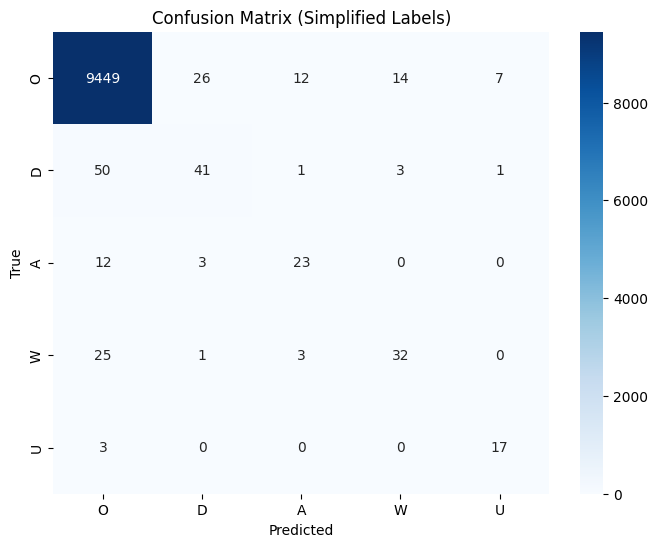

In [ ]:
import pandas as pd
import numpy as np
import torch
from transformers import BertTokenizerFast, BertForTokenClassification, TrainingArguments, Trainer
from torch.utils.data import Dataset as TorchDataset
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import csv

# 標籤簡化函數
def simplify(label):
    if label in ["B-D", "M-D", "E-D", "S-D"]:
        return "D"
    elif label in ["B-A", "M-A", "E-A", "S-A"]:
        return "A"
    elif label in ["B-W", "M-W", "E-W", "S-W"]:
        return "W"
    elif label in ["B-U", "M-U", "E-U", "S-U"]:
        return "U"
    else:
        return "O"

# 載入數據
try:
    result = pd.read_csv("/content/drive/MyDrive/few-shot/merged_posts800_stage3.csv",
                         encoding='utf-8',
                         quoting=csv.QUOTE_ALL,
                         on_bad_lines='warn')
except Exception as e:
    print(f"讀取錯誤：{e}")
    exit()

# 只保留前九個欄位
columns = result.columns[:9].tolist()
print(f"保留的欄位：{columns}")
result = result[columns]

# 檢查資料完整性
if result.duplicated(subset=['post_id', 'word']).any():
    print("警告：存在重複的 post_id 和 word 組合")
if result['human_label'].isna().any():
    print("警告：存在缺少 human_label 的行")

# 簡化標籤
result['simplified_label'] = result['human_label'].apply(simplify)

# 檢查簡化標籤分佈
print("簡化標籤分佈:", result['simplified_label'].value_counts().to_dict())

# 定義簡化標籤映射
label2id = {"O": 0, "D": 1, "A": 2, "W": 3, "U": 4}
id2label = {v: k for k, v in label2id.items()}

# 按 post_id 分組
grouped = result.groupby('post_id')
data = []
for post_id, group in grouped:
    caption = group['caption'].iloc[0]
    words = group['word'].tolist()
    labels = group['simplified_label'].tolist()
    if not all(isinstance(word, str) for word in words):
        words = [str(word) for word in words]
    # print(f"post_id: {post_id}, words: {words}, labels: {labels}")  # 調試
    data.append({
        "caption": caption,
        "words": words,
        "labels": [label2id[label] for label in labels]
    })

# 自訂 Dataset 類
class CustomDataset(TorchDataset):
    def __init__(self, data, tokenizer, max_length=128):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        tokenized_inputs = self.tokenizer(
            item["words"],
            is_split_into_words=True,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        word_ids = tokenized_inputs.word_ids()
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(item["labels"][word_idx] if word_idx < len(item["labels"]) else -100)
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx

        tokenized_inputs["labels"] = torch.tensor(label_ids)
        tokenized_inputs = {k: v.squeeze(0) for k, v in tokenized_inputs.items()}
        return tokenized_inputs

# 載入快速 tokenizer
try:
    tokenizer = BertTokenizerFast.from_pretrained("zwzzz/Chinese-MentalBERT")
    print("成功載入 BertTokenizerFast:", tokenizer.is_fast)
except Exception as e:
    print(f"載入快速 tokenizer 失敗: {e}")
    tokenizer = BertTokenizer.from_pretrained("zwzzz/Chinese-MentalBERT")
    print("使用標準 BertTokenizer，可能需要手動對齊 word_ids")

# 創建數據集
full_dataset = CustomDataset(data, tokenizer)

# 分割數據
train_size = int(0.8 * len(full_dataset))
eval_size = len(full_dataset) - train_size
train_dataset, eval_dataset = torch.utils.data.random_split(full_dataset, [train_size, eval_size])

# 載入模型
model = BertForTokenClassification.from_pretrained("zwzzz/Chinese-MentalBERT", num_labels=len(label2id))
for param in model.bert.embeddings.parameters():
    param.requires_grad = False
for param in model.bert.encoder.layer[:4].parameters():
    param.requires_grad = False

# 訓練參數
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/few-shot/chinese_mentalbert_finetuned_results_simplified",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    num_train_epochs=5,
    weight_decay=0.01,
    warmup_steps=50,
    logging_steps=5,
    report_to="none",
    save_steps=0,
    gradient_accumulation_steps=2,
    metric_for_best_model="eval_loss",
    load_best_model_at_end=True,
)

# 定義評估指標
def compute_metrics(pred):
    labels = pred.label_ids.flatten()
    preds = pred.predictions.argmax(-1).flatten()
    mask = labels != -100
    labels = labels[mask]
    preds = preds[mask]

    # 計算基本指標
    accuracy = accuracy_score(labels, preds)
    f1_weighted = f1_score(labels, preds, average="weighted")
    f1_macro = f1_score(labels, preds, average="macro")

    # 计算 Precision, Recall, F1 for each label present in true labels
    unique_labels = np.unique(labels)
    metrics_by_label = {}
    for label_id in unique_labels:
        label_name = id2label.get(label_id, f"Unknown_{label_id}")
        precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, labels=[label_id], average=None)
        metrics_by_label[f"precision_{label_name}"] = precision[0] if precision.size > 0 else 0.0
        metrics_by_label[f"recall_{label_name}"] = recall[0] if recall.size > 0 else 0.0
        metrics_by_label[f"f1_{label_name}"] = f1[0] if f1.size > 0 else 0.0


    # # 计算混淆矩阵 - Moved outside to recompute from predictions
    # cm = confusion_matrix(labels, preds, labels=list(label2id.values())) # Ensure all labels are included

    return {
        "accuracy": accuracy,
        "f1_weighted": f1_weighted,
        "f1_macro": f1_macro,
        **metrics_by_label,
        # "confusion_matrix": cm.tolist() # Removed confusion matrix from here
    }

# 微調
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics
)

# 訓練
trainer.train()
print("訓練完成")

# 評估
eval_results = trainer.evaluate()
print("評估結果:", eval_results)

# Recompute confusion matrix from predictions
predictions, labels, _ = trainer.predict(eval_dataset)
predictions = np.argmax(predictions, axis=2)

# Flatten the predictions and labels, filtering out -100
flat_predictions = predictions.flatten()
flat_labels = labels.flatten()

# Filter out -100 from both predictions and labels
mask = flat_labels != -100
flat_predictions = flat_predictions[mask]
flat_labels = flat_labels[mask]


# Ensure labels list for confusion matrix covers all possible labels
labels_for_cm = list(label2id.values())

cm = confusion_matrix(flat_labels, flat_predictions, labels=labels_for_cm)


# 視覺化混淆矩陣
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=list(id2label.values()), yticklabels=list(id2label.values()))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Simplified Labels)")
plt.show()

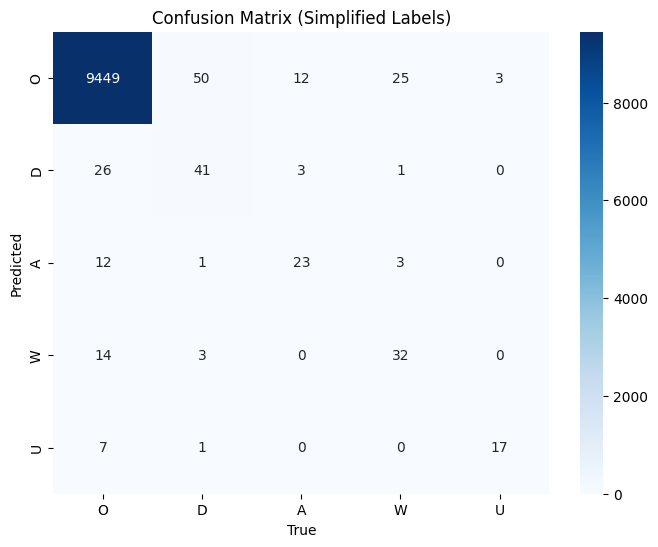

In [ ]:
# 混淆矩陣 (交換輸入順序)
cm = confusion_matrix(flat_predictions, flat_labels, labels=labels_for_cm)

# 視覺化混淆矩陣
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=list(id2label.values()),  # 橫軸是真實
    yticklabels=list(id2label.values())   # 縱軸是預測
)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.title("Confusion Matrix (Simplified Labels)")
plt.show()


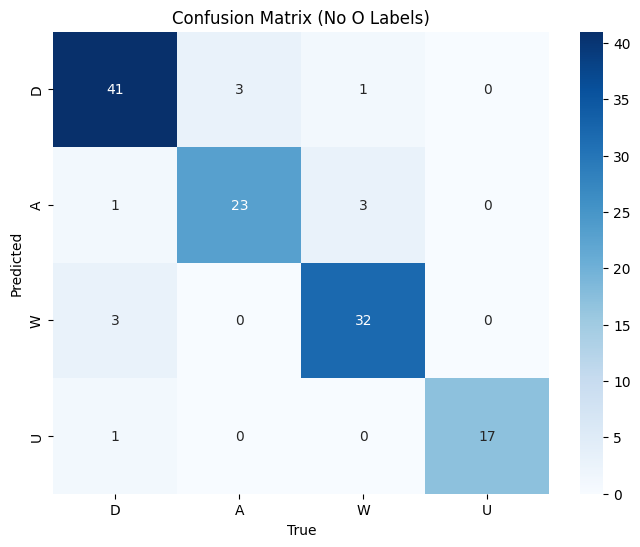

In [ ]:
# 排除 O 類別
labels_no_O = [lid for lid, name in id2label.items() if name != "O"]

# 混淆矩陣 (交換順序，橫軸=True, 縱軸=Predicted)
cm_no_O = confusion_matrix(flat_predictions, flat_labels, labels=labels_no_O)

# 視覺化 (不含 O)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_no_O, annot=True, fmt="d", cmap="Blues",
    xticklabels=[id2label[lid] for lid in labels_no_O],
    yticklabels=[id2label[lid] for lid in labels_no_O]
)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.title("Confusion Matrix (No O Labels)")
plt.show()


保留的欄位：['post_id', 'caption', 'word', 'human_label', 'gpt_label_1', 'gpt_label_2', 'gpt_label_3', 'gpt_label_4', 'gpt_label_5']
警告：存在重複的 post_id 和 word 組合
簡化標籤分佈: {'O': 36997, 'D': 667, 'W': 234, 'A': 91, 'U': 78}
成功載入 BertTokenizerFast: True


Some weights of BertForTokenClassification were not initialized from the model checkpoint at zwzzz/Chinese-MentalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro,Precision O,Recall O,F1 O,Precision D,Recall D,F1 D,Precision A,Recall A,F1 A,Precision W,Recall W,F1 W,Precision U,Recall U,F1 U
1,0.858100,0.258073,0.953901,0.931395,0.195281,0.953901,1.000000,0.976407,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.296400,0.156510,0.960697,0.948160,0.293940,0.964907,0.996592,0.980494,0.680000,0.382022,0.489209,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.174300,0.135404,0.961879,0.951623,0.333036,0.969194,0.994114,0.981496,0.642857,0.505618,0.566038,0.333333,0.071429,0.117647,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.177300,0.124910,0.961288,0.953331,0.343351,0.974101,0.990397,0.982181,0.568421,0.606742,0.586957,0.166667,0.071429,0.100000,1.000000,0.024390,0.047619,0.000000,0.000000,0.000000
5,0.125200,0.123643,0.960402,0.953894,0.352079,0.976716,0.987608,0.982132,0.531532,0.662921,0.590000,0.142857,0.071429,0.095238,1.000000,0.048780,0.093023,0.000000,0.000000,0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

訓練完成


評估結果: {'eval_loss': 0.12364319711923599, 'eval_accuracy': 0.960401891252955, 'eval_f1_weighted': 0.9538944779666315, 'eval_f1_macro': 0.35207864112846277, 'eval_precision_O': 0.9767156862745098, 'eval_recall_O': 0.9876084262701363, 'eval_f1_O': 0.982131854590265, 'eval_precision_D': 0.5315315315315315, 'eval_recall_D': 0.6629213483146067, 'eval_f1_D': 0.59, 'eval_precision_A': 0.14285714285714285, 'eval_recall_A': 0.07142857142857142, 'eval_f1_A': 0.09523809523809523, 'eval_precision_W': 1.0, 'eval_recall_W': 0.04878048780487805, 'eval_f1_W': 0.09302325581395349, 'eval_precision_U': 0.0, 'eval_recall_U': 0.0, 'eval_f1_U': 0.0, 'eval_runtime': 0.8121, 'eval_samples_per_second': 68.954, 'eval_steps_per_second': 8.619, 'epoch': 5.0}


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


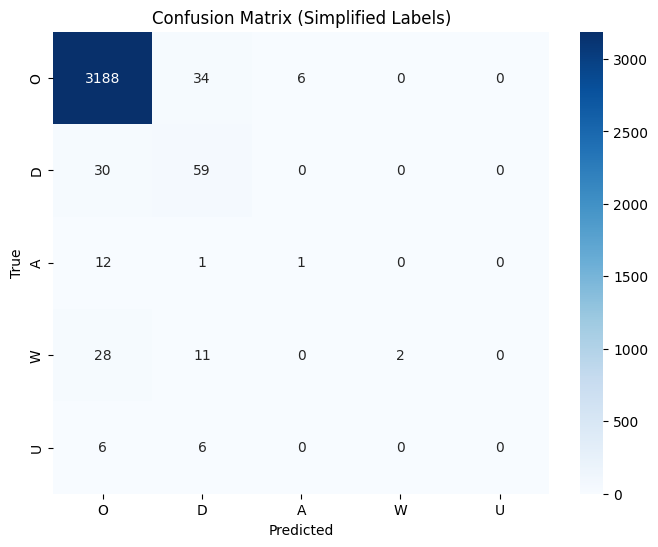

In [ ]:
import pandas as pd
import numpy as np
import torch
from transformers import BertTokenizerFast, BertForTokenClassification, TrainingArguments, Trainer
from torch.utils.data import Dataset as TorchDataset
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import csv

# 標籤簡化函數
def simplify(label):
    if label in ["B-D", "M-D", "E-D", "S-D"]:
        return "D"
    elif label in ["B-A", "M-A", "E-A", "S-A"]:
        return "A"
    elif label in ["B-W", "M-W", "E-W", "S-W"]:
        return "W"
    elif label in ["B-U", "M-U", "E-U", "S-U"]:
        return "U"
    else:
        return "O"

# 載入數據
try:
    result = pd.read_csv("/content/drive/MyDrive/few-shot/merged_posts800_noO.csv",
                         encoding='utf-8',
                         quoting=csv.QUOTE_ALL,
                         on_bad_lines='warn')
except Exception as e:
    print(f"讀取錯誤：{e}")
    exit()

# 只保留前九個欄位
columns = result.columns[:9].tolist()
print(f"保留的欄位：{columns}")
result = result[columns]

# 檢查資料完整性
if result.duplicated(subset=['post_id', 'word']).any():
    print("警告：存在重複的 post_id 和 word 組合")
if result['human_label'].isna().any():
    print("警告：存在缺少 human_label 的行")

# 簡化標籤
result['simplified_label'] = result['human_label'].apply(simplify)

# 檢查簡化標籤分佈
print("簡化標籤分佈:", result['simplified_label'].value_counts().to_dict())

# 定義簡化標籤映射
label2id = {"O": 0, "D": 1, "A": 2, "W": 3, "U": 4}
id2label = {v: k for k, v in label2id.items()}

# 按 post_id 分組
grouped = result.groupby('post_id')
data = []
for post_id, group in grouped:
    caption = group['caption'].iloc[0]
    words = group['word'].tolist()
    labels = group['simplified_label'].tolist()
    if not all(isinstance(word, str) for word in words):
        words = [str(word) for word in words]
    # print(f"post_id: {post_id}, words: {words}, labels: {labels}")  # 調試
    data.append({
        "caption": caption,
        "words": words,
        "labels": [label2id[label] for label in labels]
    })

# 自訂 Dataset 類
class CustomDataset(TorchDataset):
    def __init__(self, data, tokenizer, max_length=128):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        tokenized_inputs = self.tokenizer(
            item["words"],
            is_split_into_words=True,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        word_ids = tokenized_inputs.word_ids()
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(item["labels"][word_idx] if word_idx < len(item["labels"]) else -100)
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx

        tokenized_inputs["labels"] = torch.tensor(label_ids)
        tokenized_inputs = {k: v.squeeze(0) for k, v in tokenized_inputs.items()}
        return tokenized_inputs

# 載入快速 tokenizer
try:
    tokenizer = BertTokenizerFast.from_pretrained("zwzzz/Chinese-MentalBERT")
    print("成功載入 BertTokenizerFast:", tokenizer.is_fast)
except Exception as e:
    print(f"載入快速 tokenizer 失敗: {e}")
    tokenizer = BertTokenizer.from_pretrained("zwzzz/Chinese-MentalBERT")
    print("使用標準 BertTokenizer，可能需要手動對齊 word_ids")

# 創建數據集
full_dataset = CustomDataset(data, tokenizer)

# 分割數據
train_size = int(0.8 * len(full_dataset))
eval_size = len(full_dataset) - train_size
train_dataset, eval_dataset = torch.utils.data.random_split(full_dataset, [train_size, eval_size])

# 載入模型
model = BertForTokenClassification.from_pretrained("zwzzz/Chinese-MentalBERT", num_labels=len(label2id))
for param in model.bert.embeddings.parameters():
    param.requires_grad = False
for param in model.bert.encoder.layer[:4].parameters():
    param.requires_grad = False

# 訓練參數
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/few-shot/chinese_mentalbert_finetuned_results_simplified",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    num_train_epochs=5,
    weight_decay=0.01,
    warmup_steps=50,
    logging_steps=5,
    report_to="none",
    save_steps=0,
    gradient_accumulation_steps=2,
    metric_for_best_model="eval_loss",
    load_best_model_at_end=True,
)

# 定義評估指標
def compute_metrics(pred):
    labels = pred.label_ids.flatten()
    preds = pred.predictions.argmax(-1).flatten()
    mask = labels != -100
    labels = labels[mask]
    preds = preds[mask]

    # 計算基本指標
    accuracy = accuracy_score(labels, preds)
    f1_weighted = f1_score(labels, preds, average="weighted")
    f1_macro = f1_score(labels, preds, average="macro")

    # 计算 Precision, Recall, F1 for each label present in true labels
    unique_labels = np.unique(labels)
    metrics_by_label = {}
    for label_id in unique_labels:
        label_name = id2label.get(label_id, f"Unknown_{label_id}")
        precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, labels=[label_id], average=None)
        metrics_by_label[f"precision_{label_name}"] = precision[0] if precision.size > 0 else 0.0
        metrics_by_label[f"recall_{label_name}"] = recall[0] if recall.size > 0 else 0.0
        metrics_by_label[f"f1_{label_name}"] = f1[0] if f1.size > 0 else 0.0


    # # 计算混淆矩阵 - Moved outside to recompute from predictions
    # cm = confusion_matrix(labels, preds, labels=list(label2id.values())) # Ensure all labels are included

    return {
        "accuracy": accuracy,
        "f1_weighted": f1_weighted,
        "f1_macro": f1_macro,
        **metrics_by_label,
        # "confusion_matrix": cm.tolist() # Removed confusion matrix from here
    }

# 微調
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics
)

# 訓練
trainer.train()
print("訓練完成")

# 評估
eval_results = trainer.evaluate()
print("評估結果:", eval_results)

# Recompute confusion matrix from predictions
predictions, labels, _ = trainer.predict(eval_dataset)
predictions = np.argmax(predictions, axis=2)

# Flatten the predictions and labels, filtering out -100
flat_predictions = predictions.flatten()
flat_labels = labels.flatten()

# Filter out -100 from both predictions and labels
mask = flat_labels != -100
flat_predictions = flat_predictions[mask]
flat_labels = flat_labels[mask]

# Filter out predicted labels that are outside the valid range (0-4)
valid_label_indices = list(label2id.values())
valid_pred_mask = np.isin(flat_predictions, valid_label_indices)
flat_predictions = flat_predictions[valid_pred_mask]
flat_labels = flat_labels[valid_pred_mask] # Also filter true labels based on valid predictions

# Ensure labels list for confusion matrix covers all possible labels
labels_for_cm = list(label2id.values())

cm = confusion_matrix(flat_labels, flat_predictions, labels=labels_for_cm)


# 視覺化混淆矩陣
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=list(id2label.values()), yticklabels=list(id2label.values()))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Simplified Labels)")
plt.show()

In [ ]:
# 定義評估指標
def compute_metrics(pred):
    labels = pred.label_ids.flatten()
    preds = pred.predictions.argmax(-1).flatten()
    mask = labels != -100  # 過濾掉 -100（填充或無效標籤）
    labels = labels[mask]
    preds = preds[mask]

    # 定義目標類別索引 (D, W, A, U)
    target_labels = [1, 3, 2, 4]  # 對應 label2id: D=1, W=3, A=2, U=4

    # 過濾出目標類別的標籤和預測
    target_mask = np.isin(labels, target_labels)
    labels_target = labels[target_mask]
    preds_target = preds[target_mask]

    # 計算目標類別的準確度
    accuracy_target = accuracy_score(labels_target, preds_target) if len(labels_target) > 0 else 0.0

    # 計算整體指標 (包括所有類別)
    accuracy = accuracy_score(labels, preds)
    f1_weighted = f1_score(labels, preds, average="weighted")
    f1_macro = f1_score(labels, preds, average="macro")

    # 計算每個類別的 Precision, Recall, F1
    precision, recall, f1_per_class, _ = precision_recall_fscore_support(labels, preds, average=None, labels=target_labels)
    class_metrics = {
        f"precision_{id2label[i]}": precision[j] for j, i in enumerate(target_labels) if i in id2label
    }
    class_metrics.update({
        f"recall_{id2label[i]}": recall[j] for j, i in enumerate(target_labels) if i in id2label
    })
    class_metrics.update({
        f"f1_{id2label[i]}": f1_per_class[j] for j, i in enumerate(target_labels) if i in id2label
    })

    # 計算混淆矩陣
    cm = confusion_matrix(labels, preds)

    return {
        "accuracy": accuracy,  # 整體準確度 (包括 O)
        "accuracy_target": accuracy_target,  # 僅 D/W/A/U 的準確度
        "f1_weighted": f1_weighted,
        "f1_macro": f1_macro,
        **class_metrics,
        "confusion_matrix": cm.tolist()
    }

In [ ]:
# 🔍 檢查 Oversampling 後的貼文與 token 數量
print("\n=== Oversampling 統計 ===")
print("Oversampled 貼文數:", oversampled_train_df["post_id"].nunique())
print("Oversampled token 數:", len(oversampled_train_df))
print("每類 main_label 貼文數:")
post_main_after = assign_main_label(oversampled_train_df)
print(post_main_after["main_label"].value_counts())



=== Oversampling 統計 ===
Oversampled 貼文數: 233
Oversampled token 數: 31729
每類 main_label 貼文數:
main_label
D    125
W     62
A     23
U     23
Name: count, dtype: int64


### 逐次加入合成資料來微調模型

In [ ]:
import os
import csv
import shutil
import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset as TorchDataset
from transformers import (
    BertTokenizerFast, BertForTokenClassification,
    TrainingArguments, Trainer
)
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ========================
# 1) 全域設定與隨機種子
# ========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

RESULTS_ROOT = "/content/drive/MyDrive/few-shot/exp_incremental_synth"
os.makedirs(RESULTS_ROOT, exist_ok=True)

# ========================
# 2) 路徑
# ========================
orig_path  = "/content/drive/MyDrive/few-shot/merged_posts800.csv"
synth_path = "/content/drive/MyDrive/few-shot/merged_stage3_full.csv"

# ========================
# 3) 標籤簡化
# ========================
def simplify(label):
    if label in ["B-D", "M-D", "E-D", "S-D"]:
        return "D"
    elif label in ["B-A", "M-A", "E-A", "S-A"]:
        return "A"
    elif label in ["B-W", "M-W", "E-W", "S-W"]:
        return "W"
    elif label in ["B-U", "M-U", "E-U", "S-U"]:
        return "U"
    else:
        return "O"

label2id = {"O": 0, "D": 1, "A": 2, "W": 3, "U": 4}
id2label = {v: k for k, v in label2id.items()}
LABEL_ORDER = [label2id[k] for k in ["O", "D", "A", "W", "U"]]

# ========================
# 4) 載入與處理資料
# ========================
def load_and_process(path):
    df = pd.read_csv(path, encoding="utf-8", quoting=csv.QUOTE_ALL, on_bad_lines="warn")
    # 只保留前 9 欄（與你原程式一致）
    df = df[df.columns[:9].tolist()]
    # 必要欄位檢查
    need_cols = {"post_id", "word", "caption", "human_label"}
    miss = need_cols - set(df.columns)
    if miss:
        raise ValueError(f"檔案 {path} 缺少必要欄位: {miss}")
    # 簡化標籤
    df["simplified_label"] = df["human_label"].apply(simplify)
    return df

orig_df  = load_and_process(orig_path)
synth_df = load_and_process(synth_path)

print("原始資料分佈:", orig_df["simplified_label"].value_counts().to_dict())
print("合成資料分佈:", synth_df["simplified_label"].value_counts().to_dict())

def to_dataset_format(df):
    data = []
    for post_id, g in df.groupby("post_id"):
        words  = g["word"].astype(str).tolist()
        labels = g["simplified_label"].tolist()
        data.append({
            "caption": g["caption"].iloc[0],
            "words": words,
            "labels": [label2id[x] for x in labels]
        })
    return data

orig_data  = to_dataset_format(orig_df)
synth_data = to_dataset_format(synth_df)

# 為了避免每次都取到同一批合成資料前 50/100...，先做穩定隨機順序
rng = np.random.default_rng(SEED)
synth_indices = np.arange(len(synth_data))
rng.shuffle(synth_indices)
synth_data = [synth_data[i] for i in synth_indices]

# ========================
# 5) Dataset 類別
# ========================
class CustomDataset(TorchDataset):
    def __init__(self, data, tokenizer, max_length=128):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        enc = self.tokenizer(
            item["words"],
            is_split_into_words=True,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        word_ids = enc.word_ids()
        prev_wid = None
        label_ids = []
        for wid in word_ids:
            if wid is None:
                label_ids.append(-100)
            elif wid != prev_wid:
                label_ids.append(item["labels"][wid] if wid < len(item["labels"]) else -100)
            else:
                # 對於一個 word 內的後續 sub-tokens 不計分（標 -100）
                label_ids.append(-100)
            prev_wid = wid
        enc["labels"] = torch.tensor(label_ids)
        enc = {k: v.squeeze(0) for k, v in enc.items()}
        return enc

# ========================
# 6) Tokenizer
# ========================
tokenizer = BertTokenizerFast.from_pretrained("zwzzz/Chinese-MentalBERT")

# ========================
# 7) 固定驗證集（從原始 800 切出）
# ========================
np.random.seed(SEED)
indices = np.random.permutation(len(orig_data))
split = int(0.8 * len(orig_data))
train_idx, val_idx = indices[:split], indices[split:]
base_train_data = [orig_data[i] for i in train_idx]
fixed_val_data  = [orig_data[i] for i in val_idx]

eval_dataset = CustomDataset(fixed_val_data, tokenizer)

# ========================
# 8) 指標計算
# ========================
def compute_metrics(pred):
    labels = pred.label_ids.reshape(-1)
    preds  = pred.predictions.argmax(-1).reshape(-1)
    mask = labels != -100
    labels, preds = labels[mask], preds[mask]

    acc = accuracy_score(labels, preds)
    f1_w = f1_score(labels, preds, average="weighted", zero_division=0)
    f1_m = f1_score(labels, preds, average="macro", zero_division=0)

    metrics_by_label = {}
    for lid in sorted(np.unique(labels)):
        name = id2label.get(int(lid), str(lid))
        pr, rc, f1, _ = precision_recall_fscore_support(labels, preds, labels=[lid], average=None, zero_division=0)
        metrics_by_label[f"precision_{name}"] = float(pr[0])
        metrics_by_label[f"recall_{name}"]    = float(rc[0])
        metrics_by_label[f"f1_{name}"]        = float(f1[0])

    return {"accuracy": acc, "f1_weighted": f1_w, "f1_macro": f1_m, **metrics_by_label}

def plot_and_save_cm(cm, labels_names, out_png):
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_names, yticklabels=labels_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix (Simplified Labels)")
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.close()

# ========================
# 9) 訓練迴圈（逐步加入合成資料）
# ========================
all_rows = []  # for summary CSV

for step in [0, 50, 100, 150, 200]:
    cur_dir = os.path.join(RESULTS_ROOT, f"results_simplified_step{step}")
    os.makedirs(cur_dir, exist_ok=True)

    # 準備訓練資料：原始訓練分割 + 前 step 筆合成
    current_train = base_train_data + synth_data[:step]
    train_dataset = CustomDataset(train_data, tokenizer, max_o_ratio=0.7)

    # 模型與凍結策略（沿用你之前的做法）
    model = BertForTokenClassification.from_pretrained(
        "zwzzz/Chinese-MentalBERT",
        num_labels=len(label2id)
    )
    # 凍結 embeddings 與前 4 層 encoder
    for p in model.bert.embeddings.parameters():
        p.requires_grad = False
    for p in model.bert.encoder.layer[:4].parameters():
        p.requires_grad = False

    # TrainingArguments — 重要：eval/save 策略一致；只保留 1 個 checkpoint
    training_args = TrainingArguments(
        output_dir=cur_dir,
        evaluation_strategy="epoch",
        save_strategy="epoch",          # ★ 和 evaluation_strategy 一致
        save_total_limit=1,             # ★ 僅保留 1 個 checkpoint
        load_best_model_at_end=True,    # ★ 訓練結束載入最佳
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        learning_rate=2e-5,
        per_device_train_batch_size=4,
        num_train_epochs=5,
        weight_decay=0.01,
        warmup_steps=50,
        logging_strategy="steps",
        logging_steps=20,
        report_to="none",
        gradient_accumulation_steps=2,
        seed=SEED,
        save_on_each_node=False
        # 若 transformers 版本支援，也可加上：
        # save_only_model=True,
        # save_safetensors=True,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        compute_metrics=compute_metrics
    )

    print(f"\n===== 訓練階段：原始800 + {step} 合成，訓練樣本數={len(current_train)}，驗證樣本數={len(fixed_val_data)} =====")
    trainer.train()

    # 這時候 trainer 內的模型已是最佳模型（因為 load_best_model_at_end=True）
    # 額外穩妥地再存一份到 best_model/ 目錄
    best_dir = os.path.join(cur_dir, "best_model")
    trainer.save_model(best_dir)                 # 權重
    tokenizer.save_pretrained(best_dir)         # tokenizer
    # 也保留 config、training state 於 output_dir（Trainer 會處理）

    # 評估、輸出度量
    eval_results = trainer.evaluate()
    print(f"[Step {step}] Eval:", eval_results)

    # 另存單階段 metrics 到 CSV
    one_csv = os.path.join(cur_dir, f"metrics_step{step}.csv")
    pd.DataFrame([{"step": step, "train_posts": len(current_train), **eval_results}]).to_csv(one_csv, index=False)

    # 預測驗證集 → 混淆矩陣
    preds, labels, _ = trainer.predict(eval_dataset)
    preds = preds.argmax(-1)

    flat_preds  = preds.reshape(-1)
    flat_labels = labels.reshape(-1)
    mask = flat_labels != -100
    flat_preds  = flat_preds[mask]
    flat_labels = flat_labels[mask]

    cm = confusion_matrix(flat_labels, flat_preds, labels=LABEL_ORDER)
    # 存圖
    cm_png = os.path.join(cur_dir, f"confusion_matrix_step{step}.png")
    plot_and_save_cm(cm, [id2label[i] for i in LABEL_ORDER], cm_png)
    # 存矩陣數值
    cm_csv = os.path.join(cur_dir, f"confusion_matrix_step{step}.csv")
    pd.DataFrame(cm, index=[id2label[i] for i in LABEL_ORDER],
                 columns=[id2label[i] for i in LABEL_ORDER]).to_csv(cm_csv)

    # 集中彙整（for 總表）
    row = {"step": step, "train_posts": len(current_train)}
    # 只拉出常用指標（避免把 logits 等一併存入）
    for k in ["eval_loss", "eval_accuracy", "eval_f1_weighted", "eval_f1_macro"]:
        if k in eval_results:
            row[k] = float(eval_results[k])
    all_rows.append(row)

# 總表：各 step 的摘要指標
summary_csv = os.path.join(RESULTS_ROOT, "summary_metrics.csv")
pd.DataFrame(all_rows).to_csv(summary_csv, index=False)
print(f"\n✔ 已輸出總表：{summary_csv}")
print("完成。每個階段的最佳模型與成果皆位於：", RESULTS_ROOT)


原始資料分佈: {'O': 95628, 'D': 667, 'W': 234, 'A': 91, 'U': 78}
合成資料分佈: {'O': 8063, 'D': 399, 'W': 248, 'A': 180, 'U': 140}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 26640a1d-36e4-4faf-9410-0e78b8e27580)')' thrown while requesting HEAD https://huggingface.co/zwzzz/Chinese-MentalBERT/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 7a0f1184-9bdf-482b-960d-0ee434e9804d)')' thrown whi

vocab.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/848 [00:00<?, ?B/s]

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: b37fb51c-22ec-4184-8590-2622ea8db857)')' thrown while requesting HEAD https://huggingface.co/zwzzz/Chinese-MentalBERT/resolve/main/model.safetensors.index.json
Retrying in 1s [Retry 1/5].


...

[Step 150] Eval: {'eval_loss': 0.04491286724805832, 'eval_accuracy': 0.9851235797118426, 'eval_f1_weighted': 0.9841105975519447, 'eval_f1_macro': 0.4771924289306548, 'eval_precision_O': 0.9914387633769323, 'eval_recall_O': 0.9945133587786259, 'eval_f1_O': 0.992973681076575, 'eval_precision_D': 0.6404494382022472, 'eval_recall_D': 0.59375, 'eval_f1_D': 0.6162162162162163, 'eval_precision_A': 0.0, 'eval_recall_A': 0.0, 'eval_f1_A': 0.0, 'eval_precision_W': 0.37037037037037035, 'eval_recall_W': 0.4166666666666667, 'eval_f1_W': 0.39215686274509803, 'eval_precision_U': 0.8333333333333334, 'eval_recall_U': 0.25, 'eval_f1_U': 0.38461538461538464, 'eval_runtime': 1.338, 'eval_samples_per_second': 119.584, 'eval_steps_per_second': 14.948, 'epoch': 5.0}


Some weights of BertForTokenClassification were not initialized from the model checkpoint at zwzzz/Chinese-MentalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(



===== 訓練階段：原始800 + 200 合成，訓練樣本數=840，驗證樣本數=160 =====


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro,Precision O,Recall O,F1 O,Precision D,Recall D,F1 D,Precision A,Recall A,F1 A,Precision W,Recall W,F1 W,Precision U,Recall U,F1 U
1,0.245600,0.051738,0.984538,0.981213,0.374834,0.987946,0.997137,0.992520,0.588235,0.416667,0.487805,0.000000,0.000000,0.000000,1.000000,0.083333,0.153846,0.600000,0.150000,0.240000
2,0.173700,0.044923,0.985475,0.984361,0.532793,0.991207,0.994990,0.993095,0.597826,0.572917,0.585106,0.333333,0.307692,0.320000,0.615385,0.333333,0.432432,1.000000,0.200000,0.333333
3,0.104400,0.044502,0.986178,0.984983,0.555467,0.990744,0.995825,0.993278,0.704225,0.520833,0.598802,0.333333,0.230769,0.272727,0.478261,0.458333,0.468085,0.857143,0.300000,0.444444
4,0.085900,0.045772,0.985944,0.985538,0.603720,0.992145,0.994275,0.993209,0.647059,0.572917,0.607735,0.375000,0.230769,0.285714,0.400000,0.500000,0.444444,0.916667,0.550000,0.687500
5,0.069400,0.046547,0.986295,0.985842,0.604934,0.992264,0.994394,0.993328,0.644444,0.604167,0.623656,0.333333,0.230769,0.272727,0.480000,0.500000,0.489796,0.909091,0.500000,0.645161


[Step 200] Eval: {'eval_loss': 0.04450158402323723, 'eval_accuracy': 0.9861778142204521, 'eval_f1_weighted': 0.9849827731518922, 'eval_f1_macro': 0.555467485891931, 'eval_precision_O': 0.9907440370238519, 'eval_recall_O': 0.9958253816793893, 'eval_f1_O': 0.993278210695378, 'eval_precision_D': 0.704225352112676, 'eval_recall_D': 0.5208333333333334, 'eval_f1_D': 0.5988023952095808, 'eval_precision_A': 0.3333333333333333, 'eval_recall_A': 0.23076923076923078, 'eval_f1_A': 0.2727272727272727, 'eval_precision_W': 0.4782608695652174, 'eval_recall_W': 0.4583333333333333, 'eval_f1_W': 0.46808510638297873, 'eval_precision_U': 0.8571428571428571, 'eval_recall_U': 0.3, 'eval_f1_U': 0.4444444444444444, 'eval_runtime': 1.4457, 'eval_samples_per_second': 110.676, 'eval_steps_per_second': 13.835, 'epoch': 5.0}

✔ 已輸出總表：/content/drive/MyDrive/few-shot/exp_incremental_synth/summary_metrics.csv
完成。每個階段的最佳模型與成果皆位於： /content/drive/MyDrive/few-shot/exp_incremental_synth


自動跑 N 次實驗，例如 N=5，每個 step（0,50,100,150,200）會：

重複訓練 N 次（隨機初始化，固定同一驗證集）。

每次都計算 F1 Macro。

最後輸出 平均值與標準差，存成 summary_metrics.csv，方便你看趨勢。

In [ ]:
import os
import csv
import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset as TorchDataset
from transformers import BertTokenizerFast, BertForTokenClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, confusion_matrix

# ========================
# 全域設定
# ========================
RESULTS_ROOT = "/content/drive/MyDrive/few-shot/exp_incremental_synth_repeated"
os.makedirs(RESULTS_ROOT, exist_ok=True)
N_RUNS = 5   # 重複次數

# ========================
# 標籤簡化
# ========================
def simplify(label):
    if label in ["B-D", "M-D", "E-D", "S-D"]: return "D"
    elif label in ["B-A", "M-A", "E-A", "S-A"]: return "A"
    elif label in ["B-W", "M-W", "E-W", "S-W"]: return "W"
    elif label in ["B-U", "M-U", "E-U", "S-U"]: return "U"
    else: return "O"

label2id = {"O": 0, "D": 1, "A": 2, "W": 3, "U": 4}
id2label = {v: k for k, v in label2id.items()}

# ========================
# 載入資料
# ========================
def load_and_process(path):
    df = pd.read_csv(path, encoding="utf-8", quoting=csv.QUOTE_ALL, on_bad_lines="warn")
    df = df[df.columns[:9].tolist()]  # 保留前9欄
    df["simplified_label"] = df["human_label"].apply(simplify)
    return df

orig_df  = load_and_process("/content/drive/MyDrive/few-shot/merged_posts800.csv")
synth_df = load_and_process("/content/drive/MyDrive/few-shot/merged_stage3_full.csv")

def to_dataset_format(df):
    data = []
    for post_id, g in df.groupby("post_id"):
        words  = g["word"].astype(str).tolist()
        labels = g["simplified_label"].tolist()
        data.append({
            "caption": g["caption"].iloc[0],
            "words": words,
            "labels": [label2id[x] for x in labels]
        })
    return data

orig_data  = to_dataset_format(orig_df)
synth_data = to_dataset_format(synth_df)

# ========================
# Dataset 類
# ========================
class CustomDataset(TorchDataset):
    def __init__(self, data, tokenizer, max_length=128):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        enc = self.tokenizer(
            item["words"],
            is_split_into_words=True,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        word_ids = enc.word_ids()
        prev_wid = None
        label_ids = []
        for wid in word_ids:
            if wid is None:
                label_ids.append(-100)
            elif wid != prev_wid:
                label_ids.append(item["labels"][wid] if wid < len(item["labels"]) else -100)
            else:
                label_ids.append(-100)
            prev_wid = wid
        enc["labels"] = torch.tensor(label_ids)
        return {k: v.squeeze(0) for k, v in enc.items()}

# ========================
# Tokenizer
# ========================
tokenizer = BertTokenizerFast.from_pretrained("zwzzz/Chinese-MentalBERT")

# ========================
# 固定驗證集
# ========================
np.random.seed(42)
indices = np.random.permutation(len(orig_data))
split = int(0.8 * len(orig_data))
train_idx, val_idx = indices[:split], indices[split:]
base_train_data = [orig_data[i] for i in train_idx]
fixed_val_data  = [orig_data[i] for i in val_idx]
eval_dataset = CustomDataset(fixed_val_data, tokenizer)

# ========================
# 指標
# ========================
def compute_metrics(pred):
    labels = pred.label_ids.reshape(-1)
    preds  = pred.predictions.argmax(-1).reshape(-1)
    mask = labels != -100
    labels, preds = labels[mask], preds[mask]
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_weighted": f1_score(labels, preds, average="weighted", zero_division=0),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0)
    }

# ========================
# 多次實驗
# ========================
results_summary = []

for step in [0, 50, 100, 150, 200]:
    f1_macro_list = []
    print(f"\n===== Step {step}: 訓練原始800 + {step}合成 =====")
    current_train = base_train_data + synth_data[:step]
    train_dataset = CustomDataset(current_train, tokenizer)

    for run in range(N_RUNS):
        print(f"  >> Run {run+1}/{N_RUNS}")
        model = BertForTokenClassification.from_pretrained(
            "zwzzz/Chinese-MentalBERT", num_labels=len(label2id)
        )

        training_args = TrainingArguments(
            output_dir=f"{RESULTS_ROOT}/step{step}_run{run}",
            evaluation_strategy="epoch",
            save_strategy="epoch",
            save_total_limit=1,
            load_best_model_at_end=True,
            metric_for_best_model="eval_loss",
            greater_is_better=False,
            learning_rate=2e-5,
            per_device_train_batch_size=4,
            num_train_epochs=5,
            weight_decay=0.01,
            warmup_steps=50,
            logging_strategy="steps",
            logging_steps=20,
            report_to="none",
            gradient_accumulation_steps=2,
            seed=42+run  # 每次不同 seed
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=eval_dataset,
            compute_metrics=compute_metrics
        )

        trainer.train()
        eval_results = trainer.evaluate()
        f1_macro_list.append(eval_results["eval_f1_macro"])

    avg = np.mean(f1_macro_list)
    std = np.std(f1_macro_list)
    results_summary.append({
        "step": step,
        "train_posts": len(current_train),
        "f1_macro_mean": avg,
        "f1_macro_std": std
    })
    print(f"Step {step} → F1 Macro 平均={avg:.4f}, 標準差={std:.4f}")

# ========================
# 儲存總結表
# ========================
summary_df = pd.DataFrame(results_summary)
summary_path = os.path.join(RESULTS_ROOT, "summary_metrics.csv")
summary_df.to_csv(summary_path, index=False)
print("\n✔ 已輸出總表:", summary_path)
print(summary_df)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/848 [00:00<?, ?B/s]


===== Step 0: 訓練原始800 + 0合成 =====
  >> Run 1/5


pytorch_model.bin:   0%|          | 0.00/409M [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.248000,0.057710,0.984889,0.979581,0.310543
2,0.139100,0.047469,0.984655,0.982463,0.470827
3,0.081800,0.047097,0.985475,0.984234,0.518692


Step 150 → F1 Macro 平均=0.4746, 標準差=0.0308

===== Step 200: 訓練原始800 + 200合成 =====
  >> Run 1/5


Some weights of BertForTokenClassification were not initialized from the model checkpoint at zwzzz/Chinese-MentalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.249700,0.057137,0.984421,0.979562,0.309253
2,0.174700,0.047840,0.984421,0.983331,0.462364


RuntimeError: [enforce fail at inline_container.cc:664] . unexpected pos 265148160 vs 265148052

In [ ]:
import os
import csv
import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset as TorchDataset
from transformers import BertTokenizerFast, BertForTokenClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score

# ========================
# 全域設定
# ========================
RESULTS_ROOT = "/content/exp_incremental_synth_nosave"  # 存放 summary CSV
os.makedirs(RESULTS_ROOT, exist_ok=True)
N_RUNS = 5   # 每個 step 重複實驗次數

# ========================
# 標籤簡化
# ========================
def simplify(label):
    if label in ["B-D", "M-D", "E-D", "S-D"]: return "D"
    elif label in ["B-A", "M-A", "E-A", "S-A"]: return "A"
    elif label in ["B-W", "M-W", "E-W", "S-W"]: return "W"
    elif label in ["B-U", "M-U", "E-U", "S-U"]: return "U"
    else: return "O"

label2id = {"O": 0, "D": 1, "A": 2, "W": 3, "U": 4}
id2label = {v: k for k, v in label2id.items()}

# ========================
# 載入資料
# ========================
def load_and_process(path):
    df = pd.read_csv(path, encoding="utf-8", quoting=csv.QUOTE_ALL, on_bad_lines="warn")
    df = df[df.columns[:9].tolist()]  # 保留前9欄
    df["simplified_label"] = df["human_label"].apply(simplify)
    return df

orig_df  = load_and_process("/content/drive/MyDrive/few-shot/merged_posts800.csv")
synth_df = load_and_process("/content/drive/MyDrive/few-shot/merged_stage3_full.csv")

def to_dataset_format(df):
    data = []
    for post_id, g in df.groupby("post_id"):
        words  = g["word"].astype(str).tolist()
        labels = g["simplified_label"].tolist()
        data.append({
            "caption": g["caption"].iloc[0],
            "words": words,
            "labels": [label2id[x] for x in labels]
        })
    return data

orig_data  = to_dataset_format(orig_df)
synth_data = to_dataset_format(synth_df)

# ========================
# Dataset 類
# ========================
class CustomDataset(TorchDataset):
    def __init__(self, data, tokenizer, max_length=128):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        enc = self.tokenizer(
            item["words"],
            is_split_into_words=True,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        word_ids = enc.word_ids()
        prev_wid = None
        label_ids = []
        for wid in word_ids:
            if wid is None:
                label_ids.append(-100)
            elif wid != prev_wid:
                label_ids.append(item["labels"][wid] if wid < len(item["labels"]) else -100)
            else:
                label_ids.append(-100)
            prev_wid = wid
        enc["labels"] = torch.tensor(label_ids)
        return {k: v.squeeze(0) for k, v in enc.items()}

# ========================
# Tokenizer
# ========================
tokenizer = BertTokenizerFast.from_pretrained("zwzzz/Chinese-MentalBERT")

# ========================
# 固定驗證集
# ========================
np.random.seed(42)
indices = np.random.permutation(len(orig_data))
split = int(0.8 * len(orig_data))
train_idx, val_idx = indices[:split], indices[split:]
base_train_data = [orig_data[i] for i in train_idx]
fixed_val_data  = [orig_data[i] for i in val_idx]
eval_dataset = CustomDataset(fixed_val_data, tokenizer)

# ========================
# 指標
# ========================
def compute_metrics(pred):
    labels = pred.label_ids.reshape(-1)
    preds  = pred.predictions.argmax(-1).reshape(-1)
    mask = labels != -100
    labels, preds = labels[mask], preds[mask]
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_weighted": f1_score(labels, preds, average="weighted", zero_division=0),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0)
    }

# ========================
# 多次實驗 (不存模型)
# ========================
results_summary = []

for step in [0, 50, 100, 150, 200]:
    f1_macro_list = []
    print(f"\n===== Step {step}: 訓練原始800 + {step}合成 =====")
    current_train = base_train_data + synth_data[:step]
    train_dataset = CustomDataset(current_train, tokenizer)

    for run in range(N_RUNS):
        print(f"  >> Run {run+1}/{N_RUNS}")
        model = BertForTokenClassification.from_pretrained(
            "zwzzz/Chinese-MentalBERT", num_labels=len(label2id)
        )

        training_args = TrainingArguments(
            output_dir=f"{RESULTS_ROOT}/tmp_step{step}_run{run}",  # 會生成暫存，但不保留
            eval_strategy="epoch",
            save_strategy="no",          # ✅ 不存任何 checkpoint
            load_best_model_at_end=False, # ✅ 不載入最佳模型，因為沒存
            logging_strategy="steps",
            logging_steps=20,
            report_to="none",
            learning_rate=2e-5,
            per_device_train_batch_size=4,
            num_train_epochs=5,
            weight_decay=0.01,
            warmup_steps=50,
            gradient_accumulation_steps=2,
            seed=42+run
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=eval_dataset,
            compute_metrics=compute_metrics
        )

        trainer.train()
        eval_results = trainer.evaluate()
        f1_macro_list.append(eval_results["eval_f1_macro"])

        # 清理暫存資料夾，避免佔空間
        import shutil
        shutil.rmtree(f"{RESULTS_ROOT}/tmp_step{step}_run{run}", ignore_errors=True)

    avg = np.mean(f1_macro_list)
    std = np.std(f1_macro_list)
    results_summary.append({
        "step": step,
        "train_posts": len(current_train),
        "f1_macro_mean": avg,
        "f1_macro_std": std
    })
    print(f"Step {step} → F1 Macro 平均={avg:.4f}, 標準差={std:.4f}")

# ========================
# 儲存總結表
# ========================
summary_df = pd.DataFrame(results_summary)
summary_path = os.path.join(RESULTS_ROOT, "summary_metrics.csv")
summary_df.to_csv(summary_path, index=False)
print("\n✔ 已輸出總表:", summary_path)
print(summary_df)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



===== Step 0: 訓練原始800 + 0合成 =====
  >> Run 1/5


Some weights of BertForTokenClassification were not initialized from the model checkpoint at zwzzz/Chinese-MentalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.120400,0.079660,0.977041,0.976267,0.286363
2,0.074600,0.054471,0.983249,0.981257,0.313044
3,0.094300,0.051192,0.985592,0.983680,0.433839
4,0.040700,0.056315,0.984655,0.984201,0.489951
5,0.039600,0.057375,0.984304,0.983584,0.467566


  >> Run 2/5


...

Some weights of BertForTokenClassification were not initialized from the model checkpoint at zwzzz/Chinese-MentalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.169100,0.059552,0.984186,0.979374,0.290066
2,0.076900,0.051386,0.985592,0.982627,0.392346
3,0.064300,0.056166,0.981492,0.981120,0.400468
4,0.042900,0.059451,0.983484,0.983041,0.456173
5,0.043200,0.062156,0.982429,0.982159,0.442124


Step 0 → F1 Macro 平均=0.4878, 標準差=0.0404

===== Step 50: 訓練原始800 + 50合成 =====
  >> Run 1/5


Some weights of BertForTokenClassification were not initialized from the model checkpoint at zwzzz/Chinese-MentalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.215700,0.060719,0.983132,0.975817,0.235680
2,0.153700,0.050849,0.985124,0.982702,0.382711
3,0.099300,0.049003,0.985826,0.985051,0.506677
4,0.053300,0.051426,0.986998,0.986139,0.540022


In [ ]:
import os
import csv
import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset as TorchDataset
from transformers import BertTokenizerFast, BertForTokenClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score

# ========================
# 全域設定
# ========================
RESULTS_ROOT = "/content/exp_incremental_synth_posts"
os.makedirs(RESULTS_ROOT, exist_ok=True)
N_RUNS = 5   # 每個 step 重複實驗次數

# ========================
# 標籤簡化
# ========================
def simplify(label):
    if label in ["B-D", "M-D", "E-D", "S-D"]: return "D"
    elif label in ["B-A", "M-A", "E-A", "S-A"]: return "A"
    elif label in ["B-W", "M-W", "E-W", "S-W"]: return "W"
    elif label in ["B-U", "M-U", "E-U", "S-U"]: return "U"
    else: return "O"

label2id = {"O": 0, "D": 1, "A": 2, "W": 3, "U": 4}
id2label = {v: k for k, v in label2id.items()}

# ========================
# 載入資料
# ========================
def load_and_process(path):
    df = pd.read_csv(path, encoding="utf-8", quoting=csv.QUOTE_ALL, on_bad_lines="warn")
    df = df[df.columns[:9].tolist()]  # 保留前9欄
    df["simplified_label"] = df["human_label"].apply(simplify)
    return df

orig_df  = load_and_process("/content/drive/MyDrive/few-shot/merged_posts800.csv")
synth_df = load_and_process("/content/drive/MyDrive/few-shot/merged_stage3_full.csv")

def to_dataset_format(df):
    data = []
    for post_id, g in df.groupby("post_id"):
        words  = g["word"].astype(str).tolist()
        labels = g["simplified_label"].tolist()
        data.append({
            "caption": g["caption"].iloc[0],
            "words": words,
            "labels": [label2id[x] for x in labels]
        })
    return data

orig_data  = to_dataset_format(orig_df)

# ========================
# 每篇貼文定義主要情緒 (U > W > A > D > O)
# ========================
def assign_main_label(df):
    severity_order = ["U", "W", "A", "D"]
    post_stats = df.groupby(["post_id", "simplified_label"]).size().unstack(fill_value=0)

    def get_main_emotion(row):
        if row[["D", "A", "W", "U"]].sum() == 0:
            return "O"
        for emo in severity_order:
            if row.get(emo, 0) > 0:
                return emo

    post_stats["main_label"] = post_stats.apply(get_main_emotion, axis=1)
    return post_stats.reset_index()[["post_id", "main_label"]]

# ========================
# 分層取樣 (貼文層級)
# ========================
def stratified_sample_posts(df, n, seed=42):
    rng = np.random.default_rng(seed)

    post_main = assign_main_label(df)
    post_nonO = post_main[post_main["main_label"] != "O"]

    counts = post_nonO["main_label"].value_counts(normalize=True)
    sampled_ids = []

    for label, p in counts.items():
        k = int(round(p * n))
        subset = post_nonO[post_nonO["main_label"] == label]
        sampled = subset.sample(n=min(k, len(subset)), random_state=seed)
        sampled_ids.extend(sampled["post_id"].tolist())

    return df[df["post_id"].isin(sampled_ids)]

# ========================
# Dataset 類
# ========================
class CustomDataset(TorchDataset):
    def __init__(self, data, tokenizer, max_length=128):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        enc = self.tokenizer(
            item["words"],
            is_split_into_words=True,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        word_ids = enc.word_ids()
        prev_wid = None
        label_ids = []
        for wid in word_ids:
            if wid is None:
                label_ids.append(-100)
            elif wid != prev_wid:
                label_ids.append(item["labels"][wid] if wid < len(item["labels"]) else -100)
            else:
                label_ids.append(-100)
            prev_wid = wid
        enc["labels"] = torch.tensor(label_ids)
        return {k: v.squeeze(0) for k, v in enc.items()}

# ========================
# Tokenizer
# ========================
tokenizer = BertTokenizerFast.from_pretrained("zwzzz/Chinese-MentalBERT")

# ========================
# 固定驗證集
# ========================
np.random.seed(42)
indices = np.random.permutation(len(orig_data))
split = int(0.8 * len(orig_data))
train_idx, val_idx = indices[:split], indices[split:]
base_train_data = [orig_data[i] for i in train_idx]
fixed_val_data  = [orig_data[i] for i in val_idx]
eval_dataset = CustomDataset(fixed_val_data, tokenizer)

# ========================
# 評估指標
# ========================
def compute_metrics(pred):
    labels = pred.label_ids.reshape(-1)
    preds  = pred.predictions.argmax(-1).reshape(-1)
    mask = labels != -100
    labels, preds = labels[mask], preds[mask]
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_weighted": f1_score(labels, preds, average="weighted", zero_division=0),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0)
    }

# ========================
# 多次實驗 (不存模型)
# ========================
results_summary = []

for step in [0, 50, 100, 150, 200]:
    f1_macro_list = []
    print(f"\n===== Step {step}: 訓練原始800 + {step}合成 (貼文分層) =====")

    if step > 0:
        strat_df = stratified_sample_posts(synth_df, step, seed=42)
        synth_data = to_dataset_format(strat_df)
    else:
        synth_data = []

    current_train = base_train_data + synth_data
    train_dataset = CustomDataset(current_train, tokenizer)

    for run in range(N_RUNS):
        print(f"  >> Run {run+1}/{N_RUNS}")
        model = BertForTokenClassification.from_pretrained(
            "zwzzz/Chinese-MentalBERT", num_labels=len(label2id)
        )

        training_args = TrainingArguments(
            output_dir=f"{RESULTS_ROOT}/tmp_step{step}_run{run}",
            eval_strategy="epoch",
            save_strategy="no",          # ✅ 不存任何 checkpoint
            load_best_model_at_end=False,
            logging_strategy="steps",
            logging_steps=20,
            report_to="none",
            learning_rate=2e-5,
            per_device_train_batch_size=4,
            num_train_epochs=5,
            weight_decay=0.01,
            warmup_steps=50,
            gradient_accumulation_steps=2,
            seed=42+run
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=eval_dataset,
            compute_metrics=compute_metrics
        )

        trainer.train()
        eval_results = trainer.evaluate()
        f1_macro_list.append(eval_results["eval_f1_macro"])

        import shutil
        shutil.rmtree(f"{RESULTS_ROOT}/tmp_step{step}_run{run}", ignore_errors=True)

    avg = np.mean(f1_macro_list)
    std = np.std(f1_macro_list)
    results_summary.append({
        "step": step,
        "train_posts": len(current_train),
        "f1_macro_mean": avg,
        "f1_macro_std": std
    })
    print(f"Step {step} → F1 Macro 平均={avg:.4f}, 標準差={std:.4f}")

# ========================
# 儲存總結表
# ========================
summary_df = pd.DataFrame(results_summary)
summary_path = os.path.join(RESULTS_ROOT, "summary_metrics_posts.csv")
summary_df.to_csv(summary_path, index=False)
print("\n✔ 已輸出總表:", summary_path)
print(summary_df)



===== Step 0: 訓練原始800 + 0合成 (貼文分層) =====
  >> Run 1/5


Some weights of BertForTokenClassification were not initialized from the model checkpoint at zwzzz/Chinese-MentalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.121100,0.061819,0.984304,0.980024,0.299688
2,0.070800,0.050577,0.985124,0.983093,0.397279
3,0.089300,0.049222,0.985592,0.984070,0.482576
4,0.031600,0.054682,0.986061,0.985234,0.533001
5,0.036100,0.056701,0.986412,0.985391,0.518139


  >> Run 2/5


Some weights of BertForTokenClassification were not initialized from the model checkpoint at zwzzz/Chinese-MentalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Some weights of BertForTokenClassification were not initialized from the model checkpoint at zwzzz/Chinese-MentalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.227400,0.055010,0.984655,0.981636,0.363061
2,0.123900,0.045321,0.985592,0.983894,0.490769
3,0.077800,0.047550,0.983249,0.983392,0.537356
4,0.041800,0.052348,0.983367,0.983526,0.538450
5,0.029600,0.054082,0.984186,0.984138,0.550303


Step 150 → F1 Macro 平均=0.5563, 標準差=0.0143

===== Step 200: 訓練原始800 + 200合成 (貼文分層) =====
  >> Run 1/5


Some weights of BertForTokenClassification were not initialized from the model checkpoint at zwzzz/Chinese-MentalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.206600,0.055486,0.984538,0.980067,0.324209
2,0.163300,0.046532,0.984889,0.983642,0.518380
3,0.123800,0.046936,0.983718,0.983604,0.528360
4,0.062300,0.050161,0.983952,0.984104,0.572447


### 新版-逐次加入 Train / Val / Test 切割 (80:20 → 80:20)
###### 簡化分類 / 17類別


In [ ]:
import os
import csv
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset as TorchDataset
from transformers import BertTokenizerFast, BertForTokenClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score

# ========================
# 全域設定
# ========================
RESULTS_ROOT = "/content/drive/MyDrive/few-shot/exp_best_models_final"
os.makedirs(RESULTS_ROOT, exist_ok=True)
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ========================
# 標籤簡化
# ========================
def simplify(label):
    if label in ["B-D", "M-D", "E-D", "S-D"]: return "D"
    elif label in ["B-A", "M-A", "E-A", "S-A"]: return "A"
    elif label in ["B-W", "M-W", "E-W", "S-W"]: return "W"
    elif label in ["B-U", "M-U", "E-U", "S-U"]: return "U"
    else: return "O"

label2id = {"O": 0, "D": 1, "A": 2, "W": 3, "U": 4}
id2label = {v: k for k, v in label2id.items()}

# ========================
# 載入資料
# ========================
def load_and_process(path):
    df = pd.read_csv(path, encoding="utf-8", quoting=csv.QUOTE_ALL, on_bad_lines="warn")
    df = df[df.columns[:9].tolist()]
    df["simplified_label"] = df["human_label"].apply(simplify)
    return df

orig_df  = load_and_process("/content/drive/MyDrive/few-shot/merged_posts800.csv")
synth_df = load_and_process("/content/drive/MyDrive/few-shot/merged_stage3_full.csv")

def to_dataset_format(df):
    data = []
    for post_id, g in df.groupby("post_id"):
        words  = g["word"].astype(str).tolist()
        labels = g["simplified_label"].tolist()
        data.append({
            "caption": g["caption"].iloc[0],
            "words": words,
            "labels": [label2id[x] for x in labels]
        })
    return data

orig_data  = to_dataset_format(orig_df)

# ========================
# 每篇貼文定義主要情緒 (U > W > A > D > O)
# ========================
def assign_main_label(df):
    severity_order = ["U", "W", "A", "D"]
    post_stats = df.groupby(["post_id", "simplified_label"]).size().unstack(fill_value=0)

    def get_main_emotion(row):
        if row[["D", "A", "W", "U"]].sum() == 0:
            return "O"
        for emo in severity_order:
            if row.get(emo, 0) > 0:
                return emo

    post_stats["main_label"] = post_stats.apply(get_main_emotion, axis=1)
    return post_stats.reset_index()[["post_id", "main_label"]]

# ========================
# 分層取樣 (貼文層級)
# ========================
def stratified_sample_posts(df, n, seed=42):
    rng = np.random.default_rng(seed)
    post_main = assign_main_label(df)
    post_nonO = post_main[post_main["main_label"] != "O"]
    counts = post_nonO["main_label"].value_counts(normalize=True)

    sampled_ids = []
    for label, p in counts.items():
        k = int(round(p * n))
        subset = post_nonO[post_nonO["main_label"] == label]
        sampled = subset.sample(n=min(k, len(subset)), random_state=seed)
        sampled_ids.extend(sampled["post_id"].tolist())

    return df[df["post_id"].isin(sampled_ids)]

# ========================
# Dataset 類
# ========================
class CustomDataset(TorchDataset):
    def __init__(self, data, tokenizer, max_length=128):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        enc = self.tokenizer(
            item["words"],
            is_split_into_words=True,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        word_ids = enc.word_ids()
        prev_wid = None
        label_ids = []
        for wid in word_ids:
            if wid is None:
                label_ids.append(-100)
            elif wid != prev_wid:
                label_ids.append(item["labels"][wid] if wid < len(item["labels"]) else -100)
            else:
                label_ids.append(-100)
            prev_wid = wid
        enc["labels"] = torch.tensor(label_ids)
        return {k: v.squeeze(0) for k, v in enc.items()}

# ========================
# Tokenizer
# ========================
tokenizer = BertTokenizerFast.from_pretrained("zwzzz/Chinese-MentalBERT")

# ========================
# 固定 Train / Val / Test 切割 (80:20) + (80:20)
# ========================
indices = np.random.permutation(len(orig_data))

# 第一階段：Train+Val vs Test (80:20)
split_test = int(0.8 * len(orig_data))
dev_idx, test_idx = indices[:split_test], indices[split_test:]

# 第二階段：Train vs Val (80:20)
split_val = int(0.8 * len(dev_idx))
train_idx, val_idx = dev_idx[:split_val], dev_idx[split_val:]

train_data = [orig_data[i] for i in train_idx]
val_data   = [orig_data[i] for i in val_idx]
test_data  = [orig_data[i] for i in test_idx]

# 建立 Dataset
eval_dataset  = CustomDataset(val_data, tokenizer)
test_dataset  = CustomDataset(test_data, tokenizer)

print(f"資料切割結果：Train={len(train_data)}, Val={len(val_data)}, Test={len(test_data)}")

# ========================
# 評估指標
# ========================
def compute_metrics(pred):
    labels = pred.label_ids.reshape(-1)
    preds  = pred.predictions.argmax(-1).reshape(-1)
    mask = labels != -100
    labels, preds = labels[mask], preds[mask]
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_weighted": f1_score(labels, preds, average="weighted", zero_division=0),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0)
    }

# ========================
# 多 step 訓練與評估 (固定驗證 + 測試)
# ========================
summary_list = []

for step in [0, 50, 100, 150, 200]:
    print(f"\n===== Step {step}: 訓練原始800 + {step}合成 (貼文分層, 儲存最佳模型) =====")

    # 分層抽樣合成資料
    if step > 0:
        strat_df = stratified_sample_posts(synth_df, step, seed=42)
        synth_data = to_dataset_format(strat_df)
    else:
        synth_data = []

    # 訓練資料 = 原始 train + 合成
    current_train = train_data + synth_data
    train_dataset = CustomDataset(current_train, tokenizer)

    # 建立模型
    model = BertForTokenClassification.from_pretrained(
        "zwzzz/Chinese-MentalBERT", num_labels=len(label2id)
    )

    output_dir = f"{RESULTS_ROOT}/step{step}"
    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",          # 每 epoch 儲存一次
        save_total_limit=1,             # 僅保留最佳 checkpoint
        load_best_model_at_end=True,    # 自動載入最佳模型
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        learning_rate=2e-5,
        per_device_train_batch_size=4,
        num_train_epochs=5,
        weight_decay=0.01,
        warmup_steps=50,
        logging_strategy="steps",
        logging_steps=20,
        report_to="none",
        gradient_accumulation_steps=2,
        seed=SEED
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,   # 驗證集固定
        compute_metrics=compute_metrics
    )

    trainer.train()

    # 儲存最佳模型
    best_model_dir = os.path.join(output_dir, "best_model")
    trainer.save_model(best_model_dir)
    tokenizer.save_pretrained(best_model_dir)
    print(f"✅ 已儲存最佳模型到: {best_model_dir}")

    # 驗證集結果
    val_results = trainer.evaluate(eval_dataset)
    # 測試集結果
    test_results = trainer.evaluate(test_dataset)

    summary_list.append({
        "step": step,
        "train_posts": len(current_train),
        "val_accuracy": val_results["eval_accuracy"],
        "val_f1_macro": val_results["eval_f1_macro"],
        "test_accuracy": test_results["eval_accuracy"],
        "test_f1_macro": test_results["eval_f1_macro"]
    })

# ========================
# 儲存 summary_metrics.csv
# ========================
summary_df = pd.DataFrame(summary_list)
summary_path = os.path.join(RESULTS_ROOT, "summary_metrics_final.csv")
summary_df.to_csv(summary_path, index=False)
print("\n✔ 已輸出總表:", summary_path)
print(summary_df)


資料切割結果：Train=512, Val=128, Test=160

===== Step 0: 訓練原始800 + 0合成 (貼文分層, 儲存最佳模型) =====


Some weights of BertForTokenClassification were not initialized from the model checkpoint at zwzzz/Chinese-MentalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.282100,0.076155,0.986859,0.980332,0.198677
2,0.128900,0.047896,0.987900,0.985499,0.288061
3,0.083600,0.046663,0.988290,0.984996,0.297223
4,0.083600,0.046256,0.986859,0.986092,0.429424
5,0.041900,0.048084,0.988160,0.987035,0.433446


✅ 已儲存最佳模型到: /content/drive/MyDrive/few-shot/exp_best_models_final/step0/best_model



===== Step 50: 訓練原始800 + 50合成 (貼文分層, 儲存最佳模型) =====


...


===== Step 200: 訓練原始800 + 200合成 (貼文分層, 儲存最佳模型) =====


Some weights of BertForTokenClassification were not initialized from the model checkpoint at zwzzz/Chinese-MentalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.271300,0.047372,0.989461,0.987096,0.306062
2,0.149600,0.042661,0.989071,0.987320,0.444762
3,0.137500,0.045937,0.988811,0.987856,0.485063
4,0.086500,0.051689,0.987380,0.986905,0.510152
5,0.042600,0.054933,0.986859,0.986425,0.513696


✅ 已儲存最佳模型到: /content/drive/MyDrive/few-shot/exp_best_models_final/step200/best_model



✔ 已輸出總表: /content/drive/MyDrive/few-shot/exp_best_models_final/summary_metrics_final.csv
   step  train_posts  val_accuracy  val_f1_macro  test_accuracy  test_f1_macro
0     0          512      0.986859      0.429424       0.984304       0.462307
1    50          562      0.989331      0.512977       0.984655       0.462785
2   100          611      0.987640      0.480768       0.986061       0.485860
3   150          661      0.988681      0.465660       0.986178       0.482104
4   200          702      0.989071      0.444762       0.985358       0.449403


In [ ]:
import os
import csv
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset as TorchDataset
from transformers import BertTokenizerFast, BertForTokenClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score

# ========================
# 全域設定
# ========================
RESULTS_ROOT = "/content/drive/MyDrive/few-shot/exp_best_models_bmes"
os.makedirs(RESULTS_ROOT, exist_ok=True)
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ========================
# 載入資料
# ========================
def load_and_process(path):
    df = pd.read_csv(path, encoding="utf-8", quoting=csv.QUOTE_ALL, on_bad_lines="warn")
    df = df[df.columns[:9].tolist()]  # 保留前9欄
    df["label"] = df["human_label"]   # 保留原始17類標籤
    return df

orig_df  = load_and_process("/content/drive/MyDrive/few-shot/merged_posts800.csv")
synth_df = load_and_process("/content/drive/MyDrive/few-shot/merged_stage3_full.csv")

# 自動建立標籤映射
unique_labels = sorted(list(set(orig_df["label"].unique()) | set(synth_df["label"].unique())))
label2id = {label: i for i, label in enumerate(unique_labels)}
id2label = {i: label for label, i in label2id.items()}

print(f"📊 偵測到 {len(label2id)} 個標籤類別：")
print(label2id)

# ========================
# 將資料轉成模型輸入格式
# ========================
def to_dataset_format(df):
    data = []
    for post_id, g in df.groupby("post_id"):
        words  = g["word"].astype(str).tolist()
        labels = g["label"].tolist()
        data.append({
            "caption": g["caption"].iloc[0],
            "words": words,
            "labels": [label2id[x] for x in labels]
        })
    return data

orig_data  = to_dataset_format(orig_df)

# ========================
# 每篇貼文主要情緒標籤 (U > W > A > D > O)
# ========================
def assign_main_label(df):
    severity_order = ["U", "W", "A", "D"]
    df["main_group"] = df["label"].str.extract(r"-([DAWU])", expand=False).fillna("O")

    post_stats = df.groupby(["post_id", "main_group"]).size().unstack(fill_value=0)

    def get_main_emotion(row):
        if row[["D", "A", "W", "U"]].sum() == 0:
            return "O"
        for emo in severity_order:
            if row.get(emo, 0) > 0:
                return emo

    post_stats["main_label"] = post_stats.apply(get_main_emotion, axis=1)
    return post_stats.reset_index()[["post_id", "main_label"]]

# ========================
# 分層抽樣 (貼文層級)
# ========================
def stratified_sample_posts(df, n, seed=42):
    rng = np.random.default_rng(seed)
    post_main = assign_main_label(df)
    post_nonO = post_main[post_main["main_label"] != "O"]
    counts = post_nonO["main_label"].value_counts(normalize=True)

    sampled_ids = []
    for label, p in counts.items():
        k = int(round(p * n))
        subset = post_nonO[post_nonO["main_label"] == label]
        sampled = subset.sample(n=min(k, len(subset)), random_state=seed)
        sampled_ids.extend(sampled["post_id"].tolist())

    return df[df["post_id"].isin(sampled_ids)]

# ========================
# Dataset 類
# ========================
class CustomDataset(TorchDataset):
    def __init__(self, data, tokenizer, max_length=128):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        enc = self.tokenizer(
            item["words"],
            is_split_into_words=True,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        word_ids = enc.word_ids()
        prev_wid = None
        label_ids = []
        for wid in word_ids:
            if wid is None:
                label_ids.append(-100)
            elif wid != prev_wid:
                label_ids.append(item["labels"][wid] if wid < len(item["labels"]) else -100)
            else:
                label_ids.append(-100)
            prev_wid = wid
        enc["labels"] = torch.tensor(label_ids)
        return {k: v.squeeze(0) for k, v in enc.items()}

# ========================
# Tokenizer
# ========================
tokenizer = BertTokenizerFast.from_pretrained("zwzzz/Chinese-MentalBERT")

# ========================
# 固定 Train / Val / Test 切割 (80:20 → 80:20)
# ========================
indices = np.random.permutation(len(orig_data))

split_test = int(0.8 * len(orig_data))
dev_idx, test_idx = indices[:split_test], indices[split_test:]

split_val = int(0.8 * len(dev_idx))
train_idx, val_idx = dev_idx[:split_val], dev_idx[split_val:]

train_data = [orig_data[i] for i in train_idx]
val_data   = [orig_data[i] for i in val_idx]
test_data  = [orig_data[i] for i in test_idx]

eval_dataset  = CustomDataset(val_data, tokenizer)
test_dataset  = CustomDataset(test_data, tokenizer)

print(f"📂 資料切割結果：Train={len(train_data)}, Val={len(val_data)}, Test={len(test_data)}")

# ========================
# 評估指標
# ========================
def compute_metrics(pred):
    labels = pred.label_ids.reshape(-1)
    preds  = pred.predictions.argmax(-1).reshape(-1)
    mask = labels != -100
    labels, preds = labels[mask], preds[mask]
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_weighted": f1_score(labels, preds, average="weighted", zero_division=0),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0)
    }

# ========================
# 訓練各 step 模型（儲存最佳模型）
# ========================
summary_list = []

for step in [0, 50, 100, 150, 200]:
    print(f"\n===== Step {step}: 訓練原始800 + {step}合成 (原始17類標籤) =====")

    if step > 0:
        strat_df = stratified_sample_posts(synth_df, step, seed=42)
        synth_data = to_dataset_format(strat_df)
    else:
        synth_data = []

    current_train = train_data + synth_data
    train_dataset = CustomDataset(current_train, tokenizer)

    model = BertForTokenClassification.from_pretrained(
        "zwzzz/Chinese-MentalBERT", num_labels=len(label2id)
    )

    output_dir = f"{RESULTS_ROOT}/step{step}"
    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        learning_rate=2e-5,
        per_device_train_batch_size=4,
        num_train_epochs=5,
        weight_decay=0.01,
        warmup_steps=50,
        logging_strategy="steps",
        logging_steps=20,
        report_to="none",
        gradient_accumulation_steps=2,
        seed=SEED
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()

    best_model_dir = os.path.join(output_dir, "best_model")
    trainer.save_model(best_model_dir)
    tokenizer.save_pretrained(best_model_dir)
    print(f"✅ 已儲存最佳模型到: {best_model_dir}")

    val_results = trainer.evaluate(eval_dataset)
    test_results = trainer.evaluate(test_dataset)

    summary_list.append({
        "step": step,
        "train_posts": len(current_train),
        "val_accuracy": val_results["eval_accuracy"],
        "val_f1_macro": val_results["eval_f1_macro"],
        "test_accuracy": test_results["eval_accuracy"],
        "test_f1_macro": test_results["eval_f1_macro"]
    })

# ========================
# 輸出 summary_metrics_bmes.csv
# ========================
summary_df = pd.DataFrame(summary_list)
summary_path = os.path.join(RESULTS_ROOT, "summary_metrics_bmes2.csv")
summary_df.to_csv(summary_path, index=False)
print("\n✔ 已輸出總表:", summary_path)
print(summary_df)


📊 偵測到 17 個標籤類別：
{'B-A': 0, 'B-D': 1, 'B-U': 2, 'B-W': 3, 'E-A': 4, 'E-D': 5, 'E-U': 6, 'E-W': 7, 'M-A': 8, 'M-D': 9, 'M-U': 10, 'M-W': 11, 'O': 12, 'S-A': 13, 'S-D': 14, 'S-U': 15, 'S-W': 16}
📂 資料切割結果：Train=512, Val=128, Test=160

===== Step 0: 訓練原始800 + 0合成 (原始17類標籤) =====


Some weights of BertForTokenClassification were not initialized from the model checkpoint at zwzzz/Chinese-MentalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.339800,0.098543,0.986859,0.980332,0.070956
2,0.179300,0.062481,0.988811,0.985225,0.110731
3,0.123900,0.058904,0.988681,0.984941,0.107594
4,0.141100,0.061309,0.986599,0.984350,0.109091
5,0.087400,0.060183,0.987640,0.984965,0.110106


✅ 已儲存最佳模型到: /content/drive/MyDrive/few-shot/exp_best_models_bmes/step0/best_model



===== Step 50: 訓練原始800 + 50合成 (原始17類標籤) =====


...


===== Step 200: 訓練原始800 + 200合成 (原始17類標籤) =====


Some weights of BertForTokenClassification were not initialized from the model checkpoint at zwzzz/Chinese-MentalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.428900,0.065920,0.988160,0.984035,0.102556
2,0.251100,0.057578,0.988681,0.984609,0.105325
3,0.225700,0.059485,0.988551,0.985668,0.108615
4,0.168400,0.061979,0.988030,0.985758,0.135443
5,0.110400,0.064061,0.988160,0.986093,0.141700


✅ 已儲存最佳模型到: /content/drive/MyDrive/few-shot/exp_best_models_bmes/step200/best_model



✔ 已輸出總表: /content/drive/MyDrive/few-shot/exp_best_models_bmes/summary_metrics_bmes2.csv
   step  train_posts  val_accuracy  val_f1_macro  test_accuracy  test_f1_macro
0     0          512      0.988681      0.107594       0.984186       0.087827
1    50          562      0.988941      0.115871       0.984889       0.146612
2   100          611      0.989722      0.118210       0.984304       0.095997
3   150          661      0.989071      0.109140       0.983601       0.109475
4   200          702      0.988681      0.105325       0.983132       0.110858


### DECEN


In [ ]:
!pip install pytorch-crf

##### 第一版 : 用17類別的微調
Loss 變化正常、但指標停滯，Train Loss：47.8 → 16.9（顯示模型確實在學習）
Val F1：0.0628 → 0.0601（幾乎沒變）。Val Acc ≈ 0.66、Test Acc ≈ 0.64 看起來不錯，
但 F1_macro ≈ 0.05 幾乎等於只學到一類

就算拿掉全 O 貼文，「17 類（BMES×D/A/W/U + O-殘存 token）仍高度失衡」。Acc 很高（Test 0.8284）但 Macro F1 很低（0.0609）
模型（含 CRF）學到的是「一兩個常見標籤的轉移規律」，而非全類別。

In [ ]:
# ============================================================
# DECEN DER 模組 (BiLSTM + CRF)
# 使用: 你微調好的 MentalBERT Encoder (17 類) 作為凍結特徵抽取器
# ============================================================
import os
import csv
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchcrf import CRF
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizerFast, BertModel
from sklearn.metrics import f1_score, accuracy_score
from tqdm.auto import tqdm

# ============================================================
# 1️⃣ 全域設定
# ============================================================
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 儲存路徑
SAVE_ROOT = "/content/drive/MyDrive/few-shot/exp_DER_from_bmes"
os.makedirs(SAVE_ROOT, exist_ok=True)

# ============================================================
# 2️⃣ 載入微調後 MentalBERT Encoder
# ============================================================
encoder_dir = "/content/drive/MyDrive/few-shot/exp_best_models_bmes/step150/best_model"
tokenizer = BertTokenizerFast.from_pretrained(encoder_dir)
encoder = BertModel.from_pretrained(encoder_dir)

# 凍結 encoder（不更新）
for p in encoder.parameters():
    p.requires_grad = False

print("✅ 已載入並凍結 Encoder:", encoder_dir)

# ============================================================
# 3️⃣ 載入資料（支援17標籤）
# ============================================================
def load_and_process(path):
    df = pd.read_csv(path, encoding="utf-8", quoting=csv.QUOTE_ALL, on_bad_lines="warn")
    df = df[df.columns[:9].tolist()]  # 前9欄
    df["label"] = df["human_label"]
    return df

orig_df  = load_and_process("/content/drive/MyDrive/few-shot/merged_posts800_noO.csv")
synth_df = load_and_process("/content/drive/MyDrive/few-shot/merged_stage3_full.csv")

# 自動偵測標籤集
unique_labels = sorted(list(set(orig_df["label"].dropna().unique()) | set(synth_df["label"].dropna().unique())))
label2id = {label: i for i, label in enumerate(unique_labels)}
id2label = {i: label for label, i in label2id.items()}
print(f"📊 偵測 {len(label2id)} 類標籤: {label2id}")

# ============================================================
# 4️⃣ Dataset 建構
# ============================================================
def to_dataset_format(df):
    data = []
    for post_id, g in df.groupby("post_id"):
        words  = g["word"].astype(str).tolist()
        labels = g["label"].tolist()
        data.append({
            "caption": g["caption"].iloc[0],
            "words": words,
            "labels": [label2id[x] for x in labels]
        })
    return data

data_all = to_dataset_format(orig_df)

# 固定切分 (Train:Test=80:20, Train再分80:20)
indices = np.random.permutation(len(data_all))
split_test = int(0.8 * len(data_all))
dev_idx, test_idx = indices[:split_test], indices[split_test:]
split_val = int(0.8 * len(dev_idx))
train_idx, val_idx = dev_idx[:split_val], dev_idx[split_val:]

train_data = [data_all[i] for i in train_idx]
val_data   = [data_all[i] for i in val_idx]
test_data  = [data_all[i] for i in test_idx]

print(f"📂 資料切割: Train={len(train_data)}  Val={len(val_data)}  Test={len(test_data)}")

# ============================================================
# 5️⃣ Dataset 類別
# ============================================================
class CustomDataset(Dataset):
    def __init__(self, data, tokenizer, max_length=128):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        enc = self.tokenizer(
            item["words"],
            is_split_into_words=True,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        word_ids = enc.word_ids()
        prev = None
        labels = []
        for wid in word_ids:
            if wid is None:
                labels.append(-100)
            elif wid != prev:
                labels.append(item["labels"][wid] if wid < len(item["labels"]) else -100)
            else:
                labels.append(-100)
            prev = wid
        enc = {k: v.squeeze(0) for k, v in enc.items()}
        enc["labels"] = torch.tensor(labels, dtype=torch.long)
        return enc

train_ds = CustomDataset(train_data, tokenizer)
val_ds   = CustomDataset(val_data, tokenizer)
test_ds  = CustomDataset(test_data, tokenizer)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=4, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=4, shuffle=False)

# ============================================================
# 6️⃣ 定義 DER 模組 (BiLSTM + CRF)
# ============================================================
class DERModel(nn.Module):
    def __init__(self, encoder, num_labels, hidden_size=256):
        super().__init__()
        self.encoder = encoder
        self.lstm = nn.LSTM(
            input_size=self.encoder.config.hidden_size,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=True
        )
        self.dropout = nn.Dropout(0.1)
        self.fc = nn.Linear(hidden_size * 2, num_labels)
        self.crf = CRF(num_tags=num_labels, batch_first=True)

    def forward(self, input_ids, attention_mask, labels=None):
        with torch.no_grad():
            out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        seq_emb = out.last_hidden_state
        lstm_out, _ = self.lstm(seq_emb)
        logits = self.fc(self.dropout(lstm_out))

        mask = attention_mask.bool()
        if labels is not None:
            labels_clamped = labels.clone()
            labels_clamped[labels_clamped == -100] = 0
            loss = -self.crf(logits, labels_clamped, mask=mask, reduction="mean")
            preds = self.crf.decode(logits, mask=mask)
            return loss, preds
        else:
            preds = self.crf.decode(logits, mask=mask)
            return preds

# ============================================================
# 7️⃣ 模型訓練
# ============================================================
model = DERModel(encoder=encoder, num_labels=len(label2id)).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)
            _, preds = model(input_ids, mask, labels)
            for i, p in enumerate(preds):
                valid = labels[i][labels[i] != -100]
                pred  = torch.tensor(p, device=DEVICE)[:len(valid)]
                all_labels.extend(valid.cpu().tolist())
                all_preds.extend(pred.cpu().tolist())
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    acc = accuracy_score(all_labels, all_preds)
    return acc, f1

best_f1 = 0
patience, counter = 3, 0

for epoch in range(10):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        input_ids = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        loss, _ = model(input_ids, mask, labels)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()
    val_acc, val_f1 = evaluate(model, val_loader)
    print(f"Epoch {epoch+1} | Train Loss={total_loss/len(train_loader):.4f} | Val Acc={val_acc:.4f} | Val F1={val_f1:.4f}")
    if val_f1 > best_f1:
        best_f1 = val_f1
        counter = 0
        torch.save(model.state_dict(), os.path.join(SAVE_ROOT, "best_DER.pt"))
        print("✅ 儲存最佳模型")
    else:
        counter += 1
        if counter >= patience:
            print("⏹ 早停")
            break

# ============================================================
# 8️⃣ 測試集評估
# ============================================================
model.load_state_dict(torch.load(os.path.join(SAVE_ROOT, "best_DER.pt")))
test_acc, test_f1 = evaluate(model, test_loader)
print(f"\n📊 最終測試集：Acc={test_acc:.4f}, F1_macro={test_f1:.4f}")


Some weights of BertModel were not initialized from the model checkpoint at /content/drive/MyDrive/few-shot/exp_best_models_bmes/step150/best_model and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ 已載入並凍結 Encoder: /content/drive/MyDrive/few-shot/exp_best_models_bmes/step150/best_model
📊 偵測 17 類標籤: {'B-A': 0, 'B-D': 1, 'B-U': 2, 'B-W': 3, 'E-A': 4, 'E-D': 5, 'E-U': 6, 'E-W': 7, 'M-A': 8, 'M-D': 9, 'M-U': 10, 'M-W': 11, 'O': 12, 'S-A': 13, 'S-D': 14, 'S-U': 15, 'S-W': 16}
📂 資料切割: Train=178  Val=45  Test=56


Epoch 1:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 1 | Train Loss=76.8817 | Val Acc=0.8053 | Val F1=0.0563
✅ 儲存最佳模型


Epoch 2:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 2 | Train Loss=42.6460 | Val Acc=0.6126 | Val F1=0.0508


Epoch 3:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 3 | Train Loss=29.9217 | Val Acc=0.6182 | Val F1=0.0507


Epoch 4:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 4 | Train Loss=25.7409 | Val Acc=0.6051 | Val F1=0.0501
⏹ 早停

📊 最終測試集：Acc=0.8284, F1_macro=0.0609


##### 第二版 : 提供三個開關改進
##### USE_OVERSAMPLING → 是否對 D/A/W/U 貼文做重採樣
##### UNFREEZE_ENCODER → 是否解凍 MentalBERT 的最後 4 層
##### TWO_STAGE_TRAINING → 是否先訓練 BiLSTM+Linear、再加上 CRF

In [ ]:
# ============================================================
# DECEN DER 模組 (BiLSTM + CRF) - 參數化版本
# ============================================================

import os
import csv
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchcrf import CRF
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizerFast, BertModel
from sklearn.metrics import f1_score, accuracy_score
from tqdm.auto import tqdm
from sklearn.metrics import precision_recall_fscore_support
# ============================================================
# 0️⃣ 可調參數設定（主要三個開關）
# ============================================================

USE_OVERSAMPLING = True       # 是否對 D/A/W/U 貼文做 oversampling
UNFREEZE_ENCODER = True       # 是否解凍 MentalBERT 最後 4 層
TWO_STAGE_TRAINING = True     # 是否先預熱 BiLSTM+Linear，再加 CRF

MAX_EPOCHS = 10
BATCH_SIZE = 8
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

# 儲存位置
SAVE_ROOT = "/content/drive/MyDrive/few-shot/exp_DER_param_version"
os.makedirs(SAVE_ROOT, exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)

# ============================================================
# 1️⃣ 載入微調後的 MentalBERT Encoder
# ============================================================

encoder_dir = "/content/drive/MyDrive/few-shot/exp_best_models_bmes/step50/best_model"
tokenizer = BertTokenizerFast.from_pretrained(encoder_dir)
encoder = BertModel.from_pretrained(encoder_dir)

for p in encoder.parameters():
    p.requires_grad = False

print("✅ 已載入 Encoder:", encoder_dir)

# ============================================================
# 2️⃣ 載入資料
# ============================================================

def load_and_process(path):
    df = pd.read_csv(path, encoding="utf-8", quoting=csv.QUOTE_ALL, on_bad_lines="warn")
    df = df[df.columns[:9].tolist()]
    df["label"] = df["human_label"]
    return df

orig_df  = load_and_process("/content/drive/MyDrive/few-shot/merged_posts800.csv")
synth_df = load_and_process("/content/drive/MyDrive/few-shot/merged_stage3_full.csv")

# 自動標籤映射
unique_labels = sorted(list(set(orig_df["label"].dropna().unique()) | set(synth_df["label"].dropna().unique())))
label2id = {l:i for i,l in enumerate(unique_labels)}
id2label = {i:l for l,i in label2id.items()}
print(f"共 {len(label2id)} 類別")

# ============================================================
# 3️⃣ 輔助函式
# ============================================================

def assign_main_label(df):
    sev = ["U","W","A","D"]
    df = df.copy()
    df["main_group"] = df["label"].str.extract(r"-([DAWU])", expand=False).fillna("O")
    stats = df.groupby(["post_id","main_group"]).size().unstack(fill_value=0)
    def pick(r):
        if r[["D","A","W","U"]].sum()==0: return "O"
        for k in sev:
            if r.get(k,0)>0: return k
    stats["main_label"] = stats.apply(pick,axis=1)
    return stats.reset_index()[["post_id","main_label"]]]


def to_dataset_format(df):
    data=[]
    for pid,g in df.groupby("post_id"):
        words=g["word"].astype(str).tolist()
        labels=g["label"].tolist()
        data.append({
            "caption": g["caption"].iloc[0],
            "words": words,
            "labels":[label2id[x] for x in labels]
        })
    return data

# ============================================================
# 4️⃣ Dataset 定義
# ============================================================

class CustomDataset(Dataset):
    def __init__(self,data,tokenizer,max_length=128):
        self.data=data
        self.tokenizer=tokenizer
        self.max_length=max_length
    def __len__(self): return len(self.data)
    def __getitem__(self,idx):
        item=self.data[idx]
        enc=self.tokenizer(item["words"],is_split_into_words=True,
                           truncation=True,padding="max_length",
                           max_length=self.max_length,return_tensors="pt")
        word_ids=enc.word_ids()
        prev=None
        labels=[]
        for wid in word_ids:
            if wid is None: labels.append(-100)
            elif wid!=prev: labels.append(item["labels"][wid] if wid<len(item["labels"]) else -100)
            else: labels.append(-100)
            prev=wid
        enc={k:v.squeeze(0) for k,v in enc.items()}
        enc["labels"]=torch.tensor(labels,dtype=torch.long)
        return enc

# ============================================================
# 5️⃣ 資料切分
# ============================================================

indices = np.random.permutation(orig_df["post_id"].nunique())
post_ids = orig_df["post_id"].unique()
split_test = int(0.8 * len(post_ids))
dev_ids, test_ids = post_ids[:split_test], post_ids[split_test:]
split_val = int(0.8 * len(dev_ids))
train_ids, val_ids = dev_ids[:split_val], dev_ids[split_val:]

train_df = orig_df[orig_df["post_id"].isin(train_ids)]
val_df   = orig_df[orig_df["post_id"].isin(val_ids)]
test_df  = orig_df[orig_df["post_id"].isin(test_ids)]

print(f"📂 切割結果：Train={train_df['post_id'].nunique()} Val={val_df['post_id'].nunique()} Test={test_df['post_id'].nunique()}")

# ============================================================
# 6️⃣ Oversampling (若啟用)
# ============================================================

if USE_OVERSAMPLING:
    post_main = assign_main_label(train_df)
    groups = {l:post_main.loc[post_main["main_label"]==l,"post_id"].tolist() for l in ["D","W","A","U"]}
    max_count = max(len(v) for v in groups.values())
    rng = np.random.default_rng(SEED)
    sampled=[]
    for l,pids in groups.items():
        if len(pids)<max_count:
            pids += list(rng.choice(pids, size=max_count-len(pids), replace=True))
        sampled += pids
    oversampled_train_df = train_df[train_df["post_id"].isin(sampled)]
    print(f"✅ 已進行 Oversampling：{len(sampled)} 貼文（原 {len(train_df)}）")
    train_df = oversampled_train_df
else:
    print("❎ 未啟用 Oversampling")

train_data = to_dataset_format(train_df)
val_data   = to_dataset_format(val_df)
test_data  = to_dataset_format(test_df)

train_loader = DataLoader(CustomDataset(train_data,tokenizer),batch_size=BATCH_SIZE,shuffle=True)
val_loader   = DataLoader(CustomDataset(val_data,tokenizer),batch_size=BATCH_SIZE)
test_loader  = DataLoader(CustomDataset(test_data,tokenizer),batch_size=BATCH_SIZE)

# ============================================================
# 7️⃣ DER 模型
# ============================================================

class DERModel(nn.Module):
    def __init__(self,encoder,num_labels,hidden_size=512,dropout_p=0.3,with_crf=True):
        super().__init__()
        self.encoder=encoder
        self.lstm=nn.LSTM(input_size=self.encoder.config.hidden_size,
                          hidden_size=hidden_size,bidirectional=True,batch_first=True)
        self.dropout=nn.Dropout(dropout_p)
        self.fc=nn.Linear(hidden_size*2,num_labels)
        self.with_crf=with_crf
        if with_crf:
            self.crf=CRF(num_tags=num_labels,batch_first=True)
    def forward(self,input_ids,attention_mask,labels=None):
        out=self.encoder(input_ids=input_ids,attention_mask=attention_mask)
        seq_emb=out.last_hidden_state
        lstm_out,_=self.lstm(seq_emb)
        logits=self.fc(self.dropout(lstm_out))
        mask=attention_mask.bool()
        if not self.with_crf:
            return logits
        if labels is not None:
            labels_c=labels.clone(); labels_c[labels_c==-100]=0
            loss=-self.crf(logits,labels_c,mask=mask,reduction="mean")
            preds=self.crf.decode(logits,mask=mask)
            return loss,preds
        preds=self.crf.decode(logits,mask=mask)
        return preds

# ============================================================
# 8️⃣ 解凍設定（若啟用）
# ============================================================

if UNFREEZE_ENCODER:
    for i in [8,9,10,11]:
        for n,p in encoder.encoder.layer[i].named_parameters():
            p.requires_grad=True
    print("✅ 已解凍 MentalBERT 最後4層")

# ============================================================
# 9️⃣ 訓練流程
# ============================================================
def evaluate_crf(model, loader, id2label):
    model.eval()
    all_y, all_p = [], []
    with torch.no_grad():
        for b in loader:
            ids = b["input_ids"].to(DEVICE)
            mask = b["attention_mask"].to(DEVICE)
            y = b["labels"].to(DEVICE)
            _, preds = model(ids, mask, y)
            for i, p in enumerate(preds):
                valid = y[i][y[i] != -100]
                pred = torch.tensor(p, device=DEVICE)[:len(valid)]
                all_y += valid.cpu().tolist()
                all_p += pred.cpu().tolist()

    # === 全類別 Macro F1 ===
    f1_macro_all = f1_score(all_y, all_p, average="macro", zero_division=0)
    acc = accuracy_score(all_y, all_p)
    # === 非O Macro F1 ===
    label_names = [id2label[i] for i in sorted(set(all_y))]
    non_o_ids = [i for i in sorted(set(all_y)) if id2label[i] != "O"]
    if len(non_o_ids) > 0:
        _, _, f1_per_class, _ = precision_recall_fscore_support(
            all_y, all_p, labels=non_o_ids, average=None, zero_division=0
        )
        f1_macro_nonO = np.mean(f1_per_class)
    else:
        f1_macro_nonO = 0.0

    return acc, f1_macro_all, f1_macro_nonO


# def evaluate_crf(model,loader):
#     model.eval()
#     all_y,all_p=[],[]
#     with torch.no_grad():
#         for b in loader:
#             ids=b["input_ids"].to(DEVICE)
#             mask=b["attention_mask"].to(DEVICE)
#             y=b["labels"].to(DEVICE)
#             _,preds=model(ids,mask,y)
#             for i,p in enumerate(preds):
#                 valid=y[i][y[i]!=-100]
#                 pred=torch.tensor(p,device=DEVICE)[:len(valid)]
#                 all_y+=valid.cpu().tolist(); all_p+=pred.cpu().tolist()
#     f1=f1_score(all_y,all_p,average="macro",zero_division=0)
#     acc=accuracy_score(all_y,all_p)
#     return acc,f1

model=DERModel(encoder,len(label2id)).to(DEVICE)
params=[{"params":[p for n,p in model.named_parameters() if p.requires_grad],
         "lr":1e-4}]
if UNFREEZE_ENCODER:
    # 雙學習率
    enc_params=[p for n,p in model.encoder.named_parameters() if p.requires_grad]
    der_params=[p for n,p in model.named_parameters() if "encoder" not in n]
    params=[{"params":enc_params,"lr":1e-5},{"params":der_params,"lr":1e-4}]

optimizer=torch.optim.AdamW(params)

best_f1,best_epoch=0,0

if TWO_STAGE_TRAINING:
    print("\n🧩 階段1：預熱 BiLSTM+Linear（不啟用 CRF）")
    model.with_crf=False
    ce_loss=nn.CrossEntropyLoss(ignore_index=-100)
    for ep in range(2):
        model.train(); total=0
        for b in tqdm(train_loader,desc=f"Pretrain Epoch {ep+1}"):
            ids=b["input_ids"].to(DEVICE); mask=b["attention_mask"].to(DEVICE)
            y=b["labels"].to(DEVICE)
            logits=model(ids,mask)
            active=(y!=-100)
            loss=ce_loss(logits.view(-1,logits.shape[-1])[active.view(-1)],
                         y.view(-1)[active.view(-1)])
            loss.backward(); optimizer.step(); optimizer.zero_grad()
            total+=loss.item()
        print(f"Pretrain Epoch {ep+1} loss={total/len(train_loader):.4f}")

    print("\n🧩 階段2：加入 CRF 正式訓練")
    model.with_crf=True

# for ep in range(MAX_EPOCHS):
#     model.train(); total=0
#     for b in tqdm(train_loader,desc=f"Epoch {ep+1}"):
#         ids=b["input_ids"].to(DEVICE)
#         mask=b["attention_mask"].to(DEVICE)
#         y=b["labels"].to(DEVICE)
#         loss,_=model(ids,mask,y)
#         loss.backward(); optimizer.step(); optimizer.zero_grad()
#         total+=loss.item()
#     val_acc,val_f1=evaluate_crf(model,val_loader)
#     print(f"Epoch {ep+1} | TrainLoss={total/len(train_loader):.4f} | ValAcc={val_acc:.4f} | ValF1={val_f1:.4f}")
#     if val_f1>best_f1:
#         best_f1,best_epoch=val_f1,ep+1
#         torch.save(model.state_dict(),os.path.join(SAVE_ROOT,"best_DER.pt"))
#     if ep-best_epoch>=3:  # patience=3
#         print("⏹ 早停")
#         break

for ep in range(MAX_EPOCHS):
    model.train()
    total = 0
    for b in tqdm(train_loader, desc=f"Epoch {ep+1}"):
        ids = b["input_ids"].to(DEVICE)
        mask = b["attention_mask"].to(DEVICE)
        y = b["labels"].to(DEVICE)
        loss, _ = model(ids, mask, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total += loss.item()

    val_acc, val_f1_all, val_f1_nonO = evaluate_crf(model, val_loader, id2label)
    print(f"Epoch {ep+1} | TrainLoss={total/len(train_loader):.4f} | "
          f"ValAcc={val_acc:.4f} | F1_all={val_f1_all:.4f} | F1_nonO={val_f1_nonO:.4f}")

    if val_f1_all > best_f1:
        best_f1, best_epoch = val_f1_all, ep + 1
        torch.save(model.state_dict(), os.path.join(SAVE_ROOT, "best_DER.pt"))
    if ep - best_epoch >= 3:
        print("⏹ 早停")
        break

# ============================================================
# 🔟 測試集
# ============================================================
model.load_state_dict(torch.load(os.path.join(SAVE_ROOT, "best_DER.pt")))
test_acc, test_f1_all, test_f1_nonO = evaluate_crf(model, test_loader, id2label)
print(f"\n📊 最終測試集：Acc={test_acc:.4f} | "
      f"F1_all={test_f1_all:.4f} | F1_nonO={test_f1_nonO:.4f}")

# model.load_state_dict(torch.load(os.path.join(SAVE_ROOT,"best_DER.pt")))
# test_acc,test_f1=evaluate_crf(model,test_loader)
# print(f"\n📊 最終測試集：Acc={test_acc:.4f} | F1_macro={test_f1:.4f}")


Some weights of BertModel were not initialized from the model checkpoint at /content/drive/MyDrive/few-shot/exp_best_models_bmes/step50/best_model and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ 已載入 Encoder: /content/drive/MyDrive/few-shot/exp_best_models_bmes/step50/best_model
共 17 類別
📂 切割結果：Train=512 Val=128 Test=160
✅ 已進行 Oversampling：396 貼文（原 61643）
✅ 已解凍 MentalBERT 最後4層

🧩 階段1：預熱 BiLSTM+Linear（不啟用 CRF）


Pretrain Epoch 1:   0%|          | 0/24 [00:00<?, ?it/s]

Pretrain Epoch 1 loss=0.6761


Pretrain Epoch 2:   0%|          | 0/24 [00:00<?, ?it/s]

...

Epoch 3 | TrainLoss=38.3985 | ValAcc=0.6506 | F1_all=0.0565 | F1_nonO=0.0000


Epoch 4:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 4 | TrainLoss=25.9557 | ValAcc=0.6319 | F1_all=0.0555 | F1_nonO=0.0000


Epoch 5:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 5 | TrainLoss=24.5969 | ValAcc=0.6425 | F1_all=0.0561 | F1_nonO=0.0000
⏹ 早停

📊 最終測試集：Acc=0.9745 | F1_all=0.0705 | F1_nonO=0.0000


In [ ]:
print(train_df["label"].value_counts().sort_values(ascending=False).head(20))


label
O      25884
S-D      349
S-W       84
B-D       64
E-D       59
B-A       32
B-W       31
E-W       27
S-U       27
E-A       21
M-D       15
M-A       13
S-A       12
B-U       10
E-U        9
M-W        5
M-U        3
Name: count, dtype: int64


In [ ]:
# ============================================================
# DECEN DER 模組 (BiLSTM + CRF) - 參數化版本
# ============================================================

import os
import csv
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchcrf import CRF
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizerFast, BertModel
from sklearn.metrics import f1_score, accuracy_score
from tqdm.auto import tqdm
from sklearn.metrics import precision_recall_fscore_support
# ============================================================
# 0️⃣ 可調參數設定（主要三個開關）
# ============================================================

USE_OVERSAMPLING = True       # 是否對 D/A/W/U 貼文做 oversampling
UNFREEZE_ENCODER = True       # 是否解凍 MentalBERT 最後 4 層
TWO_STAGE_TRAINING = True     # 是否先預熱 BiLSTM+Linear，再加 CRF

MAX_EPOCHS = 10
BATCH_SIZE = 8
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

# 儲存位置
SAVE_ROOT = "/content/drive/MyDrive/few-shot/exp_DER_param_version"
os.makedirs(SAVE_ROOT, exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)

# ============================================================
# 1️⃣ 載入微調後的 MentalBERT Encoder
# ============================================================

encoder_dir = "/content/drive/MyDrive/few-shot/exp_best_models_bmes/step50/best_model"
tokenizer = BertTokenizerFast.from_pretrained(encoder_dir)
encoder = BertModel.from_pretrained(encoder_dir)

for p in encoder.parameters():
    p.requires_grad = False

print("✅ 已載入 Encoder:", encoder_dir)

# ============================================================
# 2️⃣ 載入資料
# ============================================================

def load_and_process(path):
    df = pd.read_csv(path, encoding="utf-8", quoting=csv.QUOTE_ALL, on_bad_lines="warn")
    df = df[df.columns[:9].tolist()]
    df["label"] = df["human_label"]
    return df

orig_df  = load_and_process("/content/drive/MyDrive/few-shot/merged_posts800.csv")
synth_df = load_and_process("/content/drive/MyDrive/few-shot/merged_stage3_full.csv")

# ✅ 讓 Stage3 合成資料真正參與訓練
use_synth = True  # 若想切換是否加入合成資料
if use_synth:
    orig_df = pd.concat([orig_df, synth_df], ignore_index=True)
else:
    all_df = orig_df

# 自動標籤映射
unique_labels = sorted(list(set(orig_df["label"].dropna().unique()) | set(synth_df["label"].dropna().unique())))
label2id = {l:i for i,l in enumerate(unique_labels)}
id2label = {i:l for l,i in label2id.items()}
print(f"共 {len(label2id)} 類別")

# ============================================================
# 3️⃣ 輔助函式
# ============================================================

def assign_main_label(df):
    sev = ["U","W","A","D"]
    df = df.copy()
    df["main_group"] = df["label"].str.extract(r"-([DAWU])", expand=False).fillna("O")
    stats = df.groupby(["post_id","main_group"]).size().unstack(fill_value=0)
    def pick(r):
        if r[["D","A","W","U"]].sum()==0: return "O"
        for k in sev:
            if r.get(k,0)>0: return k
    stats["main_label"] = stats.apply(pick,axis=1)
    return stats.reset_index()[["post_id","main_label"]]

def to_dataset_format(df):
    data=[]
    for pid,g in df.groupby("post_id"):
        words=g["word"].astype(str).tolist()
        labels=g["label"].tolist()
        data.append({
            "caption": g["caption"].iloc[0],
            "words": words,
            "labels":[label2id[x] for x in labels]
        })
    return data

# ============================================================
# 4️⃣ Dataset 定義
# ============================================================

class CustomDataset(Dataset):
    def __init__(self,data,tokenizer,max_length=128):
        self.data=data
        self.tokenizer=tokenizer
        self.max_length=max_length
    def __len__(self): return len(self.data)
    def __getitem__(self,idx):
        item=self.data[idx]
        enc=self.tokenizer(item["words"],is_split_into_words=True,
                           truncation=True,padding="max_length",
                           max_length=self.max_length,return_tensors="pt")
        word_ids=enc.word_ids()
        prev=None
        labels=[]
        for wid in word_ids:
            if wid is None: labels.append(-100)
            elif wid!=prev: labels.append(item["labels"][wid] if wid<len(item["labels"]) else -100)
            else: labels.append(-100)
            prev=wid
        enc={k:v.squeeze(0) for k,v in enc.items()}
        enc["labels"]=torch.tensor(labels,dtype=torch.long)
        return enc

# ============================================================
# 5️⃣ 資料切分
# ============================================================

indices = np.random.permutation(orig_df["post_id"].nunique())
post_ids = orig_df["post_id"].unique()
split_test = int(0.8 * len(post_ids))
dev_ids, test_ids = post_ids[:split_test], post_ids[split_test:]
split_val = int(0.8 * len(dev_ids))
train_ids, val_ids = dev_ids[:split_val], dev_ids[split_val:]

train_df = orig_df[orig_df["post_id"].isin(train_ids)]
val_df   = orig_df[orig_df["post_id"].isin(val_ids)]
test_df  = orig_df[orig_df["post_id"].isin(test_ids)]

print(f"📂 切割結果：Train={train_df['post_id'].nunique()} Val={val_df['post_id'].nunique()} Test={test_df['post_id'].nunique()}")

# ============================================================
# 6️⃣ Oversampling (若啟用)
# ============================================================

if USE_OVERSAMPLING:
    post_main = assign_main_label(train_df)
    groups = {l:post_main.loc[post_main["main_label"]==l,"post_id"].tolist() for l in ["D","W","A","U"]}
    max_count = max(len(v) for v in groups.values())
    rng = np.random.default_rng(SEED)
    sampled=[]
    for l,pids in groups.items():
        if len(pids)<max_count:
            pids += list(rng.choice(pids, size=max_count-len(pids), replace=True))
        sampled += pids
    oversampled_train_df = train_df[train_df["post_id"].isin(sampled)]
    print(f"✅ 已進行 Oversampling：{len(sampled)} 貼文（原 {len(train_df)}）")
    train_df = oversampled_train_df
else:
    print("❎ 未啟用 Oversampling")

train_data = to_dataset_format(train_df)
val_data   = to_dataset_format(val_df)
test_data  = to_dataset_format(test_df)

train_loader = DataLoader(CustomDataset(train_data,tokenizer),batch_size=BATCH_SIZE,shuffle=True)
val_loader   = DataLoader(CustomDataset(val_data,tokenizer),batch_size=BATCH_SIZE)
test_loader  = DataLoader(CustomDataset(test_data,tokenizer),batch_size=BATCH_SIZE)

# ============================================================
# 7️⃣ DER 模型
# ============================================================

class DERModel(nn.Module):
    def __init__(self,encoder,num_labels,hidden_size=512,dropout_p=0.3,with_crf=True):
        super().__init__()
        self.encoder=encoder
        self.lstm=nn.LSTM(input_size=self.encoder.config.hidden_size,
                          hidden_size=hidden_size,bidirectional=True,batch_first=True)
        self.dropout=nn.Dropout(dropout_p)
        self.fc=nn.Linear(hidden_size*2,num_labels)
        self.with_crf=with_crf
        if with_crf:
            self.crf=CRF(num_tags=num_labels,batch_first=True)
    def forward(self,input_ids,attention_mask,labels=None):
        out=self.encoder(input_ids=input_ids,attention_mask=attention_mask)
        seq_emb=out.last_hidden_state
        lstm_out,_=self.lstm(seq_emb)
        logits=self.fc(self.dropout(lstm_out))
        mask=attention_mask.bool()
        if not self.with_crf:
            return logits
        if labels is not None:
            labels_c=labels.clone(); labels_c[labels_c==-100]=0
            loss=-self.crf(logits,labels_c,mask=mask,reduction="mean")
            preds=self.crf.decode(logits,mask=mask)
            return loss,preds
        preds=self.crf.decode(logits,mask=mask)
        return preds

# ============================================================
# 8️⃣ 解凍設定（若啟用）
# ============================================================

if UNFREEZE_ENCODER:
    for i in [8,9,10,11]:
        for n,p in encoder.encoder.layer[i].named_parameters():
            p.requires_grad=True
    print("✅ 已解凍 MentalBERT 最後4層")

# ============================================================
# 9️⃣ 訓練流程
# ============================================================
def evaluate_crf(model, loader, id2label):
    model.eval()
    all_y, all_p = [], []
    with torch.no_grad():
        for b in loader:
            ids = b["input_ids"].to(DEVICE)
            mask = b["attention_mask"].to(DEVICE)
            y = b["labels"].to(DEVICE)
            _, preds = model(ids, mask, y)
            for i, p in enumerate(preds):
                valid = y[i][y[i] != -100]
                pred = torch.tensor(p, device=DEVICE)[:len(valid)]
                all_y += valid.cpu().tolist()
                all_p += pred.cpu().tolist()

    # === 全類別 Macro F1 ===
    f1_macro_all = f1_score(all_y, all_p, average="macro", zero_division=0)
    acc = accuracy_score(all_y, all_p)
    # === 非O Macro F1 ===
    label_names = [id2label[i] for i in sorted(set(all_y))]
    non_o_ids = [i for i in sorted(set(all_y)) if id2label[i] != "O"]
    if len(non_o_ids) > 0:
        _, _, f1_per_class, _ = precision_recall_fscore_support(
            all_y, all_p, labels=non_o_ids, average=None, zero_division=0
        )
        f1_macro_nonO = np.mean(f1_per_class)
    else:
        f1_macro_nonO = 0.0

    return acc, f1_macro_all, f1_macro_nonO


# def evaluate_crf(model,loader):
#     model.eval()
#     all_y,all_p=[],[]
#     with torch.no_grad():
#         for b in loader:
#             ids=b["input_ids"].to(DEVICE)
#             mask=b["attention_mask"].to(DEVICE)
#             y=b["labels"].to(DEVICE)
#             _,preds=model(ids,mask,y)
#             for i,p in enumerate(preds):
#                 valid=y[i][y[i]!=-100]
#                 pred=torch.tensor(p,device=DEVICE)[:len(valid)]
#                 all_y+=valid.cpu().tolist(); all_p+=pred.cpu().tolist()
#     f1=f1_score(all_y,all_p,average="macro",zero_division=0)
#     acc=accuracy_score(all_y,all_p)
#     return acc,f1

model=DERModel(encoder,len(label2id)).to(DEVICE)
params=[{"params":[p for n,p in model.named_parameters() if p.requires_grad],
         "lr":1e-4}]
if UNFREEZE_ENCODER:
    # 雙學習率
    enc_params=[p for n,p in model.encoder.named_parameters() if p.requires_grad]
    der_params=[p for n,p in model.named_parameters() if "encoder" not in n]
    params=[{"params":enc_params,"lr":1e-5},{"params":der_params,"lr":1e-4}]

optimizer=torch.optim.AdamW(params)

best_f1,best_epoch=0,0

if TWO_STAGE_TRAINING:
    print("\n🧩 階段1：預熱 BiLSTM+Linear（不啟用 CRF）")
    model.with_crf=False
    ce_loss=nn.CrossEntropyLoss(ignore_index=-100)
    for ep in range(2):
        model.train(); total=0
        for b in tqdm(train_loader,desc=f"Pretrain Epoch {ep+1}"):
            ids=b["input_ids"].to(DEVICE); mask=b["attention_mask"].to(DEVICE)
            y=b["labels"].to(DEVICE)
            logits=model(ids,mask)
            active=(y!=-100)
            loss=ce_loss(logits.view(-1,logits.shape[-1])[active.view(-1)],
                         y.view(-1)[active.view(-1)])
            loss.backward(); optimizer.step(); optimizer.zero_grad()
            total+=loss.item()
        print(f"Pretrain Epoch {ep+1} loss={total/len(train_loader):.4f}")

    print("\n🧩 階段2：加入 CRF 正式訓練")
    model.with_crf=True


for ep in range(MAX_EPOCHS):
    model.train()
    total = 0
    for b in tqdm(train_loader, desc=f"Epoch {ep+1}"):
        ids = b["input_ids"].to(DEVICE)
        mask = b["attention_mask"].to(DEVICE)
        y = b["labels"].to(DEVICE)
        loss, _ = model(ids, mask, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total += loss.item()

    val_acc, val_f1_all, val_f1_nonO = evaluate_crf(model, val_loader, id2label)
    print(f"Epoch {ep+1} | TrainLoss={total/len(train_loader):.4f} | "
          f"ValAcc={val_acc:.4f} | F1_all={val_f1_all:.4f} | F1_nonO={val_f1_nonO:.4f}")

    if val_f1_all > best_f1:
        best_f1, best_epoch = val_f1_all, ep + 1
        torch.save(model.state_dict(), os.path.join(SAVE_ROOT, "best_DER.pt"))
    if ep - best_epoch >= 3:
        print("⏹ 早停")
        break

# ============================================================
# 🔟 測試集
# ============================================================
model.load_state_dict(torch.load(os.path.join(SAVE_ROOT, "best_DER.pt")))
test_acc, test_f1_all, test_f1_nonO = evaluate_crf(model, test_loader, id2label)
print(f"\n📊 最終測試集：Acc={test_acc:.4f} | "
      f"F1_all={test_f1_all:.4f} | F1_nonO={test_f1_nonO:.4f}")

# model.load_state_dict(torch.load(os.path.join(SAVE_ROOT,"best_DER.pt")))
# test_acc,test_f1=evaluate_crf(model,test_loader)
# print(f"\n📊 最終測試集：Acc={test_acc:.4f} | F1_macro={test_f1:.4f}")


Some weights of BertModel were not initialized from the model checkpoint at /content/drive/MyDrive/few-shot/exp_best_models_bmes/step50/best_model and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ 已載入 Encoder: /content/drive/MyDrive/few-shot/exp_best_models_bmes/step50/best_model
共 17 類別
📂 切割結果：Train=640 Val=160 Test=200
✅ 已進行 Oversampling：500 貼文（原 76625）
✅ 已解凍 MentalBERT 最後4層

🧩 階段1：預熱 BiLSTM+Linear（不啟用 CRF）


Pretrain Epoch 1:   0%|          | 0/30 [00:00<?, ?it/s]

Pretrain Epoch 1 loss=0.5869


Pretrain Epoch 2:   0%|          | 0/30 [00:00<?, ?it/s]

...

Epoch 3 | TrainLoss=26.8564 | ValAcc=0.6250 | F1_all=0.0588 | F1_nonO=0.0043


Epoch 4:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 4 | TrainLoss=23.3486 | ValAcc=0.6269 | F1_all=0.0585 | F1_nonO=0.0039


Epoch 5:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 5 | TrainLoss=21.8925 | ValAcc=0.6284 | F1_all=0.0596 | F1_nonO=0.0051
⏹ 早停

📊 最終測試集：Acc=0.7379 | F1_all=0.0513 | F1_nonO=0.0008


In [ ]:
from collections import Counter
cnt = Counter(train_df["label"])
for k,v in sorted(cnt.items(), key=lambda x: -x[1]):
    print(f"{k:8s}: {v}")


O       : 30827
S-D     : 425
S-W     : 93
B-D     : 74
E-D     : 69
B-W     : 39
E-W     : 35
B-A     : 32
S-U     : 32
E-A     : 21
S-A     : 20
M-D     : 15
M-A     : 13
B-U     : 11
E-U     : 10
M-W     : 8
M-U     : 5


#### 第三版 : 在 CustomDataset 加入 O 類 downsample 邏輯

目的：
在貼文分詞後，O token 佔太多，導致模型學不到 D/A/W/U；
這段會在 dataset 內部直接「隨機丟棄一部分 O token」。

👉作法：在 CustomDataset.__getitem__() 中加入過濾邏輯。
保留最多 max_o_ratio（例如 0.7 = 70%）的 O token。

In [ ]:
# ============================================================
# DECEN DER 模組 (BiLSTM + CRF) - 參數化版本
# ============================================================
import random
import os
import csv
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchcrf import CRF
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizerFast, BertModel
from sklearn.metrics import f1_score, accuracy_score
from tqdm.auto import tqdm
from sklearn.metrics import precision_recall_fscore_support
# ============================================================
# 0️⃣ 可調參數設定（主要三個開關）
# ============================================================

USE_OVERSAMPLING = True       # 是否對 D/A/W/U 貼文做 oversampling
UNFREEZE_ENCODER = True       # 是否解凍 MentalBERT 最後 4 層
TWO_STAGE_TRAINING = True     # 是否先預熱 BiLSTM+Linear，再加 CRF

MAX_EPOCHS = 10
BATCH_SIZE = 8
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

# 儲存位置
SAVE_ROOT = "/content/drive/MyDrive/few-shot/exp_DER_param_version"
os.makedirs(SAVE_ROOT, exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)

# ============================================================
# 1️⃣ 載入微調後的 MentalBERT Encoder
# ============================================================

encoder_dir = "/content/drive/MyDrive/few-shot/exp_best_models_bmes/step50/best_model"
tokenizer = BertTokenizerFast.from_pretrained(encoder_dir)
encoder = BertModel.from_pretrained(encoder_dir)

for p in encoder.parameters():
    p.requires_grad = False

print("✅ 已載入 Encoder:", encoder_dir)

# ============================================================
# 2️⃣ 載入資料
# ============================================================

def load_and_process(path):
    df = pd.read_csv(path, encoding="utf-8", quoting=csv.QUOTE_ALL, on_bad_lines="warn")
    df = df[df.columns[:9].tolist()]
    df["label"] = df["human_label"]
    return df

orig_df  = load_and_process("/content/drive/MyDrive/few-shot/merged_posts800.csv")
synth_df = load_and_process("/content/drive/MyDrive/few-shot/merged_stage3_full.csv")

# ✅ 讓 Stage3 合成資料真正參與訓練
use_synth = True  # 若想切換是否加入合成資料
if use_synth:
    orig_df = pd.concat([orig_df, synth_df], ignore_index=True)
else:
    orig_df = orig_df

# 自動標籤映射
unique_labels = sorted(list(set(orig_df["label"].dropna().unique()) | set(synth_df["label"].dropna().unique())))
label2id = {l:i for i,l in enumerate(unique_labels)}
id2label = {i:l for l,i in label2id.items()}
print(f"共 {len(label2id)} 類別")

# ============================================================
# 3️⃣ 輔助函式
# ============================================================

def assign_main_label(df):
    sev = ["U","W","A","D"]
    df = df.copy()
    df["main_group"] = df["label"].str.extract(r"-([DAWU])", expand=False).fillna("O")
    stats = df.groupby(["post_id","main_group"]).size().unstack(fill_value=0)
    def pick(r):
        if r[["D","A","W","U"]].sum()==0: return "O"
        for k in sev:
            if r.get(k,0)>0: return k
    stats["main_label"] = stats.apply(pick,axis=1)
    return stats.reset_index()[["post_id","main_label"]]

def to_dataset_format(df):
    data=[]
    for pid,g in df.groupby("post_id"):
        words=g["word"].astype(str).tolist()
        labels=g["label"].tolist()
        data.append({
            "caption": g["caption"].iloc[0],
            "words": words,
            "labels":[label2id[x] for x in labels]
        })
    return data

# ============================================================
# 4️⃣ Dataset 定義
# ============================================================
class CustomDataset(Dataset):
    def __init__(self, data, tokenizer, max_length=128, max_o_ratio=0.7):
        """
        Args:
            data: list of dicts (words, labels)
            tokenizer: BERT tokenizer
            max_o_ratio: 最大允許的 O 類比例 (0~1)
        """
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.max_o_ratio = max_o_ratio

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        words = item["words"]
        labels = item["labels"]

        # --- 🔹 新增: O 類 downsample ---
        # 降低 O token 比例，讓模型多看到 D/A/W/U 類
        o_indices = [i for i, l in enumerate(labels) if id2label[l] == "O"]
        non_o_indices = [i for i, l in enumerate(labels) if id2label[l] != "O"]

        if len(o_indices) > 0 and len(non_o_indices) > 0:
            max_o_keep = int(len(non_o_indices) * (self.max_o_ratio / (1 - self.max_o_ratio)))
            if len(o_indices) > max_o_keep:
                keep_o_indices = random.sample(o_indices, max_o_keep)
                keep_indices = sorted(non_o_indices + keep_o_indices)
                words = [words[i] for i in keep_indices]
                labels = [labels[i] for i in keep_indices]

        # --- Tokenize ---
        tokenized_inputs = self.tokenizer(
            words,
            is_split_into_words=True,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        word_ids = tokenized_inputs.word_ids()
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(labels[word_idx] if word_idx < len(labels) else -100)
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx

        tokenized_inputs = {k: v.squeeze(0) for k, v in tokenized_inputs.items()}
        tokenized_inputs["labels"] = torch.tensor(label_ids, dtype=torch.long)
        return tokenized_inputs

# ============================================================
# 5️⃣ 資料切分
# ============================================================

indices = np.random.permutation(orig_df["post_id"].nunique())
post_ids = orig_df["post_id"].unique()
split_test = int(0.8 * len(post_ids))
dev_ids, test_ids = post_ids[:split_test], post_ids[split_test:]
split_val = int(0.8 * len(dev_ids))
train_ids, val_ids = dev_ids[:split_val], dev_ids[split_val:]

train_df = orig_df[orig_df["post_id"].isin(train_ids)]
val_df   = orig_df[orig_df["post_id"].isin(val_ids)]
test_df  = orig_df[orig_df["post_id"].isin(test_ids)]

print(f"📂 切割結果：Train={train_df['post_id'].nunique()} Val={val_df['post_id'].nunique()} Test={test_df['post_id'].nunique()}")

# ============================================================
# 6️⃣ Oversampling (若啟用)
# ============================================================

if USE_OVERSAMPLING:
    post_main = assign_main_label(train_df)
    groups = {l:post_main.loc[post_main["main_label"]==l,"post_id"].tolist() for l in ["D","W","A","U"]}
    max_count = max(len(v) for v in groups.values())
    rng = np.random.default_rng(SEED)
    sampled=[]
    for l,pids in groups.items():
        if len(pids)<max_count:
            pids += list(rng.choice(pids, size=max_count-len(pids), replace=True))
        sampled += pids
    oversampled_train_df = train_df[train_df["post_id"].isin(sampled)]
    print(f"✅ 已進行 Oversampling：{len(sampled)} 貼文（原 {len(train_df)}）")
    train_df = oversampled_train_df
else:
    print("❎ 未啟用 Oversampling")

train_data = to_dataset_format(train_df)
val_data   = to_dataset_format(val_df)
test_data  = to_dataset_format(test_df)

train_loader = DataLoader(CustomDataset(train_data,tokenizer),batch_size=BATCH_SIZE,shuffle=True)
val_loader   = DataLoader(CustomDataset(val_data,tokenizer),batch_size=BATCH_SIZE)
test_loader  = DataLoader(CustomDataset(test_data,tokenizer),batch_size=BATCH_SIZE)

# ============================================================
# 7️⃣ DER 模型
# ============================================================

class DERModel(nn.Module):
    def __init__(self,encoder,num_labels,hidden_size=512,dropout_p=0.3,with_crf=True):
        super().__init__()
        self.encoder=encoder
        self.lstm=nn.LSTM(input_size=self.encoder.config.hidden_size,
                          hidden_size=hidden_size,bidirectional=True,batch_first=True)
        self.dropout=nn.Dropout(dropout_p)
        self.fc=nn.Linear(hidden_size*2,num_labels)
        self.with_crf=with_crf
        if with_crf:
            self.crf=CRF(num_tags=num_labels,batch_first=True)
    def forward(self,input_ids,attention_mask,labels=None):
        out=self.encoder(input_ids=input_ids,attention_mask=attention_mask)
        seq_emb=out.last_hidden_state
        lstm_out,_=self.lstm(seq_emb)
        logits=self.fc(self.dropout(lstm_out))
        mask=attention_mask.bool()
        if not self.with_crf:
            return logits
        if labels is not None:
            labels_c=labels.clone(); labels_c[labels_c==-100]=0
            loss=-self.crf(logits,labels_c,mask=mask,reduction="mean")
            preds=self.crf.decode(logits,mask=mask)
            return loss,preds
        preds=self.crf.decode(logits,mask=mask)
        return preds

# ============================================================
# 8️⃣ 解凍設定（若啟用）
# ============================================================

if UNFREEZE_ENCODER:
    for i in [8,9,10,11]:
        for n,p in encoder.encoder.layer[i].named_parameters():
            p.requires_grad=True
    print("✅ 已解凍 MentalBERT 最後4層")

# ============================================================
# 9️⃣ 訓練流程
# ============================================================
def evaluate_crf(model, loader, id2label):
    model.eval()
    all_y, all_p = [], []
    with torch.no_grad():
        for b in loader:
            ids = b["input_ids"].to(DEVICE)
            mask = b["attention_mask"].to(DEVICE)
            y = b["labels"].to(DEVICE)
            _, preds = model(ids, mask, y)
            for i, p in enumerate(preds):
                valid = y[i][y[i] != -100]
                pred = torch.tensor(p, device=DEVICE)[:len(valid)]
                all_y += valid.cpu().tolist()
                all_p += pred.cpu().tolist()


    # === 全類別 Macro F1 ===
    f1_macro_all = f1_score(all_y, all_p, average="macro", zero_division=0)
    acc = accuracy_score(all_y, all_p)
    # === 非O Macro F1 ===
    label_names = [id2label[i] for i in sorted(set(all_y))]
    non_o_ids = [i for i in sorted(set(all_y)) if id2label[i] != "O"]
    if len(non_o_ids) > 0:
        _, _, f1_per_class, _ = precision_recall_fscore_support(
            all_y, all_p, labels=non_o_ids, average=None, zero_division=0
        )
        f1_macro_nonO = np.mean(f1_per_class)
    else:
        f1_macro_nonO = 0.0

    return acc, f1_macro_all, f1_macro_nonO


model=DERModel(encoder,len(label2id)).to(DEVICE)
params=[{"params":[p for n,p in model.named_parameters() if p.requires_grad],
         "lr":1e-4}]
if UNFREEZE_ENCODER:
    # 雙學習率
    enc_params=[p for n,p in model.encoder.named_parameters() if p.requires_grad]
    der_params=[p for n,p in model.named_parameters() if "encoder" not in n]
    params=[{"params":enc_params,"lr":1e-5},{"params":der_params,"lr":1e-4}]

optimizer=torch.optim.AdamW(params)

best_f1,best_epoch=0,0

if TWO_STAGE_TRAINING:
    print("\n🧩 階段1：預熱 BiLSTM+Linear（不啟用 CRF）")
    model.with_crf=False
    ce_loss=nn.CrossEntropyLoss(ignore_index=-100)
    for ep in range(2):
        model.train(); total=0
        for b in tqdm(train_loader,desc=f"Pretrain Epoch {ep+1}"):
            ids=b["input_ids"].to(DEVICE); mask=b["attention_mask"].to(DEVICE)
            y=b["labels"].to(DEVICE)
            logits=model(ids,mask)
            active=(y!=-100)
            loss=ce_loss(logits.view(-1,logits.shape[-1])[active.view(-1)],
                         y.view(-1)[active.view(-1)])
            loss.backward(); optimizer.step(); optimizer.zero_grad()
            total+=loss.item()
        print(f"Pretrain Epoch {ep+1} loss={total/len(train_loader):.4f}")

    print("\n🧩 階段2：加入 CRF 正式訓練")
    model.with_crf=True

for ep in range(MAX_EPOCHS):
    model.train()
    total = 0
    for b in tqdm(train_loader, desc=f"Epoch {ep+1}"):
        ids = b["input_ids"].to(DEVICE)
        mask = b["attention_mask"].to(DEVICE)
        y = b["labels"].to(DEVICE)
        loss, _ = model(ids, mask, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total += loss.item()

    val_acc, val_f1_all, val_f1_nonO = evaluate_crf(model, val_loader, id2label)
    print(f"Epoch {ep+1} | TrainLoss={total/len(train_loader):.4f} | "
          f"ValAcc={val_acc:.4f} | F1_all={val_f1_all:.4f} | F1_nonO={val_f1_nonO:.4f}")

    if val_f1_all > best_f1:
        best_f1, best_epoch = val_f1_all, ep + 1
        torch.save(model.state_dict(), os.path.join(SAVE_ROOT, "best_DER.pt"))
    if ep - best_epoch >= 3:
        print("⏹ 早停")
        break

# ============================================================
# 🔟 測試集
# ============================================================
model.load_state_dict(torch.load(os.path.join(SAVE_ROOT, "best_DER.pt")))
test_acc, test_f1_all, test_f1_nonO = evaluate_crf(model, test_loader, id2label)
print(f"\n📊 最終測試集：Acc={test_acc:.4f} | "
      f"F1_all={test_f1_all:.4f} | F1_nonO={test_f1_nonO:.4f}")



OSError: Can't load tokenizer for '/content/drive/MyDrive/few-shot/exp_best_models_bmes/step50/best_model'. If you were trying to load it from 'https://huggingface.co/models', make sure you don't have a local directory with the same name. Otherwise, make sure '/content/drive/MyDrive/few-shot/exp_best_models_bmes/step50/best_model' is the correct path to a directory containing all relevant files for a BertTokenizerFast tokenizer.

In [ ]:
# 查看 downsample 後的 O 與非 O 比例
o_count, non_o_count = 0, 0
for d in train_dataset.data:
    for lbl in d["labels"]:
        if id2label[lbl] == "O":
            o_count += 1
        else:
            non_o_count += 1
print(f"O tokens: {o_count}, non-O tokens: {non_o_count}, ratio={o_count/(o_count+non_o_count):.2f}")


O tokens: 68797, non-O tokens: 1671, ratio=0.98


In [ ]:
post_main_after = assign_main_label(oversampled_train_df)
print(post_main_after["main_label"].value_counts())


main_label
D    125
W     62
A     23
U     23
Name: count, dtype: int64


In [ ]:
# ============================================================
# DECEN DER 模組 (BiLSTM + CRF) - 參數化版本
# ============================================================
import random
import os
import csv
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchcrf import CRF
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizerFast, BertModel
from sklearn.metrics import f1_score, accuracy_score
from tqdm.auto import tqdm
from sklearn.metrics import precision_recall_fscore_support
# ============================================================
# 0️⃣ 可調參數設定（主要三個開關）
# ============================================================

USE_OVERSAMPLING = True       # 是否對 D/A/W/U 貼文做 oversampling
UNFREEZE_ENCODER = True       # 是否解凍 MentalBERT 最後 4 層
TWO_STAGE_TRAINING = True     # 是否先預熱 BiLSTM+Linear，再加 CRF

MAX_EPOCHS = 10
BATCH_SIZE = 8
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

# 儲存位置
SAVE_ROOT = "D:/llm/exp_DER_param_version"
os.makedirs(SAVE_ROOT, exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)

# ============================================================
# 1️⃣ 載入微調後的 MentalBERT Encoder
# ============================================================

encoder_dir = "D:/llm/exp_best_models_bmes/step50/best_model"
tokenizer = BertTokenizerFast.from_pretrained(encoder_dir)
encoder = BertModel.from_pretrained(encoder_dir)

for p in encoder.parameters():
    p.requires_grad = False

print("✅ 已載入 Encoder:", encoder_dir)

# ============================================================
# 2️⃣ 載入資料
# ============================================================

def load_and_process(path):
    df = pd.read_csv(path, encoding="utf-8", quoting=csv.QUOTE_ALL, on_bad_lines="warn")
    df = df[df.columns[:9].tolist()]
    df["label"] = df["human_label"]
    return df

orig_df  = load_and_process("D:/llm/merged_posts800.csv")
synth_df = load_and_process("D:/llm/merged_stage3_full.csv")

# ✅ 讓 Stage3 合成資料真正參與訓練
use_synth = True  # 若想切換是否加入合成資料
if use_synth:
    orig_df = pd.concat([orig_df, synth_df], ignore_index=True)
else:
    all_df = orig_df

# 自動標籤映射
unique_labels = sorted(list(set(orig_df["label"].dropna().unique()) | set(synth_df["label"].dropna().unique())))
label2id = {l:i for i,l in enumerate(unique_labels)}
id2label = {i:l for l,i in label2id.items()}
print(f"共 {len(label2id)} 類別:{unique_labels}")

# ============================================================
# 3️⃣ 輔助函式
# ============================================================

def assign_main_label(df):
    sev = ["U","W","A","D"]
    df = df.copy()
    df["main_group"] = df["label"].str.extract(r"-([DAWU])", expand=False).fillna("O")
    stats = df.groupby(["post_id","main_group"]).size().unstack(fill_value=0)
    def pick(r):
        if r[["D","A","W","U"]].sum()==0: return "O"
        for k in sev:
            if r.get(k,0)>0: return k
    stats["main_label"] = stats.apply(pick,axis=1)
    return stats.reset_index()[["post_id","main_label"]]

def to_dataset_format(df):
    data=[]
    for pid,g in df.groupby("post_id"):
        words=g["word"].astype(str).tolist()
        labels=g["label"].tolist()
        data.append({
            "caption": g["caption"].iloc[0],
            "words": words,
            "labels":[label2id[x] for x in labels]
        })
    return data

# ============================================================
# 4️⃣ Dataset 定義
# ============================================================
class CustomDataset(Dataset):
    def __init__(self, data, tokenizer, max_length=128, max_o_ratio=0.7):
        """
        Args:
            data: list of dicts (words, labels)
            tokenizer: BERT tokenizer
            max_o_ratio: 最大允許的 O 類比例 (0~1)
        """
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.max_o_ratio = max_o_ratio

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        words = item["words"]
        labels = item["labels"]

        # --- 🔹 新增: O 類 downsample ---
        # 降低 O token 比例，讓模型多看到 D/A/W/U 類
        o_indices = [i for i, l in enumerate(labels) if id2label[l] == "O"]
        non_o_indices = [i for i, l in enumerate(labels) if id2label[l] != "O"]

        if len(o_indices) > 0 and len(non_o_indices) > 0:
            max_o_keep = int(len(non_o_indices) * (self.max_o_ratio / (1 - self.max_o_ratio)))
            if len(o_indices) > max_o_keep:
                keep_o_indices = random.sample(o_indices, max_o_keep)
                keep_indices = sorted(non_o_indices + keep_o_indices)
                words = [words[i] for i in keep_indices]
                labels = [labels[i] for i in keep_indices]

        # --- Tokenize ---
        tokenized_inputs = self.tokenizer(
            words,
            is_split_into_words=True,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        word_ids = tokenized_inputs.word_ids()
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(labels[word_idx] if word_idx < len(labels) else -100)
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx

        tokenized_inputs = {k: v.squeeze(0) for k, v in tokenized_inputs.items()}
        tokenized_inputs["labels"] = torch.tensor(label_ids, dtype=torch.long)
        return tokenized_inputs

# ============================================================
# 5️⃣ 資料切分
# ============================================================

indices = np.random.permutation(orig_df["post_id"].nunique())
post_ids = orig_df["post_id"].unique()
split_test = int(0.8 * len(post_ids))
dev_ids, test_ids = post_ids[:split_test], post_ids[split_test:]
split_val = int(0.8 * len(dev_ids))
train_ids, val_ids = dev_ids[:split_val], dev_ids[split_val:]

train_df = orig_df[orig_df["post_id"].isin(train_ids)]
val_df   = orig_df[orig_df["post_id"].isin(val_ids)]
test_df  = orig_df[orig_df["post_id"].isin(test_ids)]

print(f"📂 切割結果：Train={train_df['post_id'].nunique()} Val={val_df['post_id'].nunique()} Test={test_df['post_id'].nunique()}")

# ============================================================
# 6️⃣ Oversampling (若啟用)
# ============================================================

if USE_OVERSAMPLING:
    post_main = assign_main_label(train_df)
    groups = {l:post_main.loc[post_main["main_label"]==l,"post_id"].tolist() for l in ["D","W","A","U"]}
    max_count = max(len(v) for v in groups.values())
    rng = np.random.default_rng(SEED)
    sampled=[]
    for l,pids in groups.items():
        if len(pids)<max_count:
            pids += list(rng.choice(pids, size=max_count-len(pids), replace=True))
        sampled += pids
    oversampled_train_df = train_df[train_df["post_id"].isin(sampled)]
    print(f"✅ 已進行 Oversampling：{len(sampled)} 貼文（原 {len(train_df)}）")
    train_df = oversampled_train_df
else:
    print("❎ 未啟用 Oversampling")

train_data = to_dataset_format(train_df)
val_data   = to_dataset_format(val_df)
test_data  = to_dataset_format(test_df)

train_loader = DataLoader(CustomDataset(train_data,tokenizer),batch_size=BATCH_SIZE,shuffle=True)
val_loader   = DataLoader(CustomDataset(val_data,tokenizer),batch_size=BATCH_SIZE)
test_loader  = DataLoader(CustomDataset(test_data,tokenizer),batch_size=BATCH_SIZE)

# ============================================================
# 7️⃣ DER 模型
# ============================================================

class DERModel(nn.Module):
    def __init__(self,encoder,num_labels,hidden_size=512,dropout_p=0.3,with_crf=True):
        super().__init__()
        self.encoder=encoder
        self.lstm=nn.LSTM(input_size=self.encoder.config.hidden_size,
                          hidden_size=hidden_size,bidirectional=True,batch_first=True)
        self.dropout=nn.Dropout(dropout_p)
        self.fc=nn.Linear(hidden_size*2,num_labels)
        self.with_crf=with_crf
        if with_crf:
            self.crf=CRF(num_tags=num_labels,batch_first=True)
    def forward(self,input_ids,attention_mask,labels=None):
        out=self.encoder(input_ids=input_ids,attention_mask=attention_mask)
        seq_emb=out.last_hidden_state
        lstm_out,_=self.lstm(seq_emb)
        logits=self.fc(self.dropout(lstm_out))
        mask=attention_mask.bool()
        if not self.with_crf:
            return logits
        if labels is not None:
            labels_c=labels.clone(); labels_c[labels_c==-100]=0
            loss=-self.crf(logits,labels_c,mask=mask,reduction="mean")
            preds=self.crf.decode(logits,mask=mask)
            return loss,preds
        preds=self.crf.decode(logits,mask=mask)
        return preds

# ============================================================
# 8️⃣ 解凍設定（若啟用）
# ============================================================

if UNFREEZE_ENCODER:
    for i in [8,9,10,11]:
        for n,p in encoder.encoder.layer[i].named_parameters():
            p.requires_grad=True
    print("✅ 已解凍 MentalBERT 最後4層")

# ============================================================
# 9️⃣ 訓練流程
# ============================================================
def evaluate_crf(model, loader, id2label):
    model.eval()
    all_y, all_p = [], []
    with torch.no_grad():
        for b in loader:
            ids = b["input_ids"].to(DEVICE)
            mask = b["attention_mask"].to(DEVICE)
            y = b["labels"].to(DEVICE)
            _, preds = model(ids, mask, y)
            for i, p in enumerate(preds):
                valid = y[i][y[i] != -100]
                pred = torch.tensor(p, device=DEVICE)[:len(valid)]
                all_y += valid.cpu().tolist()
                all_p += pred.cpu().tolist()


    # === 全類別 Macro F1 ===
    f1_macro_all = f1_score(all_y, all_p, average="macro", zero_division=0)
    acc = accuracy_score(all_y, all_p)
    # === 非O Macro F1 ===
    label_names = [id2label[i] for i in sorted(set(all_y))]
    non_o_ids = [i for i in sorted(set(all_y)) if id2label[i] != "O"]
    if len(non_o_ids) > 0:
        _, _, f1_per_class, _ = precision_recall_fscore_support(
            all_y, all_p, labels=non_o_ids, average=None, zero_division=0
        )
        f1_macro_nonO = np.mean(f1_per_class)
    else:
        f1_macro_nonO = 0.0

    return acc, f1_macro_all, f1_macro_nonO


model=DERModel(encoder,len(label2id)).to(DEVICE)
params=[{"params":[p for n,p in model.named_parameters() if p.requires_grad],
         "lr":1e-4}]
if UNFREEZE_ENCODER:
    # 雙學習率
    enc_params=[p for n,p in model.encoder.named_parameters() if p.requires_grad]
    der_params=[p for n,p in model.named_parameters() if "encoder" not in n]
    params=[{"params":enc_params,"lr":1e-5},{"params":der_params,"lr":1e-4}]

optimizer=torch.optim.AdamW(params)

best_f1,best_epoch=0,0

if TWO_STAGE_TRAINING:
    print("\n🧩 階段1：預熱 BiLSTM+Linear（不啟用 CRF）")
    model.with_crf=False
    ce_loss=nn.CrossEntropyLoss(ignore_index=-100)
    for ep in range(2):
        model.train(); total=0
        for b in tqdm(train_loader,desc=f"Pretrain Epoch {ep+1}"):
            ids=b["input_ids"].to(DEVICE); mask=b["attention_mask"].to(DEVICE)
            y=b["labels"].to(DEVICE)
            logits=model(ids,mask)
            active=(y!=-100)
            loss=ce_loss(logits.view(-1,logits.shape[-1])[active.view(-1)],
                         y.view(-1)[active.view(-1)])
            loss.backward(); optimizer.step(); optimizer.zero_grad()
            total+=loss.item()
        print(f"Pretrain Epoch {ep+1} loss={total/len(train_loader):.4f}")

    print("\n🧩 階段2：加入 CRF 正式訓練")
    model.with_crf=True

for ep in range(MAX_EPOCHS):
    model.train()
    total = 0
    for b in tqdm(train_loader, desc=f"Epoch {ep+1}"):
        ids = b["input_ids"].to(DEVICE)
        mask = b["attention_mask"].to(DEVICE)
        y = b["labels"].to(DEVICE)
        loss, _ = model(ids, mask, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total += loss.item()

    val_acc, val_f1_all, val_f1_nonO = evaluate_crf(model, val_loader, id2label)
    print(f"Epoch {ep+1} | TrainLoss={total/len(train_loader):.4f} | "
          f"ValAcc={val_acc:.4f} | F1_all={val_f1_all:.4f} | F1_nonO={val_f1_nonO:.4f}")

    if val_f1_all > best_f1:
        best_f1, best_epoch = val_f1_all, ep + 1
        torch.save(model.state_dict(), os.path.join(SAVE_ROOT, "best_DER.pt"))
    if ep - best_epoch >= 3:
        print("⏹ 早停")
        break

# ============================================================
# 🔟 測試集
# ============================================================
model.load_state_dict(torch.load(os.path.join(SAVE_ROOT, "best_DER.pt")))
test_acc, test_f1_all, test_f1_nonO = evaluate_crf(model, test_loader, id2label)
print(f"\n📊 最終測試集：Acc={test_acc:.4f} | "
      f"F1_all={test_f1_all:.4f} | F1_nonO={test_f1_nonO:.4f}")



Some weights of BertModel were not initialized from the model checkpoint at D:/llm/exp_best_models_bmes/step50/best_model and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ 已載入 Encoder: D:/llm/exp_best_models_bmes/step50/best_model
共 17 類別:['B-A', 'B-D', 'B-U', 'B-W', 'E-A', 'E-D', 'E-U', 'E-W', 'M-A', 'M-D', 'M-U', 'M-W', 'O', 'S-A', 'S-D', 'S-U', 'S-W']
📂 切割結果：Train=640 Val=160 Test=200
✅ 已進行 Oversampling：492 貼文（原 76234）
✅ 已解凍 MentalBERT 最後4層

🧩 階段1：預熱 BiLSTM+Linear（不啟用 CRF）


Pretrain Epoch 1:   0%|          | 0/30 [00:00<?, ?it/s]

Pretrain Epoch 1 loss=1.3049


Pretrain Epoch 2:   0%|          | 0/30 [00:00<?, ?it/s]

...

Epoch 4 | TrainLoss=10.1614 | ValAcc=0.5263 | F1_all=0.0640 | F1_nonO=0.0167


Epoch 5:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 5 | TrainLoss=9.1976 | ValAcc=0.5328 | F1_all=0.0594 | F1_nonO=0.0110
⏹ 早停


C:\Users\Angle\AppData\Local\Temp\ipykernel_1708\4104309914.py:348: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(SAVE_ROOT, "b


📊 最終測試集：Acc=0.3386 | F1_all=0.0382 | F1_nonO=0.0055


In [1]:
# ============================================================
# DECEN DER (BiLSTM + CRF) 完整訓練腳本
# 功能：全域 O downsample + 貼文層級平衡 oversampling (U=W=A=D)
# 三開關：oversampling / 解凍 / 兩階段訓練
# 指標：F1_all（含O）、F1_nonO（排除O）
# ============================================================

import os
import csv
import re
import random
import numpy as np
import pandas as pd
from collections import Counter

import torch
import torch.nn as nn
from torchcrf import CRF
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizerFast, BertModel
from sklearn.metrics import f1_score, accuracy_score, precision_recall_fscore_support
from tqdm.auto import tqdm

# -------------------------------
# 0) 主要開關與超參數（你只要改這裡）
# -------------------------------
USE_SYNTH = True              # 是否合併 Stage3 合成資料進訓練切割
USE_OVERSAMPLING = True       # 是否做貼文層級 oversampling（只平衡 D/W/A/U）
UNFREEZE_ENCODER = True       # 是否解凍 MentalBERT 最後四層
TWO_STAGE_TRAINING = True     # 是否先預熱 BiLSTM+Linear，再加 CRF 訓練

GLOBAL_O_TARGET_RATIO = 0.85  # 全域 O token 目標比例（建議 0.80~0.90）
MAX_EPOCHS = 15               # 總訓練 epoch（預熱不計）
BATCH_SIZE = 8
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SAVE_ROOT = "D:/llm/exp_DER_balanced"
os.makedirs(SAVE_ROOT, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# -------------------------------
# 1) 讀資料
# -------------------------------
def load_and_process(path):
    df = pd.read_csv(path, encoding="utf-8", quoting=csv.QUOTE_ALL, on_bad_lines="warn")
    df = df[df.columns[:9].tolist()]  # 保留前 9 欄
    df["label"] = df["human_label"]   # 使用 17 類（BMES + O）
    return df

orig_df  = load_and_process("D:/llm/merged_posts800.csv")
synth_df = load_and_process("D:/llm/merged_stage3_full.csv")

# 標籤映射（以兩者出現過的 union）
unique_labels = sorted(list(set(orig_df["label"].dropna().unique()) | set(synth_df["label"].dropna().unique())))
label2id = {l: i for i, l in enumerate(unique_labels)}
id2label = {i: l for l, i in label2id.items()}
print(f"📊 標籤數：{len(label2id)}")

# -------------------------------
# 2) 是否合併 Stage3
# -------------------------------
if USE_SYNTH:
    all_df = pd.concat([orig_df, synth_df], ignore_index=True)
    print(f"✅ 合併資料：真實 {orig_df['post_id'].nunique()} 貼文 + 合成 {synth_df['post_id'].nunique()} 貼文")
else:
    all_df = orig_df
    print("❎ 未合併 Stage3 合成資料")

# -------------------------------
# 3) 切割：先 Test=20%，再在 Dev=80% 中切 Val=20%
#    （貼文層級切割，保持同貼文不跨集合）
# -------------------------------
post_ids = all_df["post_id"].unique()
rng = np.random.default_rng(SEED)
rng.shuffle(post_ids)

split_test = int(0.8 * len(post_ids))
dev_ids, test_ids = post_ids[:split_test], post_ids[split_test:]
split_val = int(0.8 * len(dev_ids))
train_ids, val_ids = dev_ids[:split_val], dev_ids[split_val:]

train_df = all_df[all_df["post_id"].isin(train_ids)].copy()
val_df   = all_df[all_df["post_id"].isin(val_ids)].copy()
test_df  = all_df[all_df["post_id"].isin(test_ids)].copy()

print(f"📂 貼文數切割：Train={train_df['post_id'].nunique()}  Val={val_df['post_id'].nunique()}  Test={test_df['post_id'].nunique()}")

# -------------------------------
# 4) 主情緒（貼文層）判定：U > W > A > D > O
# -------------------------------
def assign_main_label(df):
    """
    依貼文內出現情緒類數量，且以嚴重度 U > W > A > D 決定主要情緒；
    若四者皆 0，則為 O。
    """
    sev_order = ["U", "W", "A", "D"]
    tmp = df.copy()
    tmp["main_group"] = tmp["label"].str.extract(r"-([DAWU])", expand=False).fillna("O")
    stats = tmp.groupby(["post_id", "main_group"]).size().unstack(fill_value=0)

    def pick_main(row):
        if row[["D", "A", "W", "U"]].sum() == 0:
            return "O"
        for emo in sev_order:
            if row.get(emo, 0) > 0:
                return emo

    stats["main_label"] = stats.apply(pick_main, axis=1)
    return stats.reset_index()[["post_id", "main_label"]]

# -------------------------------
# 5) Oversampling（貼文層級；平衡 D/W/A/U）
# -------------------------------
if USE_OVERSAMPLING:
    post_main = assign_main_label(train_df)
    groups = {l: post_main.loc[post_main["main_label"] == l, "post_id"].tolist()
              for l in ["D", "W", "A", "U"]}
    # 若全部為空避免報錯
    non_empty_counts = [len(v) for v in groups.values() if len(v) > 0]
    max_count = max(non_empty_counts) if non_empty_counts else 0

    sampled_ids = []
    for l, pids in groups.items():
        if len(pids) == 0:
            continue
        if len(pids) < max_count:
            add = rng.choice(pids, size=max_count - len(pids), replace=True).tolist()
            pids = pids + add
        sampled_ids.extend(pids)

    # oversampled train_df（只複製 D/W/A/U 貼文；O 不重複但仍可能被保留在資料集中）
    oversampled_train_df = train_df[train_df["post_id"].isin(sampled_ids)].copy()

    print("\n=== Oversampling 統計（貼文層）===")
    print("原始訓練貼文數：", train_df["post_id"].nunique())
    print("Oversampled 貼文數：", oversampled_train_df["post_id"].nunique())

    pm_after = assign_main_label(oversampled_train_df)
    print("各類主要情緒貼文數：")
    print(pm_after["main_label"].value_counts())
    train_df = oversampled_train_df
else:
    print("❎ 未啟用 Oversampling（使用原始訓練貼文）")

# -------------------------------
# 6) 轉成模型需要的格式（以「貼文」為單位）
# -------------------------------
def to_dataset_format(df):
    data = []
    for pid, g in df.groupby("post_id"):
        words = g["word"].astype(str).tolist()
        labels = [label2id[x] for x in g["label"].tolist()]
        data.append({"words": words, "labels": labels})
    return data

train_data = to_dataset_format(train_df)
val_data   = to_dataset_format(val_df)
test_data  = to_dataset_format(test_df)

# -------------------------------
# 7) 全域 O token downsample（dataset 層）
#    將 O 控到 GLOBAL_O_TARGET_RATIO（例如 0.85）
#    做法：把所有 token 打平，抽樣 O 後再切成固定長度片段（純序列學習 OK）
# -------------------------------
def global_downsample_o(train_data, target_ratio=0.85, chunk_len=128, seed=SEED):
    all_tokens = []
    for item in train_data:
        all_tokens.extend(list(zip(item["words"], item["labels"])))

    o_toks    = [(w, l) for (w, l) in all_tokens if id2label[l] == "O"]
    non_o_toks= [(w, l) for (w, l) in all_tokens if id2label[l] != "O"]

    # 期望 O : nonO = target_ratio : (1 - target_ratio)
    max_o_keep = int(len(non_o_toks) * target_ratio / max(1e-8, (1 - target_ratio)))
    rng = random.Random(seed)
    if len(o_toks) > max_o_keep:
        o_keep = rng.sample(o_toks, max_o_keep)
    else:
        o_keep = o_toks

    filtered = o_keep + non_o_toks
    rng.shuffle(filtered)

    # 重新切成多個序列（chunk）讓 DataLoader 使用
    new_train = []
    for i in range(0, len(filtered), chunk_len):
        seg = filtered[i:i+chunk_len]
        words = [w for (w, _) in seg]
        labels= [l for (_, l) in seg]
        new_train.append({"words": words, "labels": labels})

    # 印出比例
    o_cnt = sum(1 for _, l in filtered if id2label[l] == "O")
    non_o_cnt = len(filtered) - o_cnt
    ratio = o_cnt / max(1, (o_cnt + non_o_cnt))
    print(f"\n✅ 全域 downsample 後 O tokens: {o_cnt}, non-O tokens: {non_o_cnt}, ratio={ratio:.2f}")
    print(f"✅ 重切後序列數量（chunk_len={chunk_len}）：{len(new_train)}")
    return new_train

train_data = global_downsample_o(train_data, target_ratio=GLOBAL_O_TARGET_RATIO, chunk_len=128, seed=SEED)

# -------------------------------
# 8) Dataset / DataLoader
# -------------------------------
tokenizer = BertTokenizerFast.from_pretrained("D:/llm/exp_best_models_bmes/step50/best_model")

class CustomDataset(Dataset):
    def __init__(self, data, tokenizer, max_length=128):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        it = self.data[idx]
        enc = self.tokenizer(
            it["words"],
            is_split_into_words=True,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        word_ids = enc.word_ids()
        prev = None
        label_ids = []
        labels = it["labels"]
        for wid in word_ids:
            if wid is None:
                label_ids.append(-100)
            elif wid != prev:
                label_ids.append(labels[wid] if wid < len(labels) else -100)
            else:
                label_ids.append(-100)
            prev = wid
        enc = {k: v.squeeze(0) for k, v in enc.items()}
        enc["labels"] = torch.tensor(label_ids, dtype=torch.long)
        return enc

train_loader = DataLoader(CustomDataset(train_data, tokenizer), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(CustomDataset(val_data, tokenizer),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(CustomDataset(test_data, tokenizer),  batch_size=BATCH_SIZE)

# -------------------------------
# 9) 構建 DER（BERT encoder + BiLSTM + CRF）
# -------------------------------
encoder = BertModel.from_pretrained("D:/llm/exp_best_models_bmes/step50/best_model")

# 預設先全部凍結
for p in encoder.parameters():
    p.requires_grad = False

# 若啟用解凍，只解開最後四層
if UNFREEZE_ENCODER:
    for i in [8, 9, 10, 11]:
        for n, p in encoder.encoder.layer[i].named_parameters():
            p.requires_grad = True
    print("✅ 已解凍 MentalBERT 最後四層")
else:
    print("❎ 不解凍 Encoder（完全凍結）")

class DERModel(nn.Module):
    def __init__(self, encoder, num_labels, hidden_size=512, dropout_p=0.3, with_crf=True):
        super().__init__()
        self.encoder = encoder
        self.lstm = nn.LSTM(
            input_size=self.encoder.config.hidden_size,
            hidden_size=hidden_size,
            bidirectional=True,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout_p)
        self.fc = nn.Linear(hidden_size * 2, num_labels)
        self.with_crf = with_crf
        if with_crf:
            self.crf = CRF(num_tags=num_labels, batch_first=True)

    def forward(self, input_ids, attention_mask, labels=None):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        seq_emb = out.last_hidden_state
        lstm_out, _ = self.lstm(seq_emb)
        logits = self.fc(self.dropout(lstm_out))
        mask = attention_mask.bool()

        if not self.with_crf:
            return logits

        if labels is not None:
            labels_c = labels.clone()
            labels_c[labels_c == -100] = 0
            loss = -self.crf(logits, labels_c, mask=mask, reduction="mean")
            preds = self.crf.decode(logits, mask=mask)
            return loss, preds
        else:
            preds = self.crf.decode(logits, mask=mask)
            return preds

model = DERModel(encoder=encoder, num_labels=len(label2id)).to(DEVICE)

# 參數組合與學習率
if UNFREEZE_ENCODER:
    enc_params = [p for n, p in model.encoder.named_parameters() if p.requires_grad]
    der_params = [p for n, p in model.named_parameters() if ("encoder" not in n) and p.requires_grad]
    optimizer = torch.optim.AdamW([
        {"params": enc_params, "lr": 1e-5},
        {"params": der_params, "lr": 1e-4},
    ])
else:
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=1e-4)

# -------------------------------
# 10) 評估（同時計算 F1_all 與 F1_nonO）
# -------------------------------
def evaluate_crf(model, loader, id2label):
    """
    支援：
    - model.with_crf = True  → forward(input_ids, attention_mask) 回傳 preds (list[list[int]])
    - model.with_crf = False → forward(...) 回傳 logits (B, L, C)
    統一轉成 preds list，再與 labels 做 -100 遮罩後計分。
    """
    model.eval()
    all_y, all_p = [], []

    with torch.no_grad():
        for b in loader:
            ids  = b["input_ids"].to(DEVICE)
            mask = b["attention_mask"].to(DEVICE)
            y    = b["labels"].to(DEVICE)

            if getattr(model, "with_crf", True):
                # 評估時不要傳 labels，避免回傳 (loss, preds) 的 tuple
                preds = model(ids, mask)   # list[list[int]] 或 tensor
                # 轉成 list[list[int]]
                if isinstance(preds, torch.Tensor):
                    preds = preds.tolist()
            else:
                # 無 CRF：回 logits → 取 argmax
                logits = model(ids, mask)  # (B, L, C)
                pred_ids = logits.argmax(-1)  # (B, L)
                preds = [pred_ids[i].tolist() for i in range(pred_ids.size(0))]

            # 蒐集有效 token 的 y/p
            for i, p_seq in enumerate(preds):
                valid = y[i][y[i] != -100]                 # ground-truth 有效位置
                # preds 截到相同長度
                p_seq = p_seq[:len(valid)]
                all_y += valid.detach().cpu().tolist()
                all_p += p_seq

    # ====== 指標計算 ======
    acc    = accuracy_score(all_y, all_p)
    f1_all = f1_score(all_y, all_p, average="macro", zero_division=0)

    # 非 O Macro F1
    labels_present = sorted(set(all_y))
    non_o_ids = [i for i in labels_present if id2label[i] != "O"]
    if len(non_o_ids) > 0:
        _, _, f1_each, _ = precision_recall_fscore_support(
            all_y, all_p, labels=non_o_ids, average=None, zero_division=0
        )
        f1_nonO = float(np.mean(f1_each))
    else:
        f1_nonO = 0.0

    return acc, f1_all, f1_nonO

# -------------------------------
# 11) 訓練：兩階段（可選）
# -------------------------------
best_f1_all, best_ep = 0.0, 0

if TWO_STAGE_TRAINING:
    print("\n🧩 階段1：預熱（BiLSTM+Linear，不啟用 CRF）")
    model.with_crf = False
    ce = nn.CrossEntropyLoss(ignore_index=-100)
    PRE_EPOCHS = 2
    for ep in range(PRE_EPOCHS):
        model.train()
        total = 0.0
        for b in tqdm(train_loader, desc=f"Pretrain {ep+1}/{PRE_EPOCHS}"):
            ids  = b["input_ids"].to(DEVICE)
            mask = b["attention_mask"].to(DEVICE)
            y    = b["labels"].to(DEVICE)
            logits = model(ids, mask)  # no CRF
            # 取 active token
            active = (y != -100)
            loss = ce(
                logits.view(-1, logits.shape[-1])[active.view(-1)],
                y.view(-1)[active.view(-1)]
            )
            loss.backward(); optimizer.step(); optimizer.zero_grad()
            total += loss.item()
        va, f_all, f_nonO = evaluate_crf(model, val_loader, id2label)
        print(f"[Pretrain] epoch={ep+1} loss={total/len(train_loader):.4f} | ValAcc={va:.4f} | F1_all={f_all:.4f} | F1_nonO={f_nonO:.4f}")

    print("\n🧩 階段2：加入 CRF 正式訓練")
    model.with_crf = True

# 正式訓練 + 早停（以 F1_all 為基準）
patience = 3
for ep in range(1, MAX_EPOCHS + 1):
    model.train()
    total = 0.0
    for b in tqdm(train_loader, desc=f"Epoch {ep}/{MAX_EPOCHS}"):
        ids  = b["input_ids"].to(DEVICE)
        mask = b["attention_mask"].to(DEVICE)
        y    = b["labels"].to(DEVICE)
        loss, _ = model(ids, mask, y)
        loss.backward(); optimizer.step(); optimizer.zero_grad()
        total += loss.item()

    v_acc, v_f1_all, v_f1_nonO = evaluate_crf(model, val_loader, id2label)
    print(f"Epoch {ep} | TrainLoss={total/len(train_loader):.4f} | "
      f"ValAcc={v_acc:.4f} | F1_all={v_f1_all:.4f} | F1_nonO={v_f1_nonO:.4f}")


    if v_f1_all > best_f1_all:
        best_f1_all, best_ep = v_f1_all, ep
        torch.save(model.state_dict(), os.path.join(SAVE_ROOT, "best_DER.pt"))
    if ep - best_ep >= patience:
        print("⏹ 早停")
        break

# -------------------------------
# 12) 測試
# -------------------------------
model.load_state_dict(torch.load(os.path.join(SAVE_ROOT, "best_DER.pt")))
t_acc, t_f1_all, t_f1_nonO = evaluate_crf(model, test_loader, id2label)
print(f"\n📊 最終測試集：Acc={t_acc:.4f} | F1_all={t_f1_all:.4f} | F1_nonO={t_f1_nonO:.4f}")
print(f"✅ 最佳模型已儲存：{os.path.join(SAVE_ROOT, 'best_DER.pt')}")


ModuleNotFoundError: No module named 'torchcrf'